# Template 07: SHAP Analysis

**Purpose:** Generate residual + SHAP range plots for top features

**Inputs:**
- results/06_shap_train.parquet
- results/06_shap_test.parquet
- results/05c_predictions_train.parquet
- results/05c_predictions_test.parquet
- data/04c_train_encoded.parquet
- data/04c_test_encoded.parquet

**Outputs:**
- plots/{dataset}_{feature}_residual.png
- plots/{dataset}_{feature}_shap_range.png
- results/07_analysis_summary.yaml

In [1]:
config_path = "config/car_coll/v1"

In [2]:
# Parameters
config_path = "config/car_comp/v1"


In [3]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import yaml
import os
import sys
from pathlib import Path
from datetime import datetime

sys.path.insert(0, str(Path.cwd() / 'lib'))
from utils import setup_notebook_environment
from shap_utils import compute_shap_aggregate, create_residual_plot, create_shap_range_plot, create_fast_shap_summary, create_shap_beeswarm, create_shap_importance_pct
from IPython.display import Image, display

print("########################################")
print("# STAGE 07: SHAP ANALYSIS")
print("########################################")

project_root = setup_notebook_environment()

# Note: SHAP interpretation depends on target_method
# - residual: SHAP values show impact on ratio (PP/GLM correction factor)
# - direct: SHAP values show impact on PP directly

########################################
# STAGE 07: SHAP ANALYSIS
########################################


In [4]:
# Get machine config
pc_num = open("current.pc").read().strip()
pc_id = f"PC{pc_num}"

with open(f"{config_path}/config.yaml") as f:
    cfg = yaml.safe_load(f)
output_base = cfg["machines"][pc_id]["paths"]["output_path"]
shap_cfg = cfg.get("shap_analysis", {})
top_n = shap_cfg.get("top_n_features", 40)
datasets = shap_cfg.get("datasets", ["train", "test"])
resid_cfg = shap_cfg.get("residual_plot", {})
shap_range_cfg = shap_cfg.get("shap_range_plot", {})
print(f"\nConfig: top_n={top_n}")


Config: top_n=40


In [5]:
plots_dir = f"{output_base}/plots"
os.makedirs(plots_dir, exist_ok=True)
print(f"Plots: {plots_dir}")

Plots: output/car_comp/v1/plots


In [6]:
# Load ENCODED data (same data used for SHAP computation)
df_train = pd.read_parquet(f"{output_base}/data/04c_train_encoded.parquet")
df_test = pd.read_parquet(f"{output_base}/data/04c_test_encoded.parquet")

print(f"\n* Train encoded: {df_train.shape}")
print(f"* Test encoded: {df_test.shape}")


* Train encoded: (4550028, 197)
* Test encoded: (4539000, 197)


In [7]:
print("\nLoading...")
shap_train = pd.read_parquet(f"{output_base}/results/06_shap_train.parquet")
shap_test = pd.read_parquet(f"{output_base}/results/06_shap_test.parquet")
preds_train = pd.read_parquet(f"{output_base}/results/05c_predictions_train.parquet")
preds_test = pd.read_parquet(f"{output_base}/results/05c_predictions_test.parquet")

print(f"  SHAP train: {shap_train.shape}")
print(f"  SHAP test: {shap_test.shape}")
print(f"  Preds train: {preds_train.shape}")
print(f"  Preds test: {preds_test.shape}")


Loading...


  SHAP train: (10000, 198)
  SHAP test: (4539000, 198)
  Preds train: (3262001, 3)
  Preds test: (3250272, 3)


In [8]:
# Merge train data with predictions
# Use intersection of indices (SHAP is computed on sample)
common_idx = shap_train.index.intersection(preds_train.index)
data_tr = df_train.loc[common_idx].copy()
data_tr['actual'] = preds_train.loc[common_idx, 'actual']
data_tr['pred'] = preds_train.loc[common_idx, 'pred']
data_tr['weight'] = preds_train.loc[common_idx, 'exposure']

fc_tr = shap_train.loc[common_idx].copy()
fc_tr['weight'] = data_tr['weight']
out_tr = data_tr
print(f"Train: {out_tr.shape}")

Train: (7154, 200)


In [9]:
# Merge test data with predictions
# Use intersection of indices
common_idx = shap_test.index.intersection(preds_test.index)
data_te = df_test.loc[common_idx].copy()
data_te['actual'] = preds_test.loc[common_idx, 'actual']
data_te['pred'] = preds_test.loc[common_idx, 'pred']
data_te['weight'] = preds_test.loc[common_idx, 'exposure']

fc_te = shap_test.loc[common_idx].copy()
fc_te['weight'] = data_te['weight']
out_te = data_te
print(f"Test: {out_te.shape}")

Test: (3250272, 200)


In [10]:
print("\nSHAP aggregates...")
shagg, shagg_num, shagg2 = compute_shap_aggregate(fc_tr, weight_col="weight")
print(f"Features: {len(shagg2)}")
print(shagg2.head(10))


SHAP aggregates...
Features: 143
                           field  total_shap
48      cef_est_curr_mi_grp_imps  800.795218
51       cef_first_poten_dam_ind  376.780842
6                    married_ind  285.548312
135                 vc_msrp_impa  247.756419
3              multi_pol_yes_cal  242.737236
164       vc_satellite_radio_raw  241.513990
53           cef_lien_holder_ind  231.633433
130  vc_hill_ascent_assist_raw_5  218.838242
94               vc_camera_raw_0  175.565193
4          multi_pol_unknown_cal  152.236746


In [11]:
features = shagg2["field"].head(top_n).tolist()
print(f"\nPlotting {len(features)} features")


Plotting 40 features



SHAP BEESWARM PLOT
Note: Each dot = record. Color shows feature value (red=high, blue=low)
X-axis shows SHAP value impact on prediction


  Creating SHAP beeswarm for 7,154 samples...


  Beeswarm created with 40 features


Saved: output/car_comp/v1/plots/shap_beeswarm.png


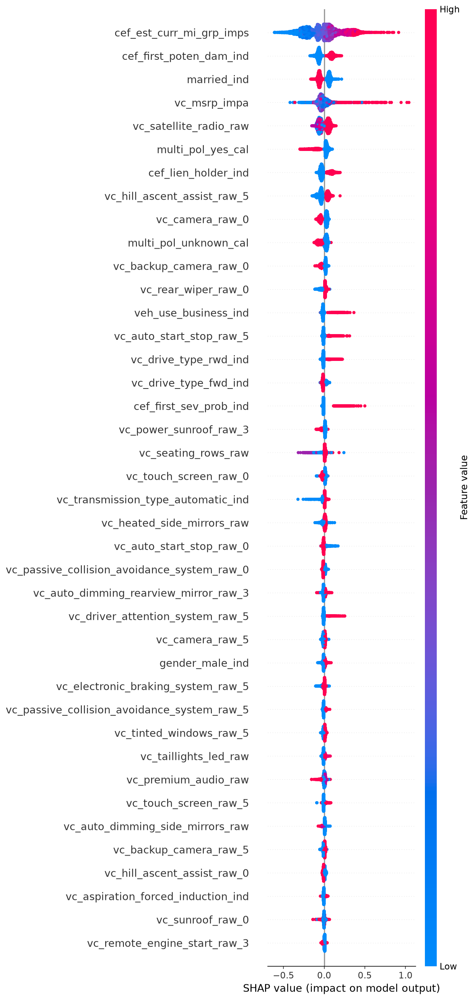

In [12]:
# SHAP Beeswarm Plot (standard - shows feature value impact)
print(f"\n{'='*60}")
print("SHAP BEESWARM PLOT")
print('='*60)
print("Note: Each dot = record. Color shows feature value (red=high, blue=low)")
print("X-axis shows SHAP value impact on prediction")
fig_beeswarm = create_shap_beeswarm(fc_tr, data_tr, top_n=top_n, weight_col='weight', max_display=top_n)
if fig_beeswarm:
    beeswarm_file = f'{plots_dir}/shap_beeswarm.png'
    fig_beeswarm.savefig(beeswarm_file, dpi=150, bbox_inches='tight')
    plt.close(fig_beeswarm)
    print(f"Saved: {beeswarm_file}")
    display(Image(beeswarm_file))
else:
    print("Warning: Could not create SHAP beeswarm plot")



SHAP FEATURE IMPORTANCE (%)
  Creating SHAP importance % chart for 7,154 rows...
  SHAP importance % chart created


Saved: output/car_comp/v1/plots/shap_importance_pct.png


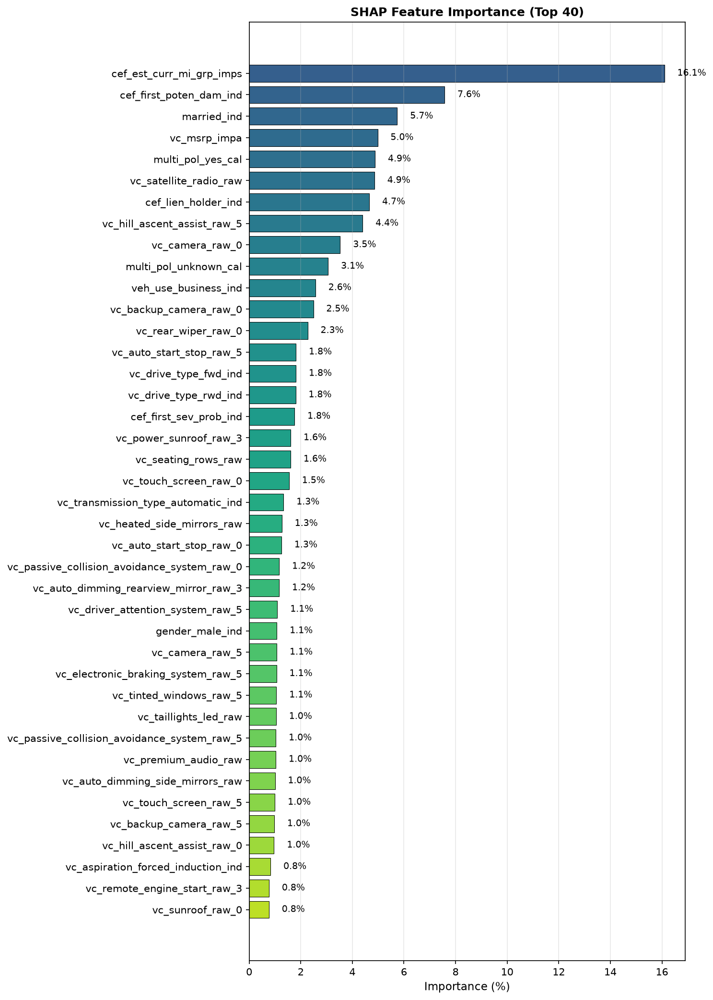

In [13]:
# SHAP Feature Importance (Percentage)
print(f"\n{'='*60}")
print("SHAP FEATURE IMPORTANCE (%)")
print('='*60)
fig_importance = create_shap_importance_pct(fc_tr, top_n=top_n, weight_col='weight')
if fig_importance:
    importance_file = f'{plots_dir}/shap_importance_pct.png'
    fig_importance.savefig(importance_file, dpi=150, bbox_inches='tight')
    plt.close(fig_importance)
    print(f"Saved: {importance_file}")
    display(Image(importance_file))
else:
    print("Warning: Could not create SHAP importance plot")


In [14]:
summary = {"timestamp": datetime.now().isoformat(), "plots": 0}
plots_by_feature = {}

In [15]:
print("="*60)
print("GENERATING PLOTS")
print("="*60)
for i, f in enumerate(features, 1):
    print(f"[{i}/{len(features)}] {f}")
    plots_by_feature[f] = []
    if f not in out_tr.columns or f not in out_te.columns:
        print(f"  WARNING: Feature {f} not found, skipping")
        continue
    if "train" in datasets:
        try:
            fig, _ = create_residual_plot(out_tr, f, "weight", dataset_label="Train", **resid_cfg)
            path = f"{plots_dir}/train_{f}_residual.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Train Residual): {e}")
        try:
            fig, _ = create_shap_range_plot(fc_tr, data_tr, f, "weight", dataset_label="Train", **shap_range_cfg)
            path = f"{plots_dir}/train_{f}_shap_range.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Train SHAP): {e}")
    if "test" in datasets:
        try:
            fig, _ = create_residual_plot(out_te, f, "weight", dataset_label="Test", **resid_cfg)
            path = f"{plots_dir}/test_{f}_residual.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Test Residual): {e}")
        try:
            fig, _ = create_shap_range_plot(fc_te, data_te, f, "weight", dataset_label="Test", **shap_range_cfg)
            path = f"{plots_dir}/test_{f}_shap_range.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Test SHAP): {e}")
print(f"\n[OK] Generated summary")

GENERATING PLOTS
[1/40] cef_est_curr_mi_grp_imps

cef_est_curr_mi_grp_imps Summary:
cef_est_curr_mi_grp_imps     weight   act_rate  pred_rate
     (6401.999, 20000.0] 447.465933 873.565886 314.623820
      (20000.0, 30059.0] 311.152100 765.436458 297.421185
      (30059.0, 40000.0] 375.622060 434.864296 296.281219
      (40000.0, 47430.0] 363.063178 159.926325 258.628246
      (47430.0, 53887.0] 456.111191 137.364189 243.771773
      (53887.0, 60000.0] 431.384190 274.248378 235.954939
      (60000.0, 67448.0] 258.848507 149.153193 132.127790
      (67448.0, 80000.0] 457.814859 166.030835 245.984652
      (80000.0, 96296.0] 322.435115 153.073360 184.080469
     (96296.0, 108144.0] 272.539726  63.537659 187.032926
    (108144.0, 117590.0] 208.747227 229.704123 176.109639
    (117590.0, 124707.0] 253.393547  53.832118 111.976239
    (124707.0, 150000.0] 287.815488 222.551157 256.535544
    (150000.0, 180000.0] 163.995546  70.724799 217.866065
    (180000.0, 210000.0]  72.410083   3.874887

/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:156: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:156: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 

  ERROR (Train SHAP): cannot reindex on an axis with duplicate labels

cef_est_curr_mi_grp_imps Summary:
cef_est_curr_mi_grp_imps        weight   act_rate  pred_rate
     (6401.999, 22995.2] 204708.042241 399.959325 292.754188
      (22995.2, 37028.6] 172393.749996 439.545165 321.571067
     (37028.6, 43263.65] 204596.200606 350.499388 266.379935
     (43263.65, 52374.2] 251390.270754 312.269208 250.488000
     (52374.2, 60052.25] 249465.505285 267.706239 227.457956
     (60052.25, 69744.8] 117377.839539 220.950696 153.215147
      (69744.8, 88303.5] 239524.531447 300.582476 226.931434
     (88303.5, 103032.8] 208799.435616 284.276268 203.682340
    (103032.8, 116948.6] 104211.917913 235.832599 194.029313
    (116948.6, 127353.5] 140624.331986 161.119520 127.172004
    (127353.5, 161500.0] 155250.719335 357.877708 237.847381
    (161500.0, 198000.0]  56144.220181 372.932449 214.883793
    (198000.0, 234500.0]  31034.102470 313.167413 192.867352
    (234500.0, 271000.0]   9888.731290 28

/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:156: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:156: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 

  ERROR (Test SHAP): cannot reindex on an axis with duplicate labels
[2/40] cef_first_poten_dam_ind

cef_first_poten_dam_ind Summary:
 cef_first_poten_dam_ind      weight   act_rate  pred_rate
                     0.0 2908.029381 350.726854 223.739872
                     1.0 1832.315383 184.761261 250.351831


...

[40/40] vc_sunroof_raw_0

vc_sunroof_raw_0 Summary:
 vc_sunroof_raw_0      weight   act_rate  pred_rate
              0.0 3223.639262 287.898262 242.147659
              1.0 1516.705502 283.762902 216.765175


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:156: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:156: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 


vc_sunroof_raw_0 Summary:
 vc_sunroof_raw_0       weight   act_rate  pred_rate
              0.0 1.463671e+06 321.456846 240.745942
              1.0 6.859417e+05 289.417007 215.260323


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:156: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:156: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 


[OK] Generated summary



DISPLAYING ALL PLOTS

FEATURE: cef_est_curr_mi_grp_imps


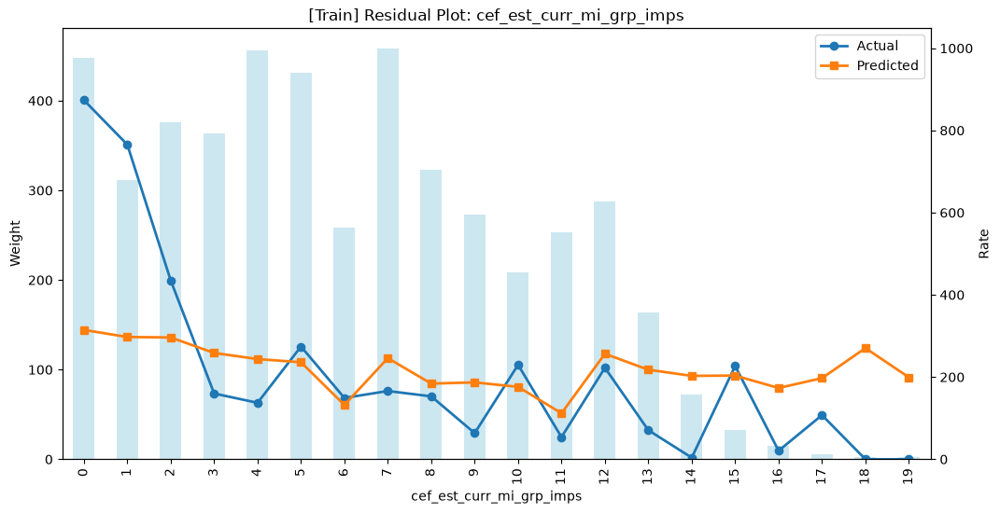

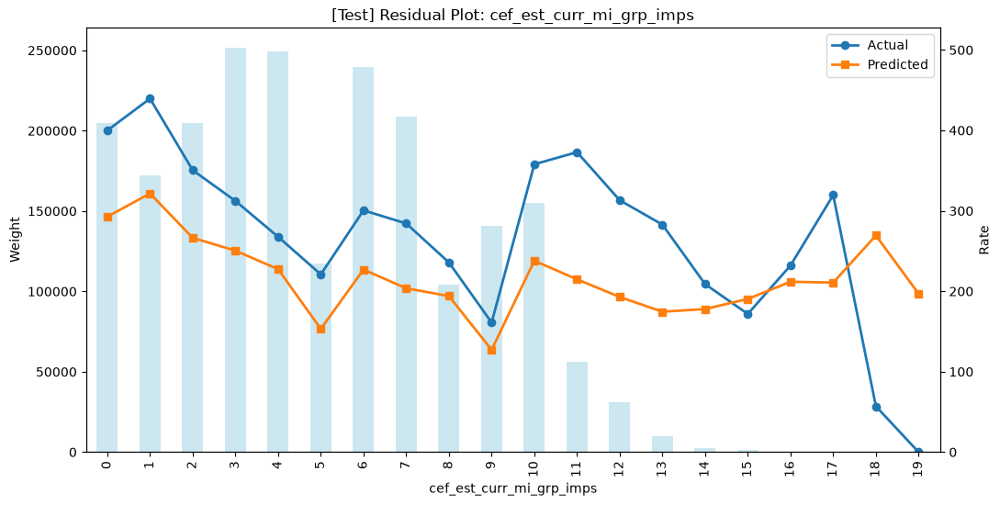


FEATURE: cef_first_poten_dam_ind


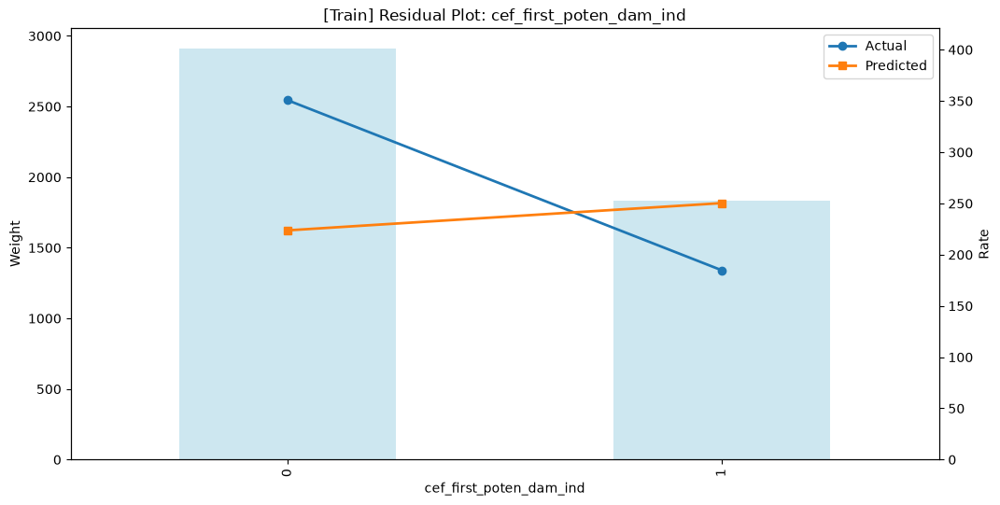

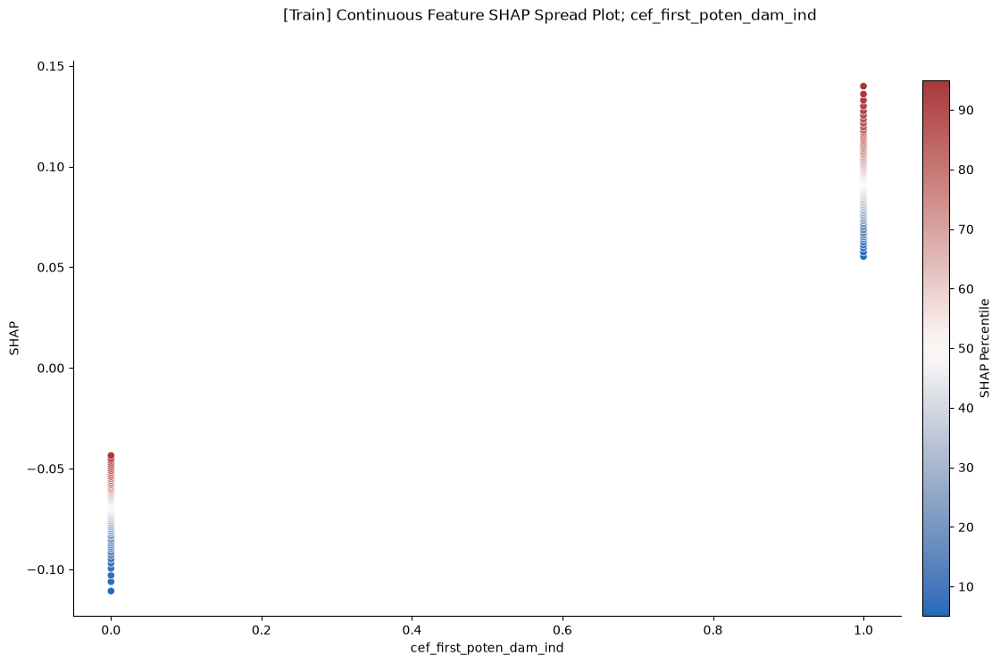

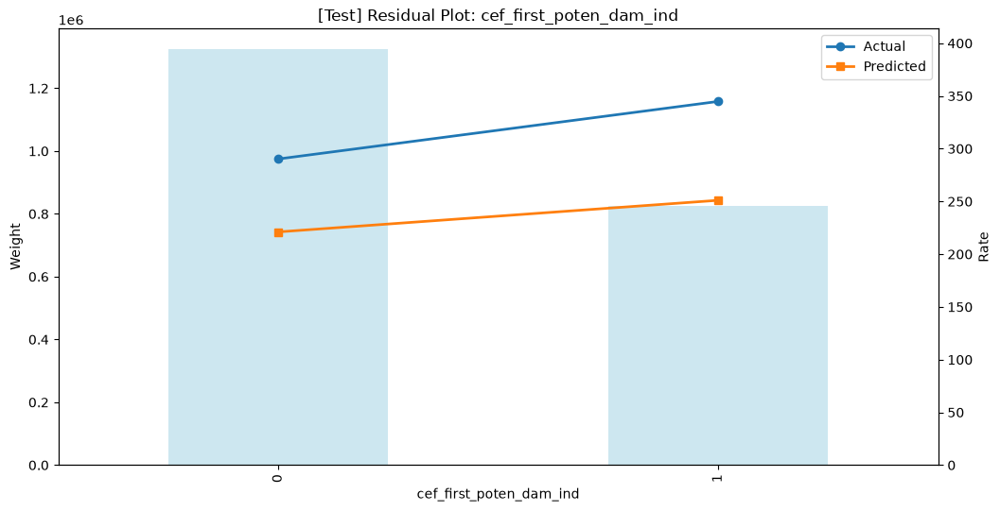

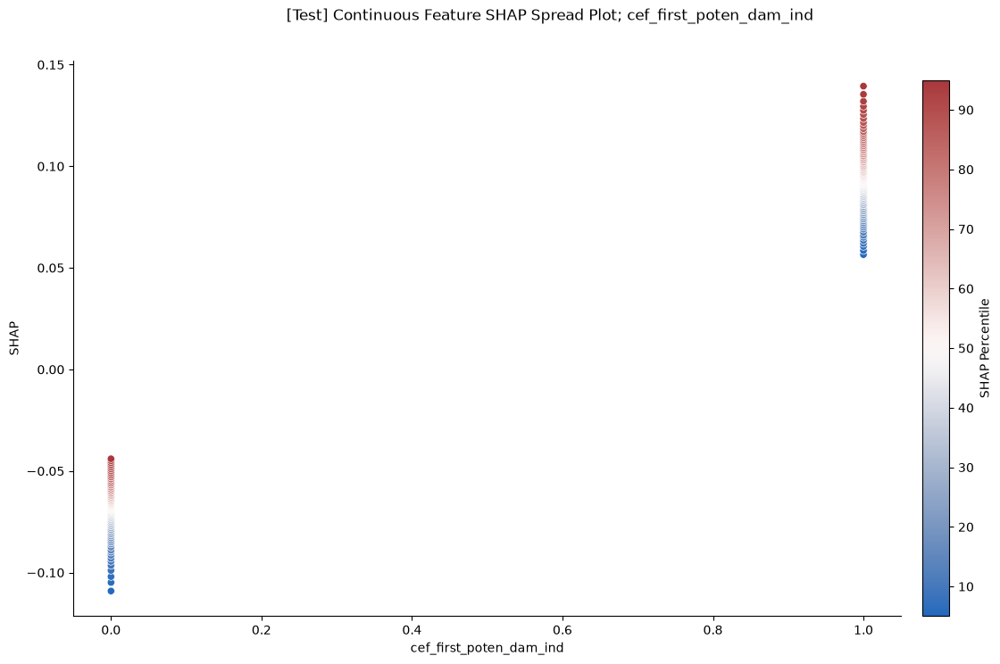


FEATURE: married_ind


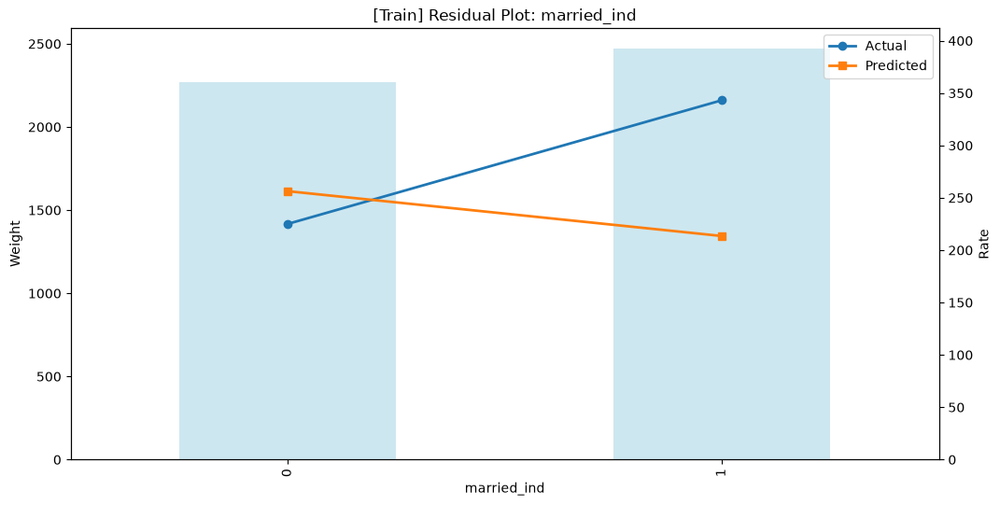

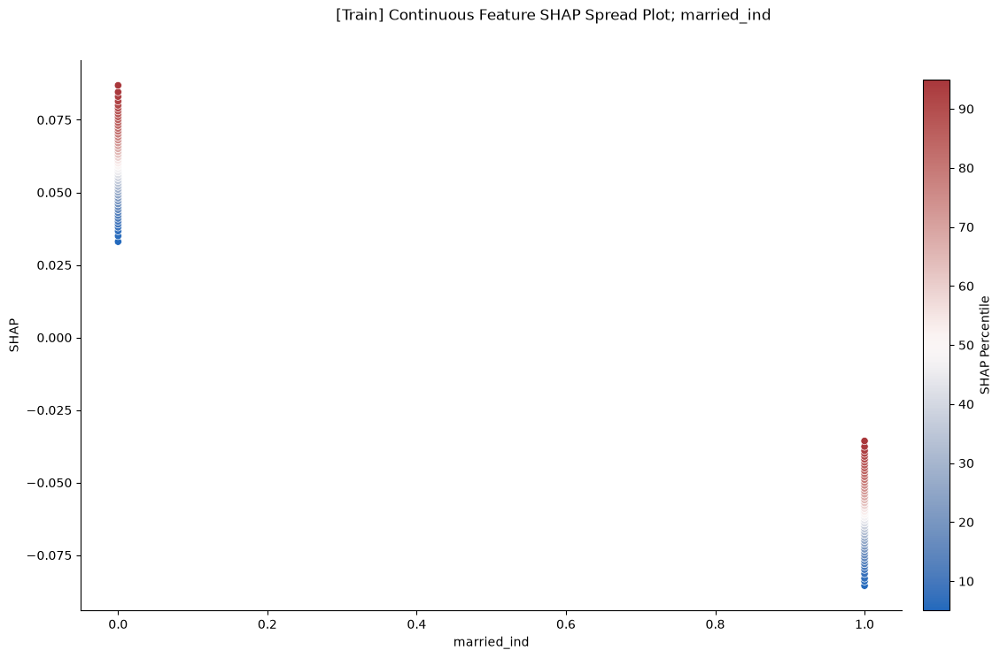

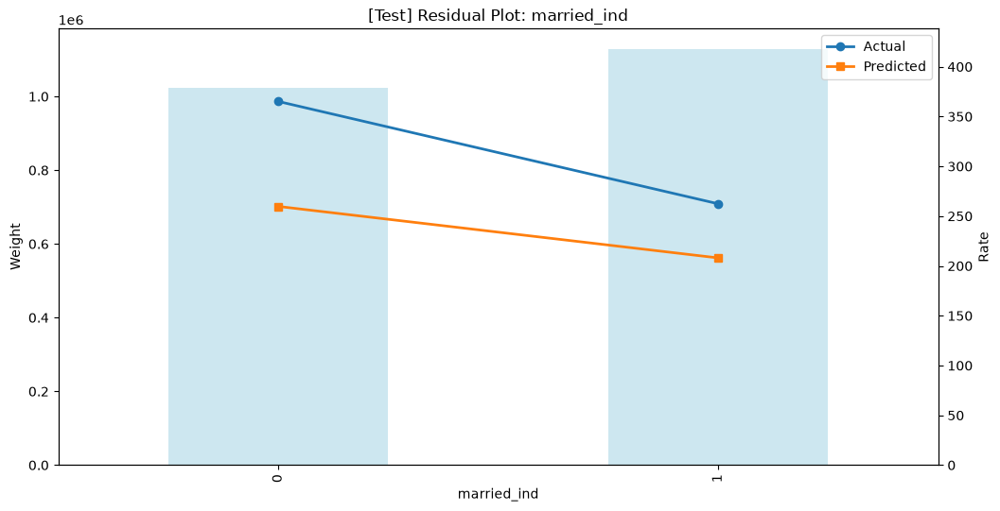

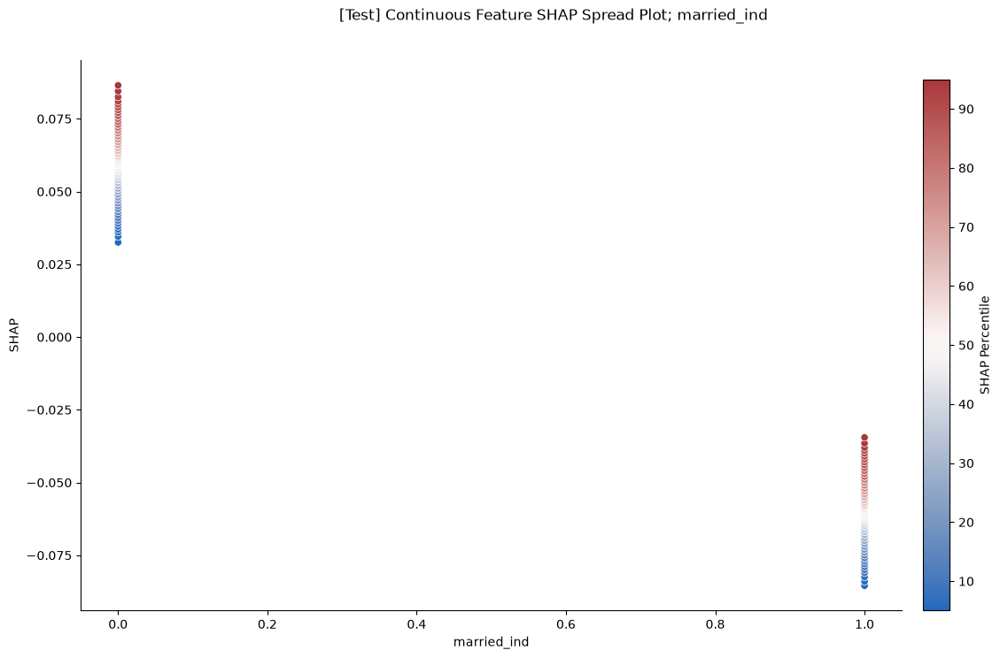


FEATURE: vc_msrp_impa


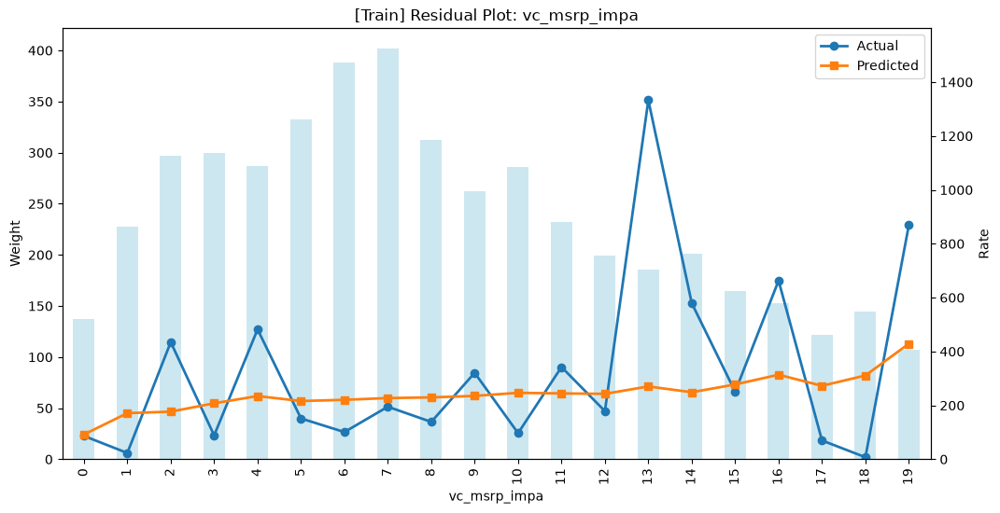

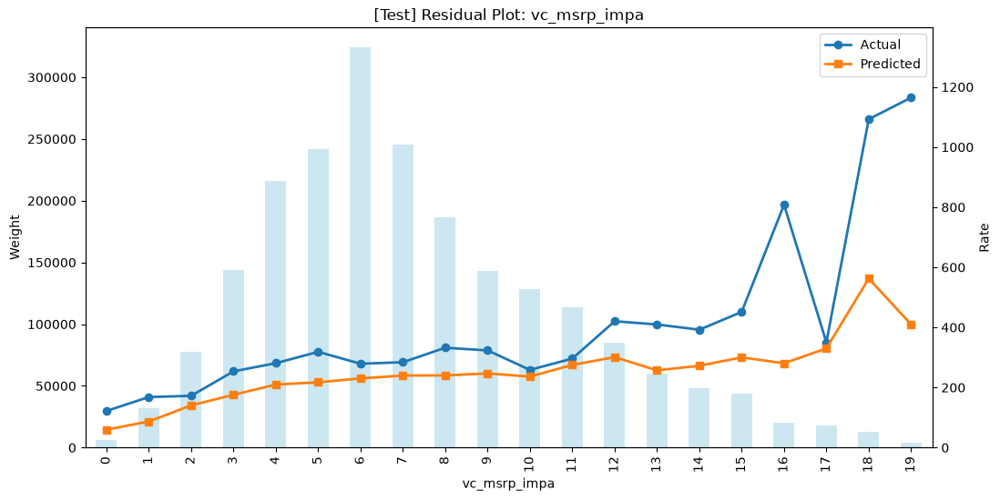


FEATURE: multi_pol_yes_cal


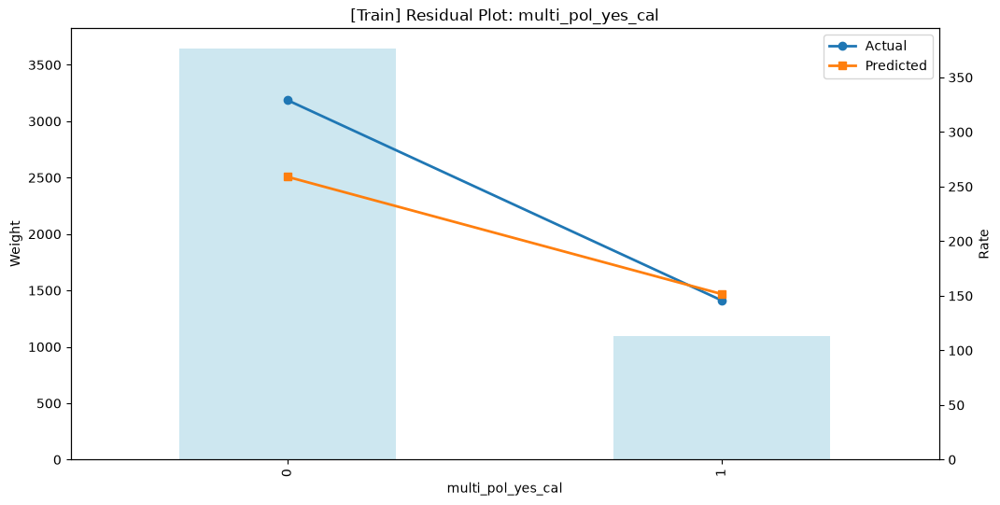

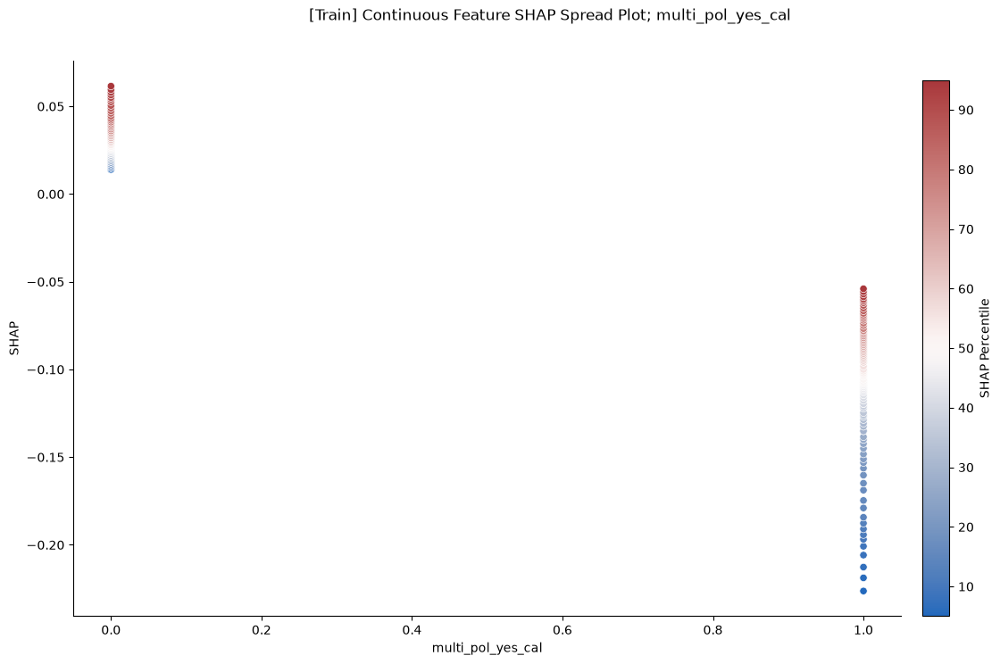

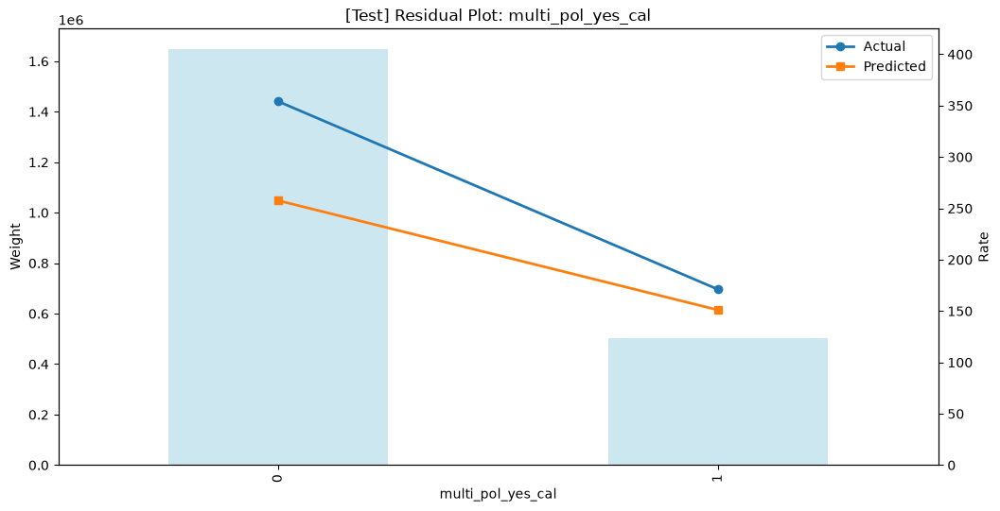

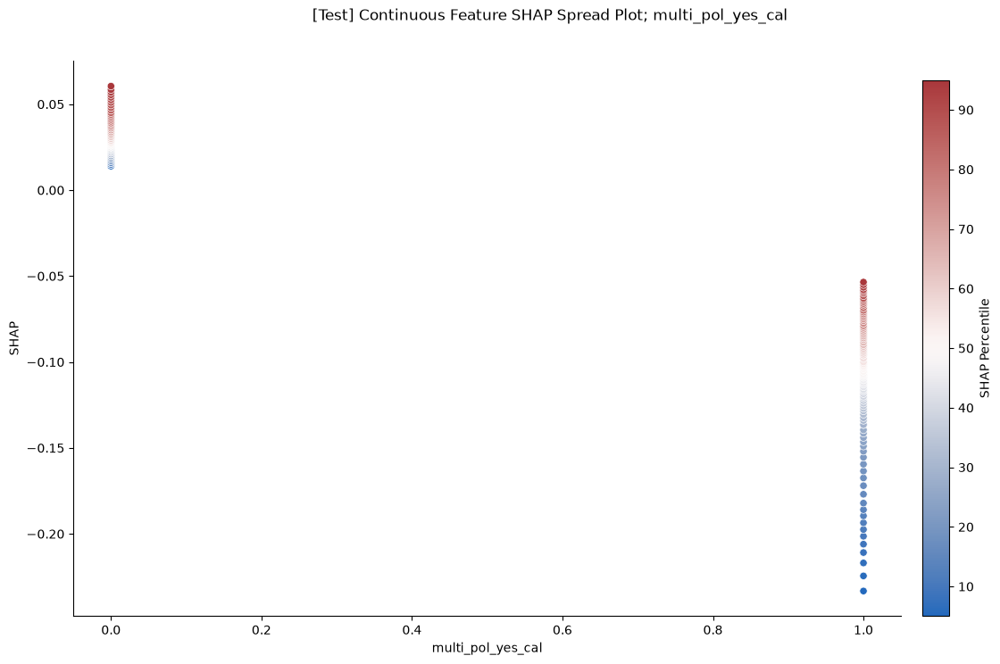


FEATURE: vc_satellite_radio_raw


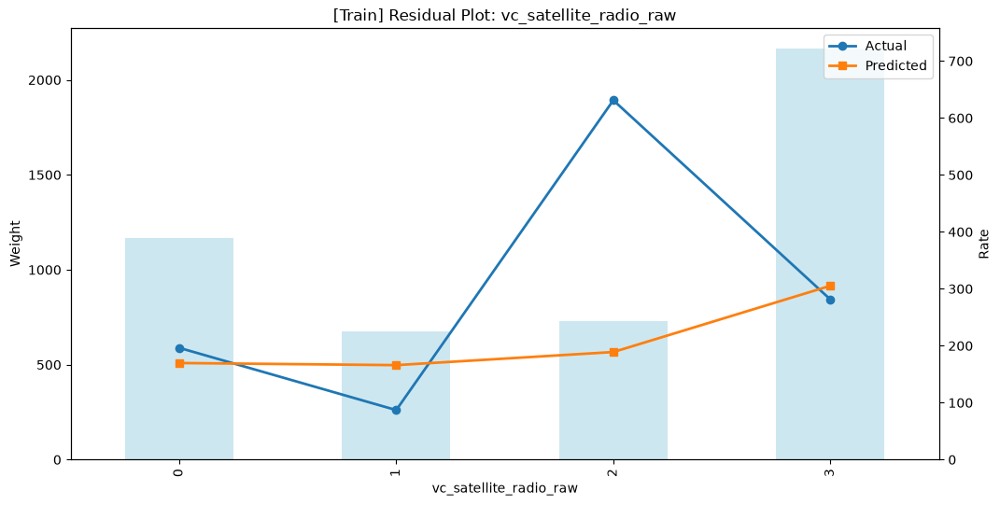

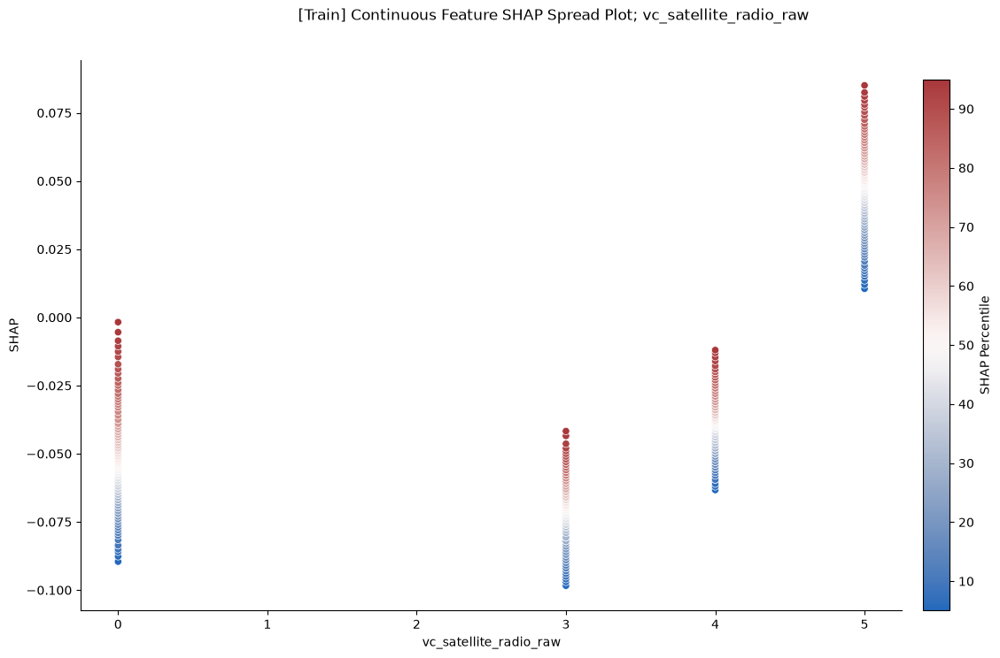

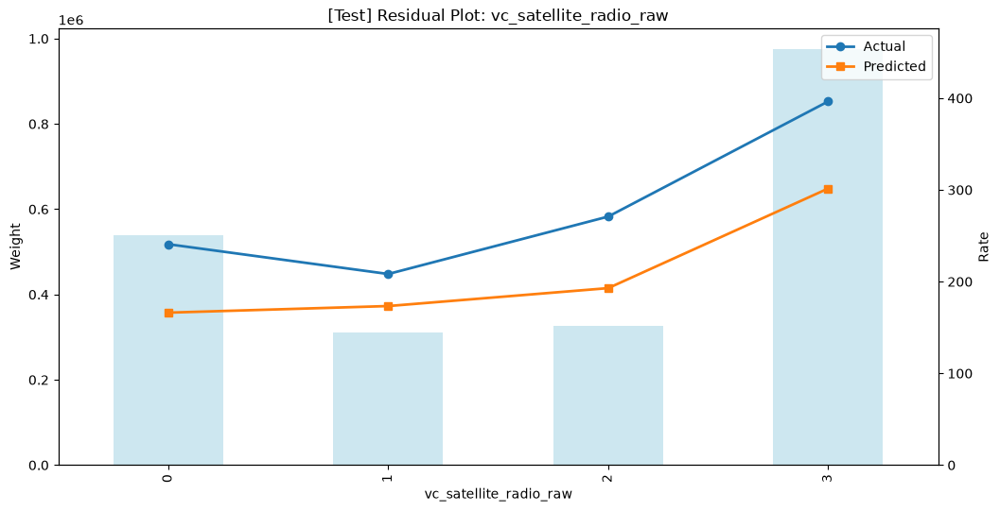

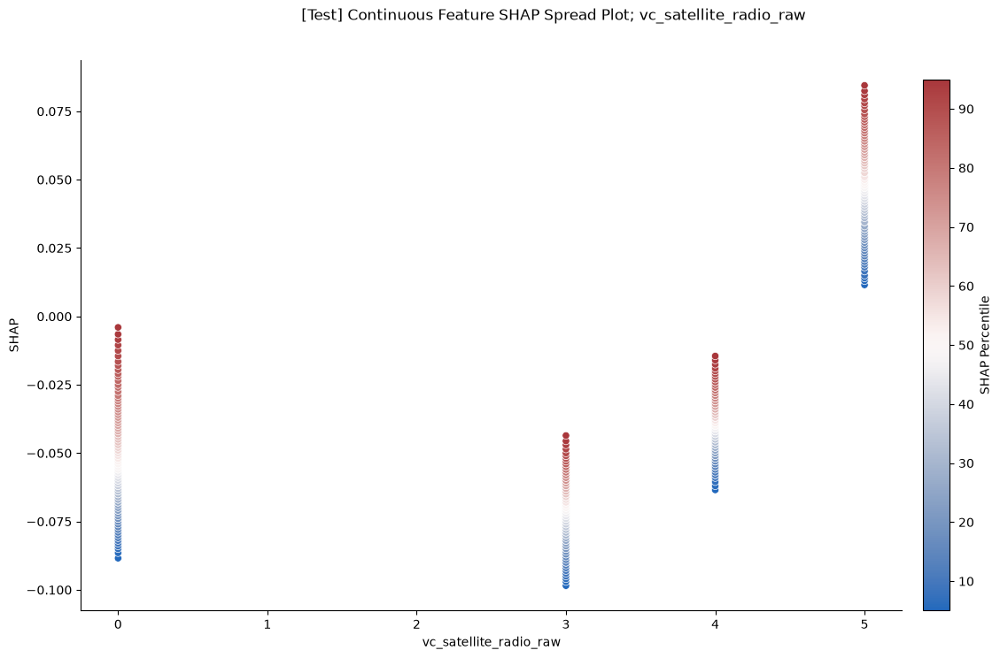


FEATURE: cef_lien_holder_ind


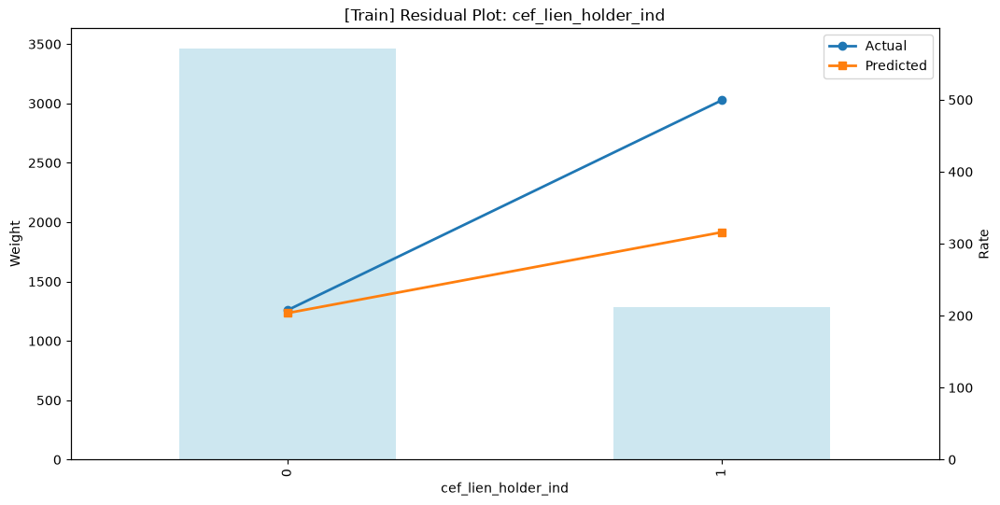

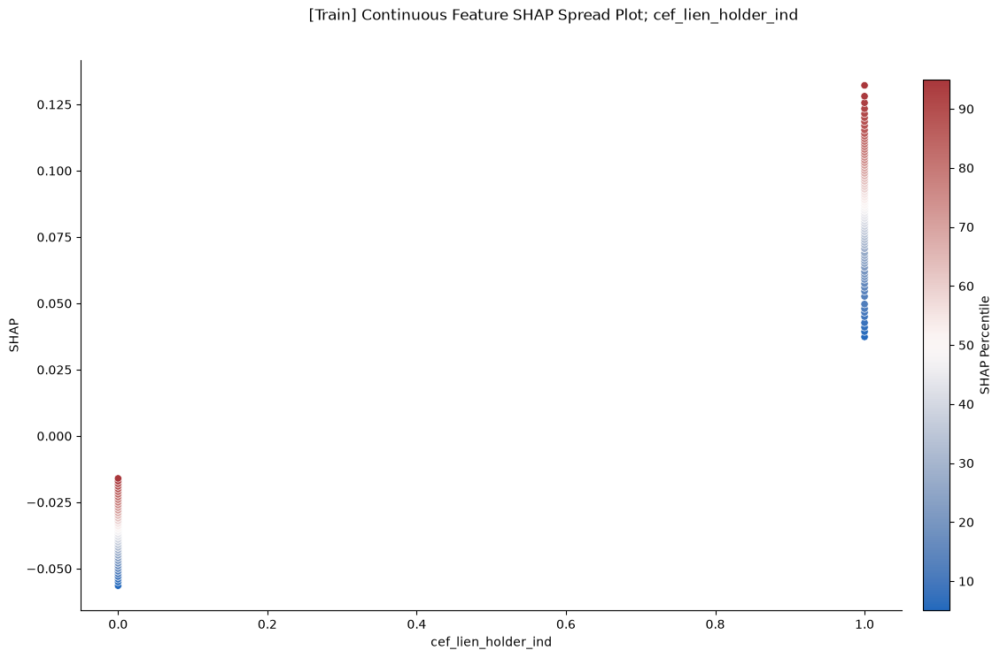

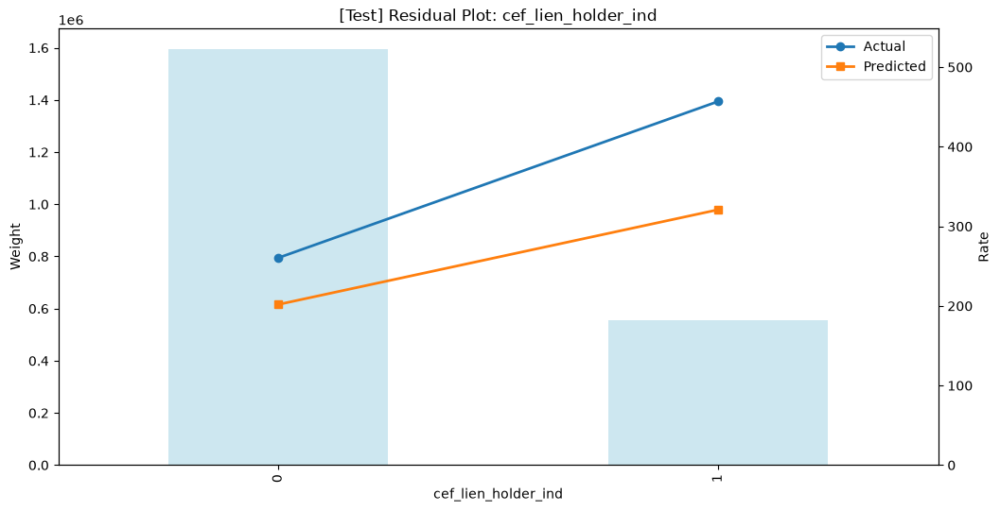

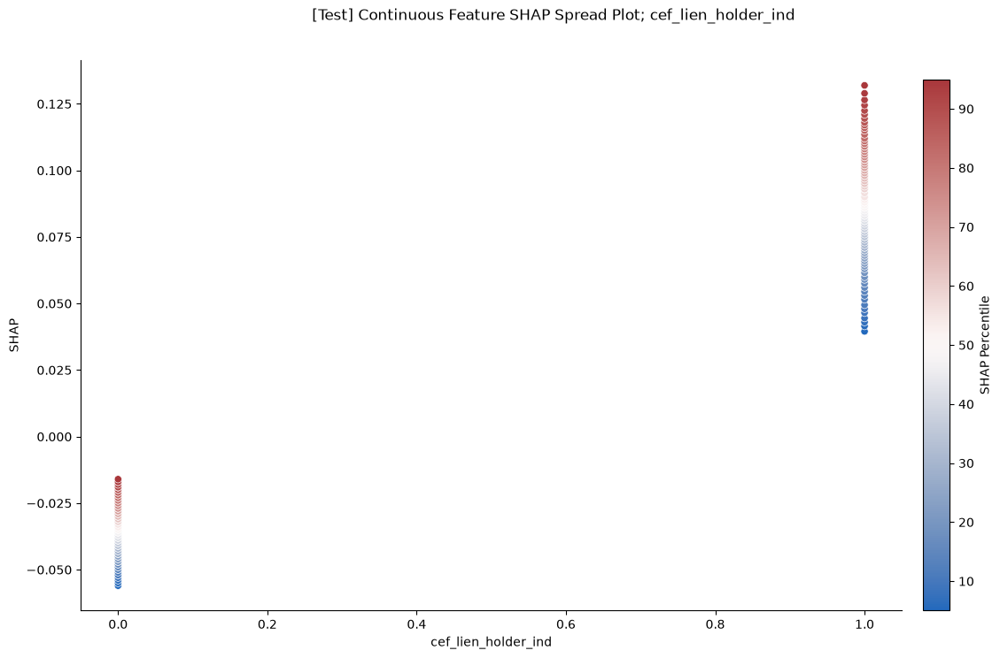


FEATURE: vc_hill_ascent_assist_raw_5


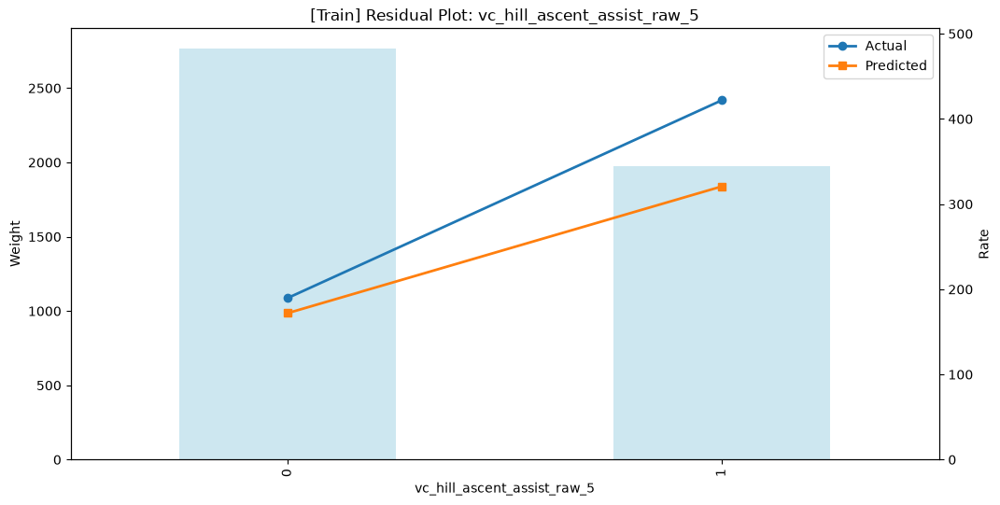

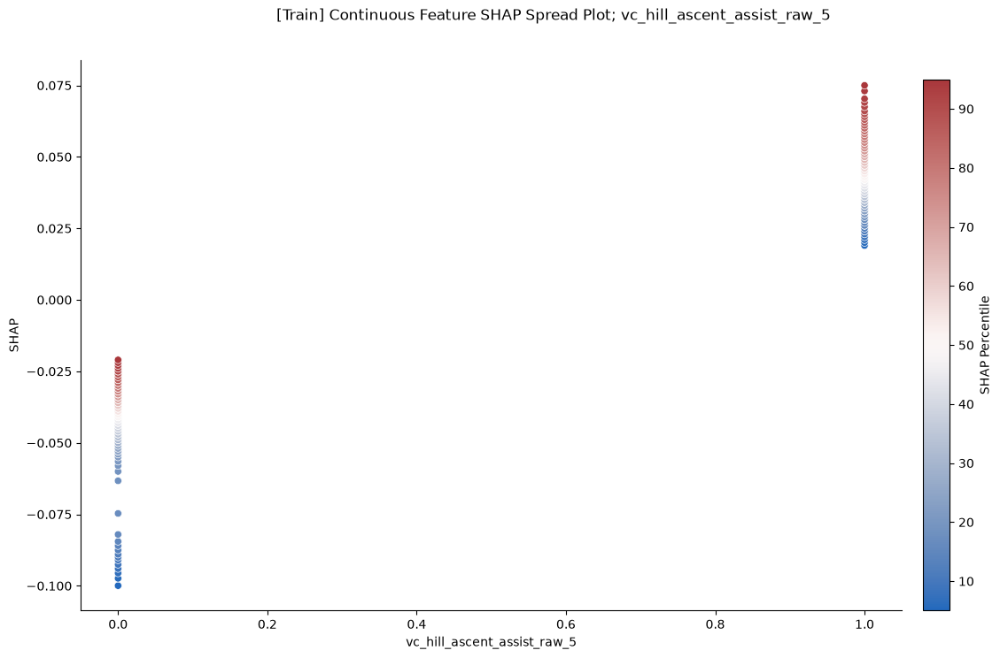

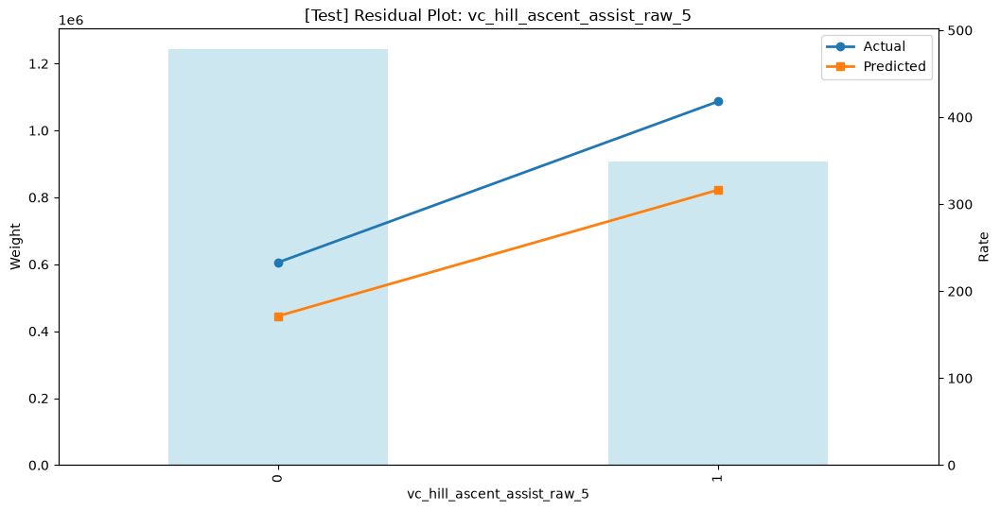

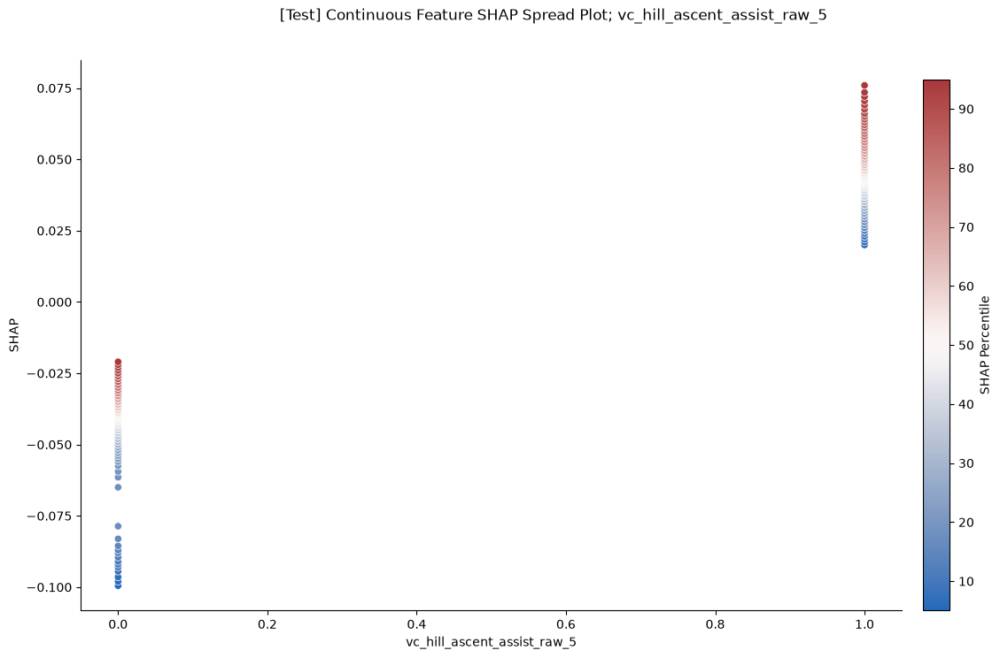


FEATURE: vc_camera_raw_0


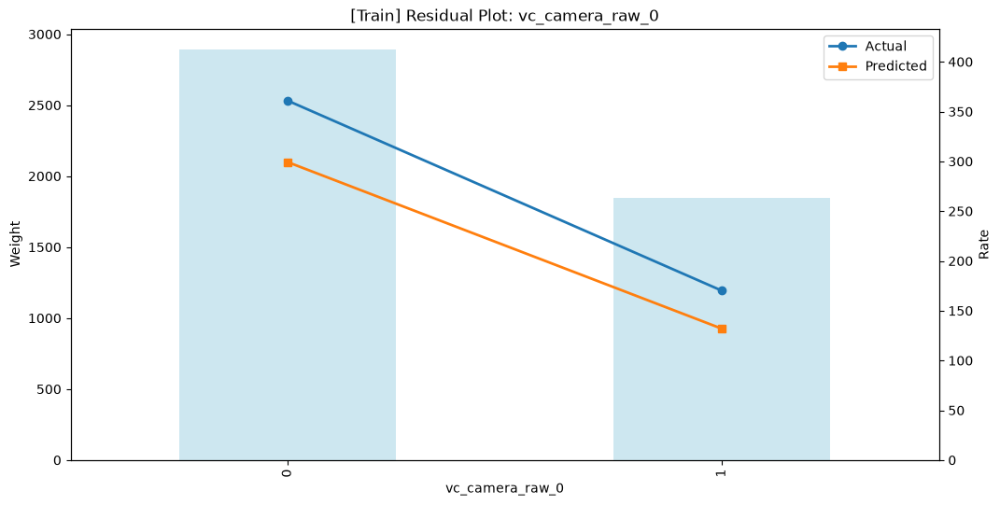

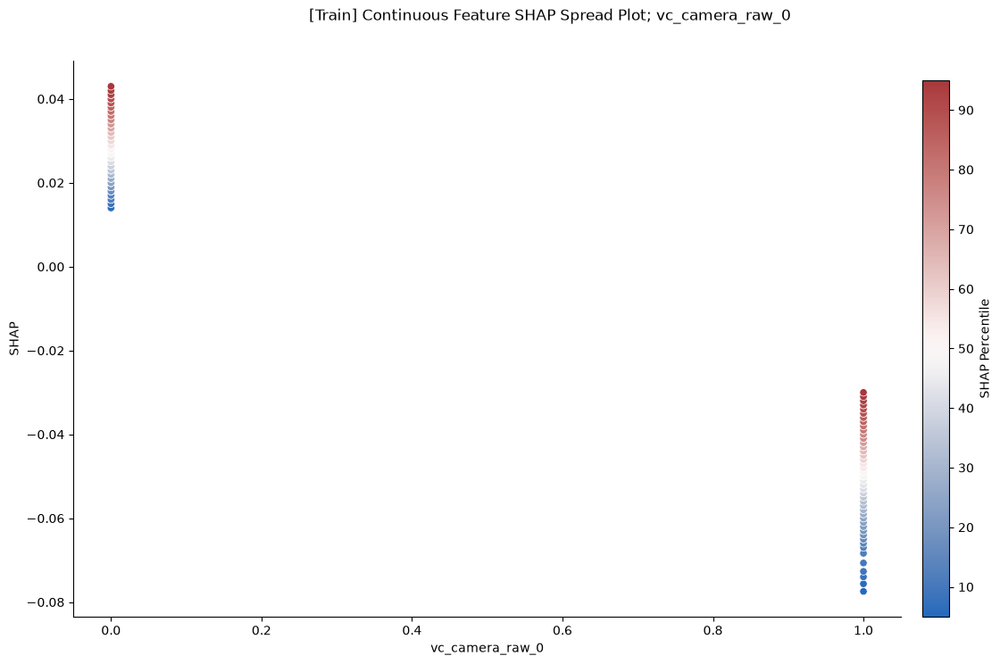

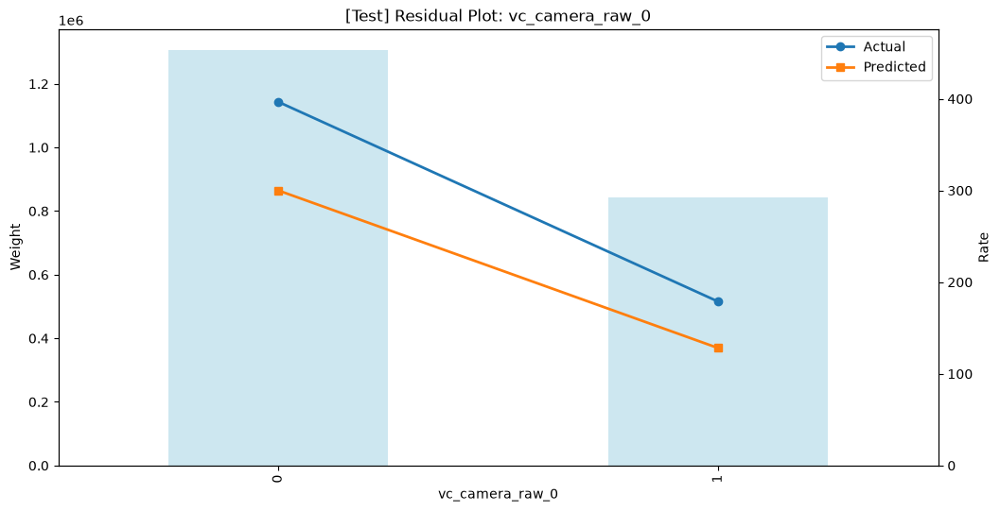

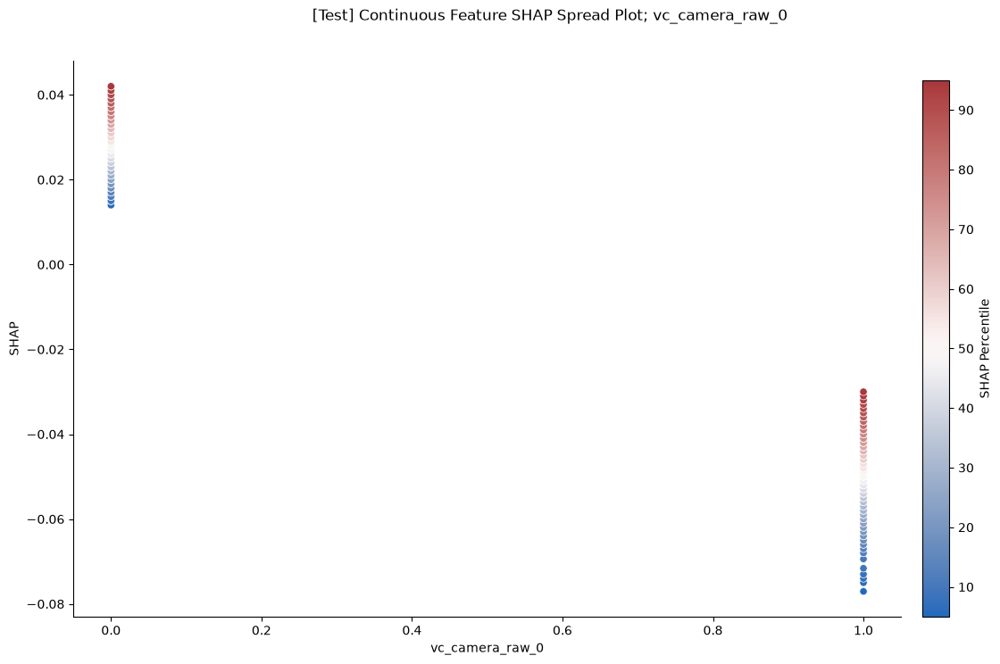


FEATURE: multi_pol_unknown_cal


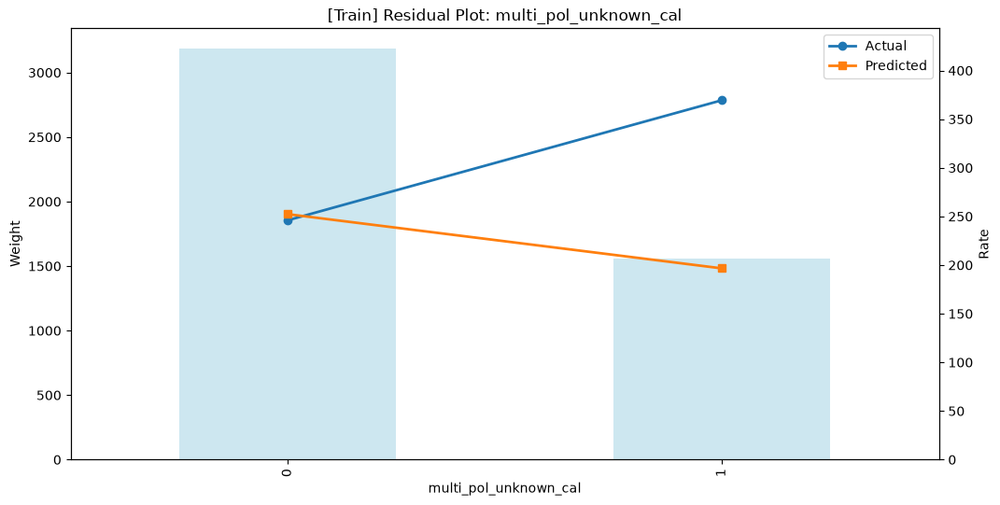

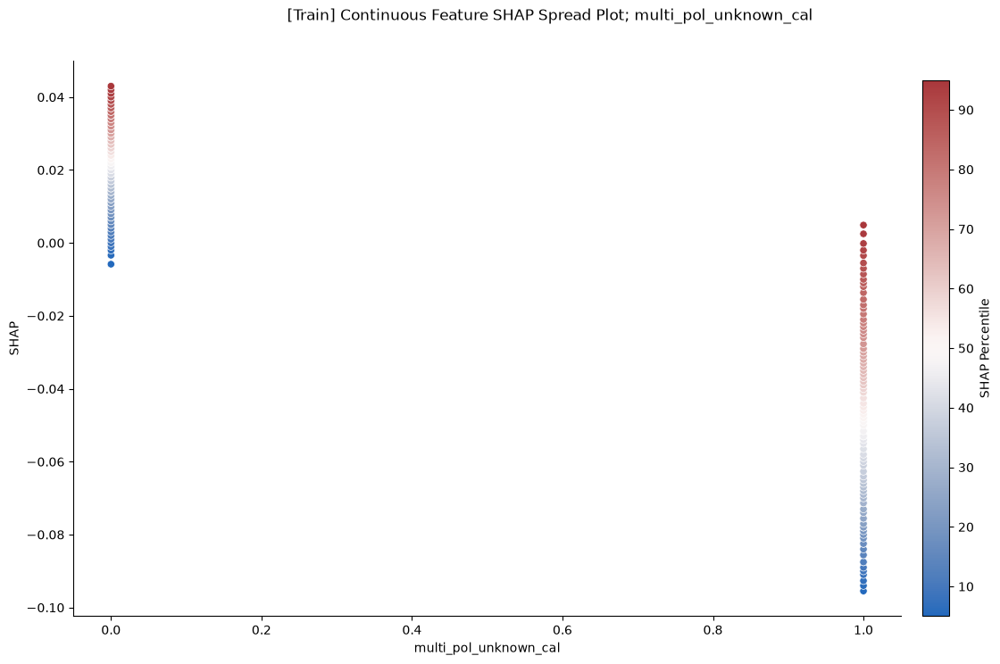

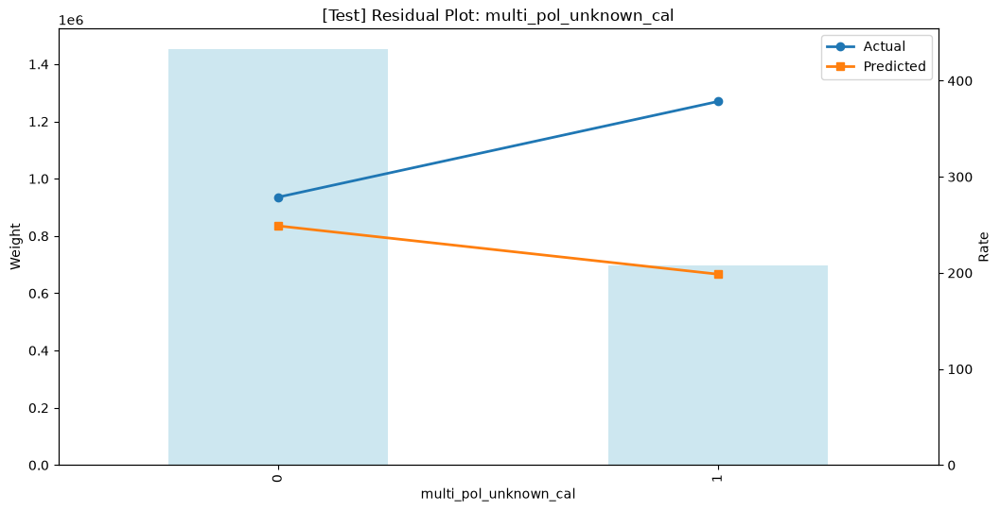

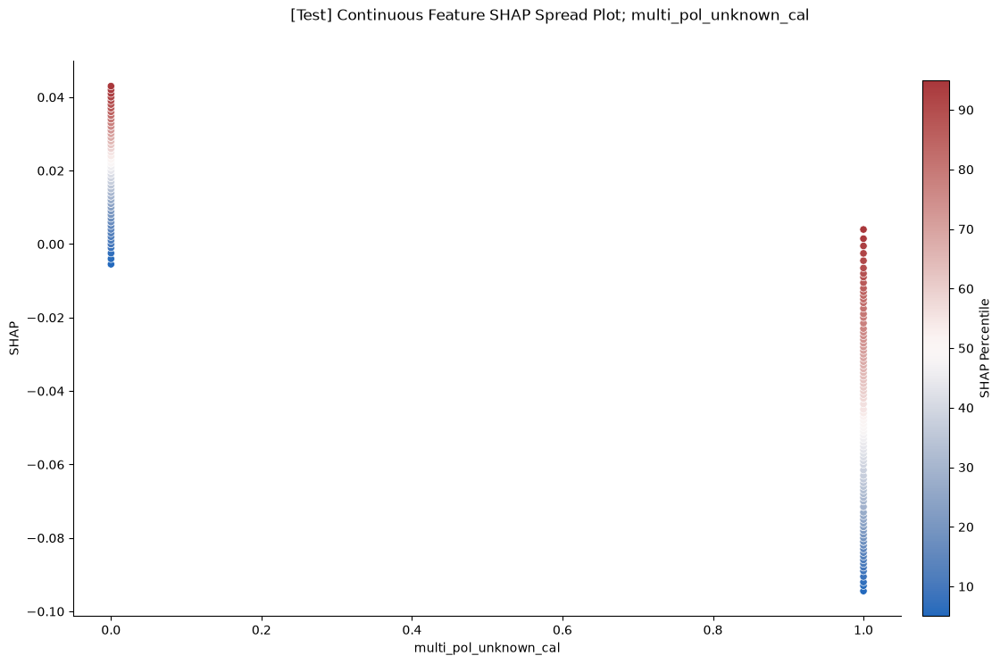


FEATURE: veh_use_business_ind


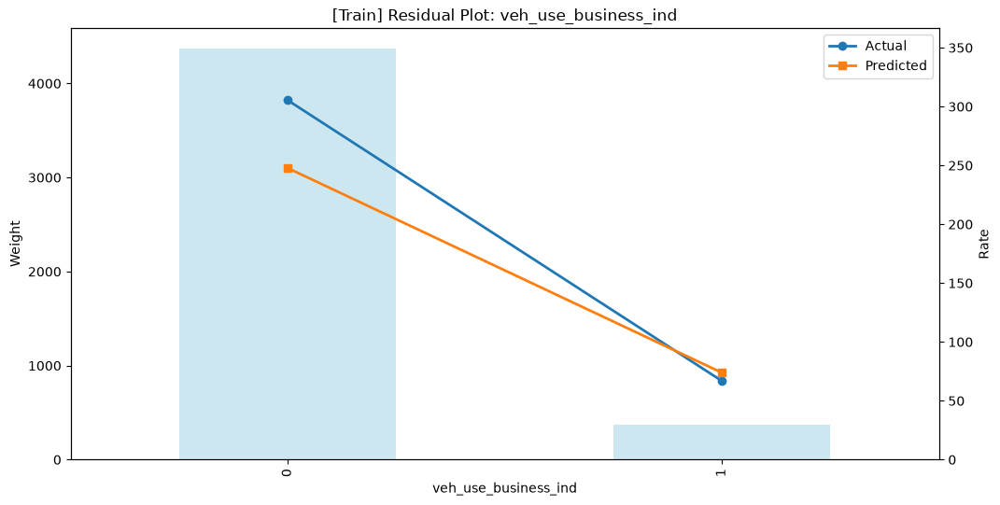

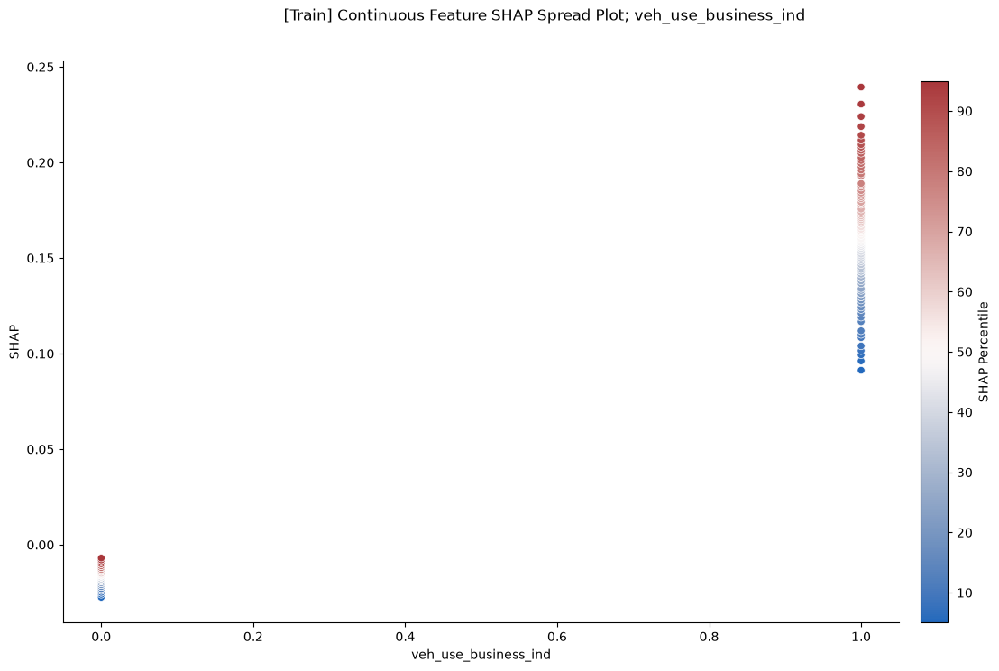

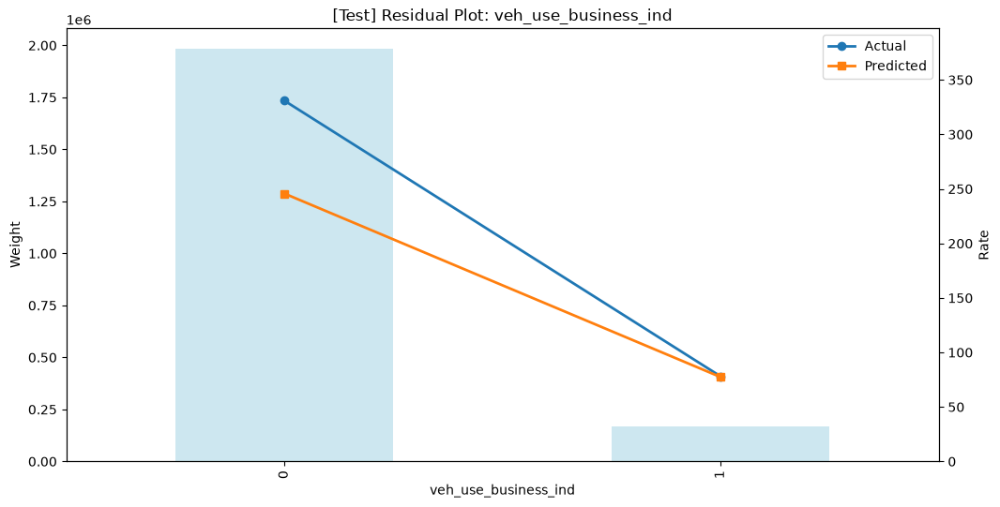

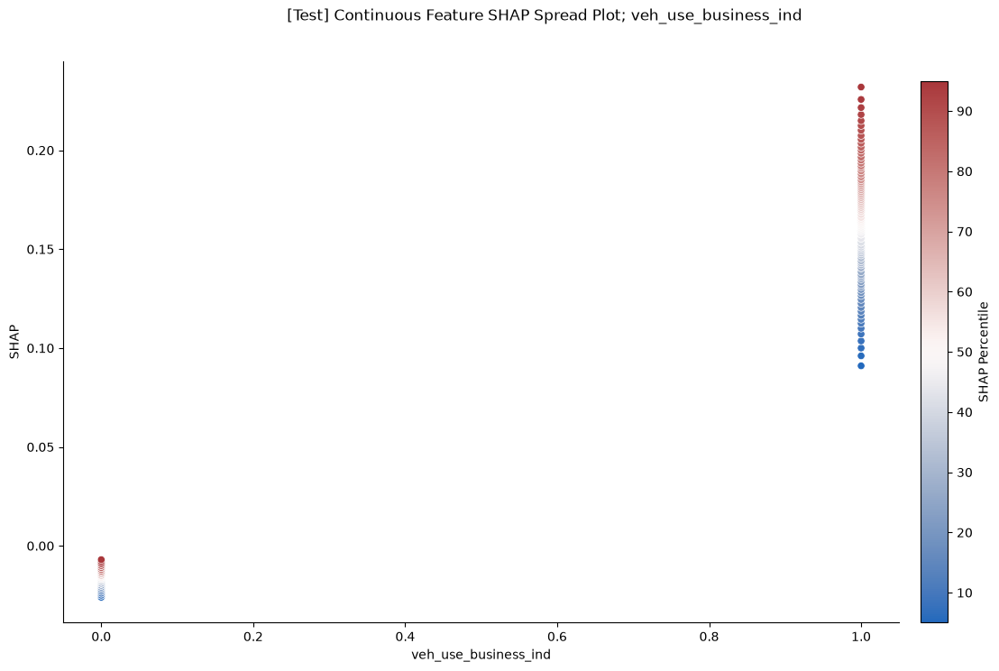


FEATURE: vc_backup_camera_raw_0


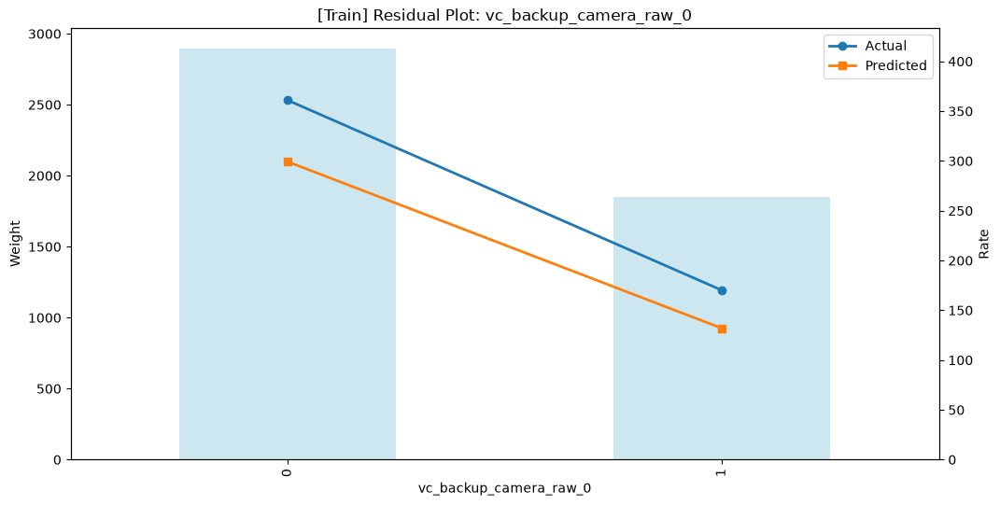

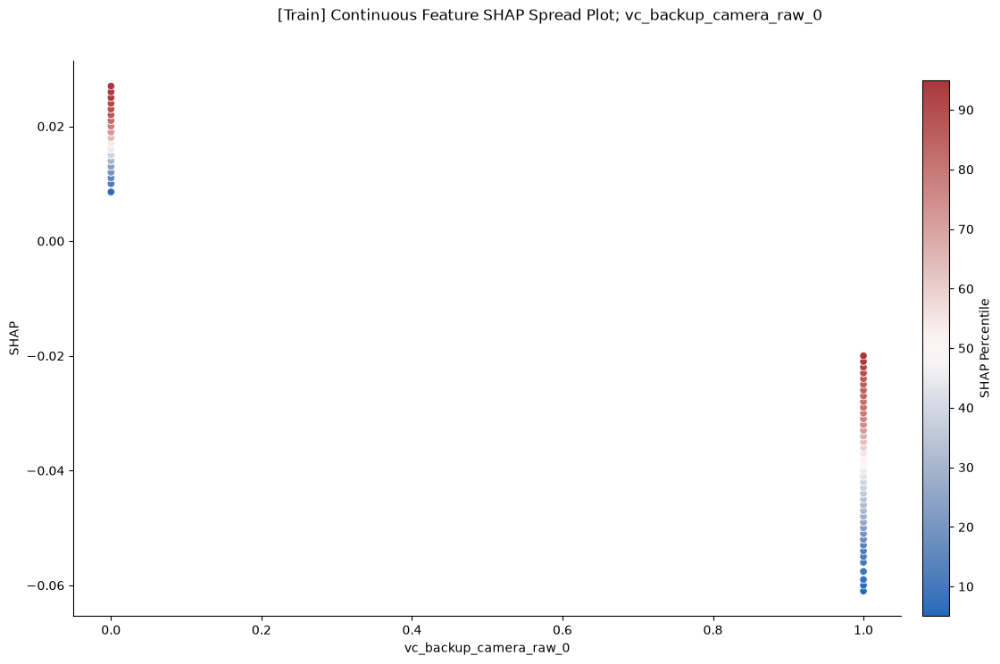

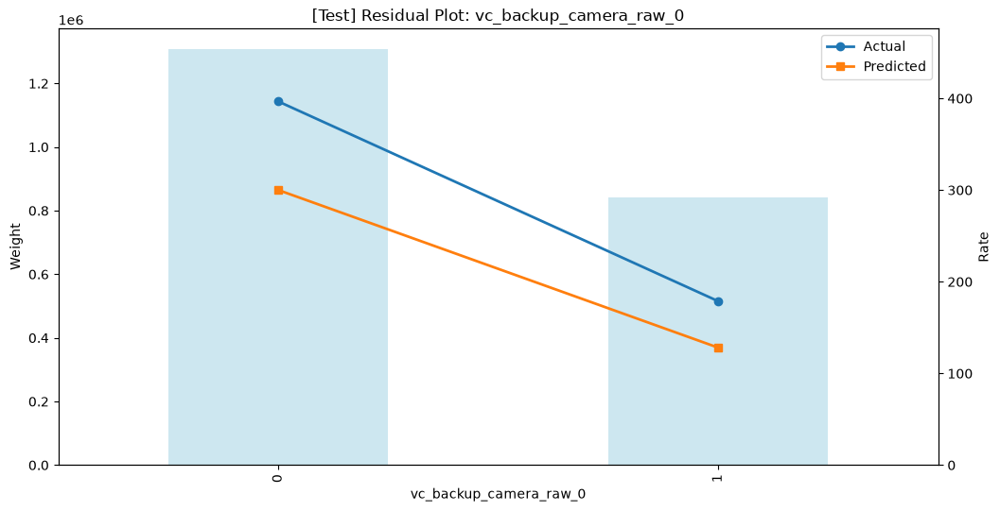

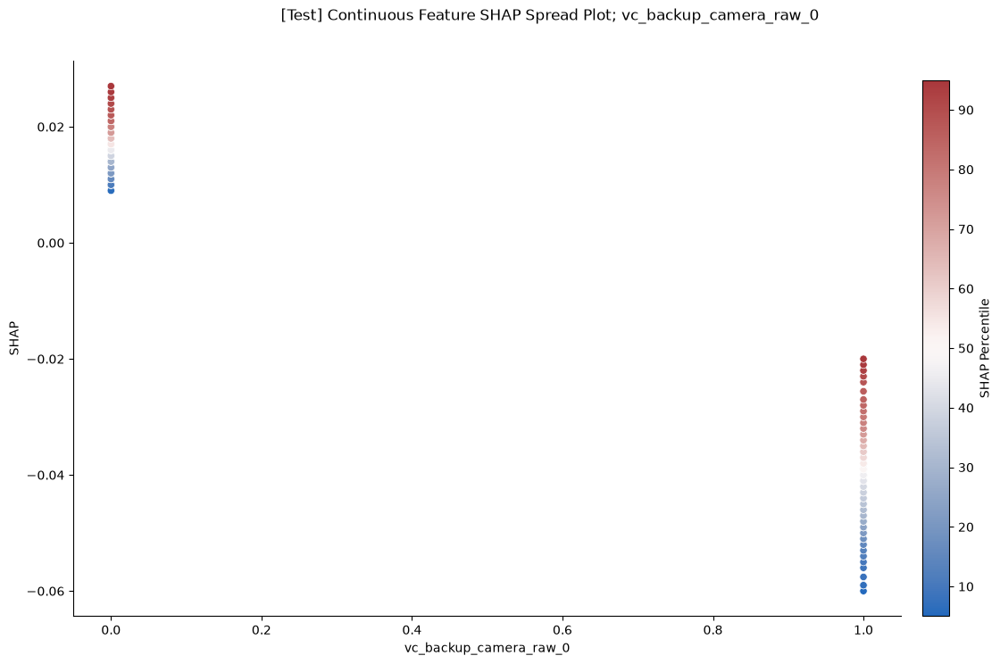


FEATURE: vc_rear_wiper_raw_0


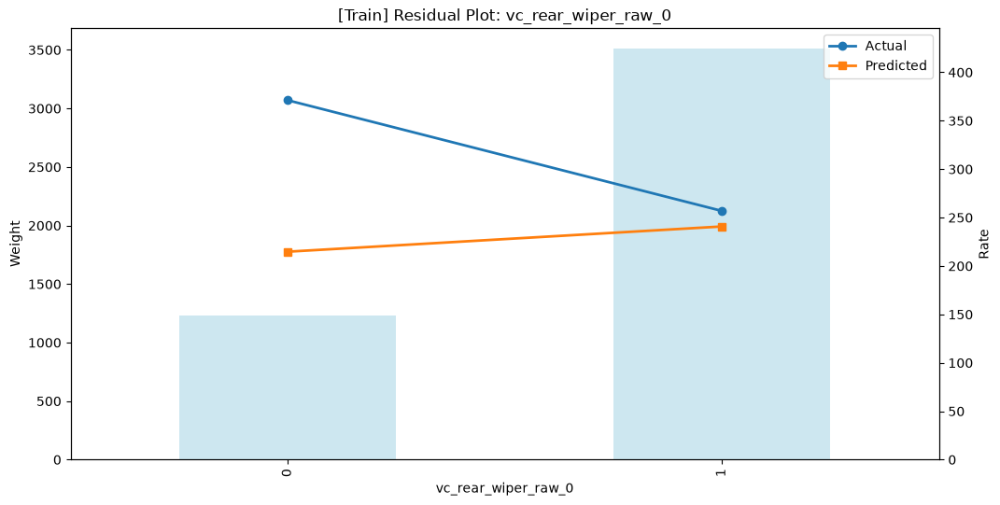

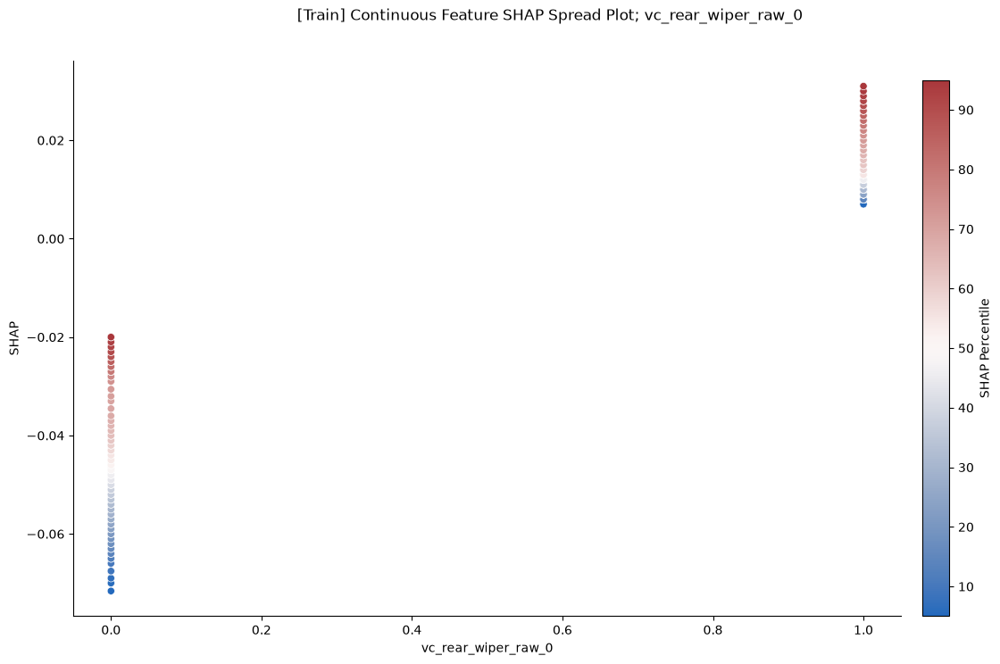

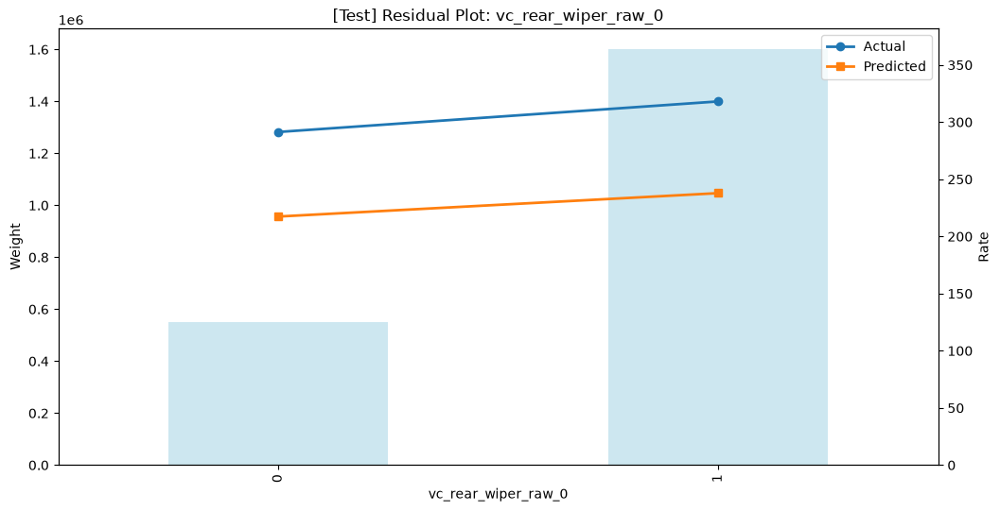

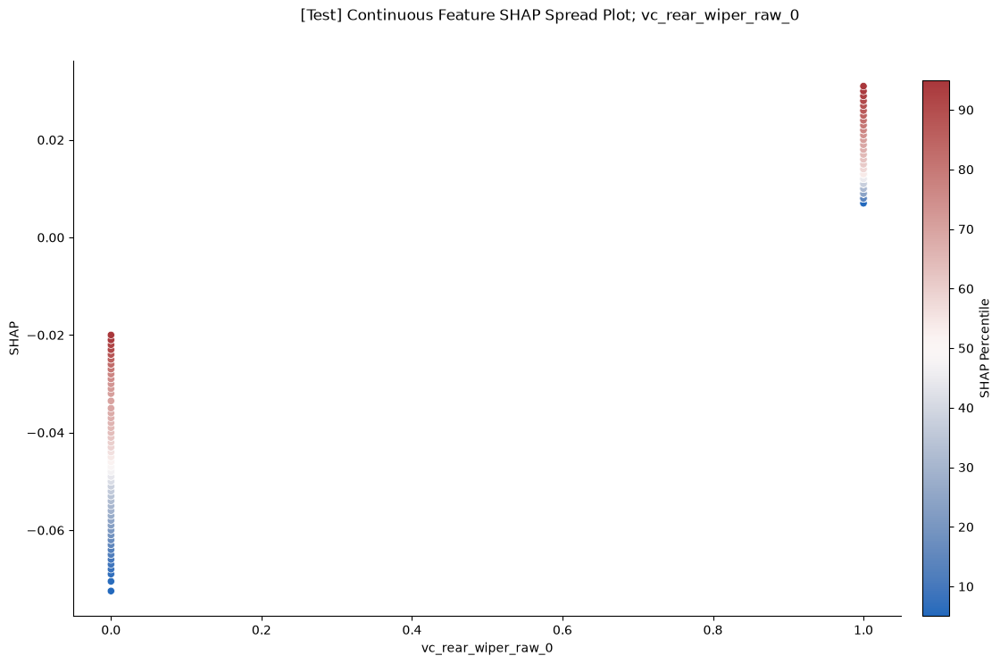


FEATURE: vc_auto_start_stop_raw_5


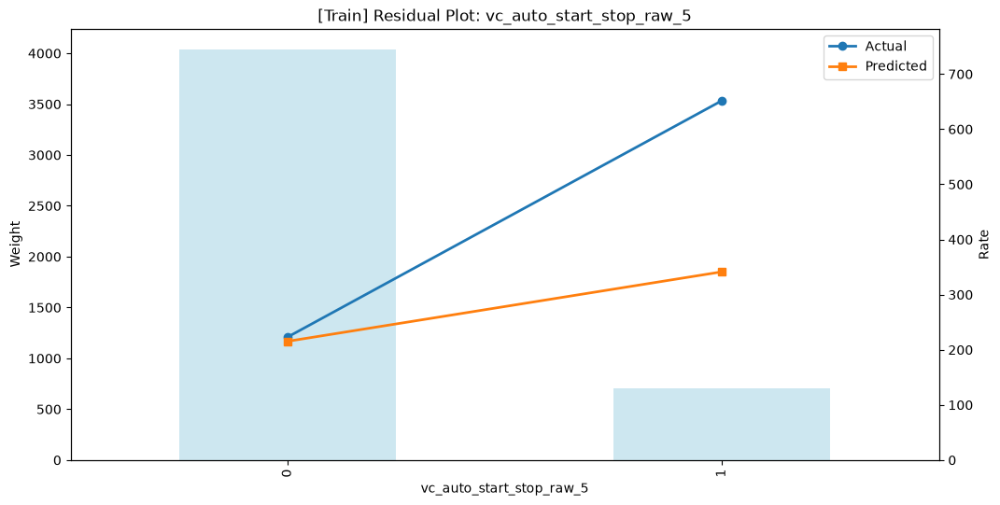

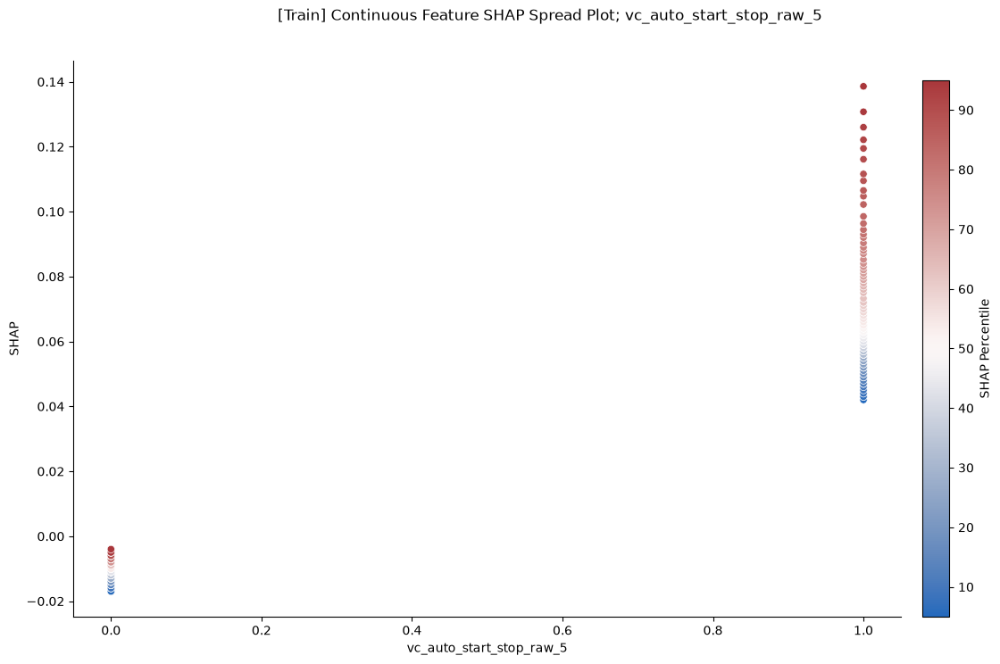

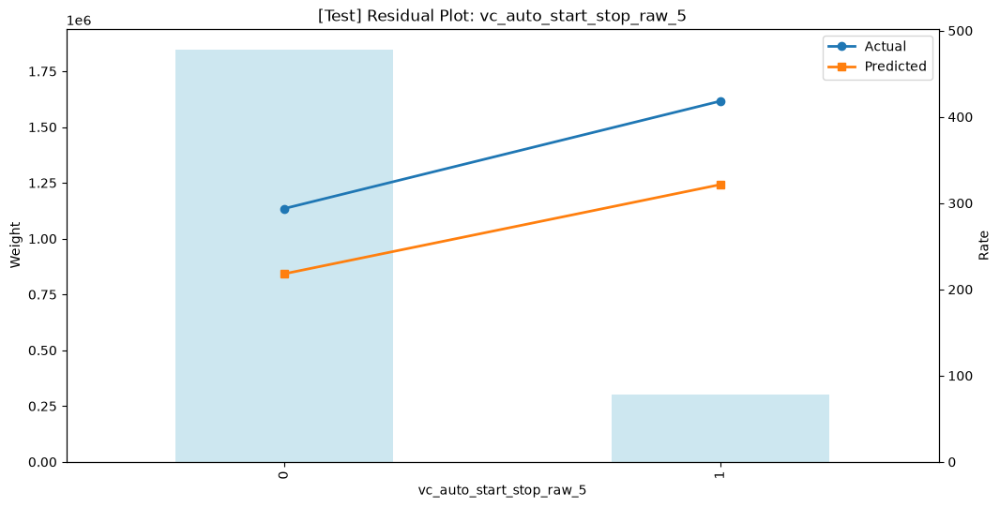

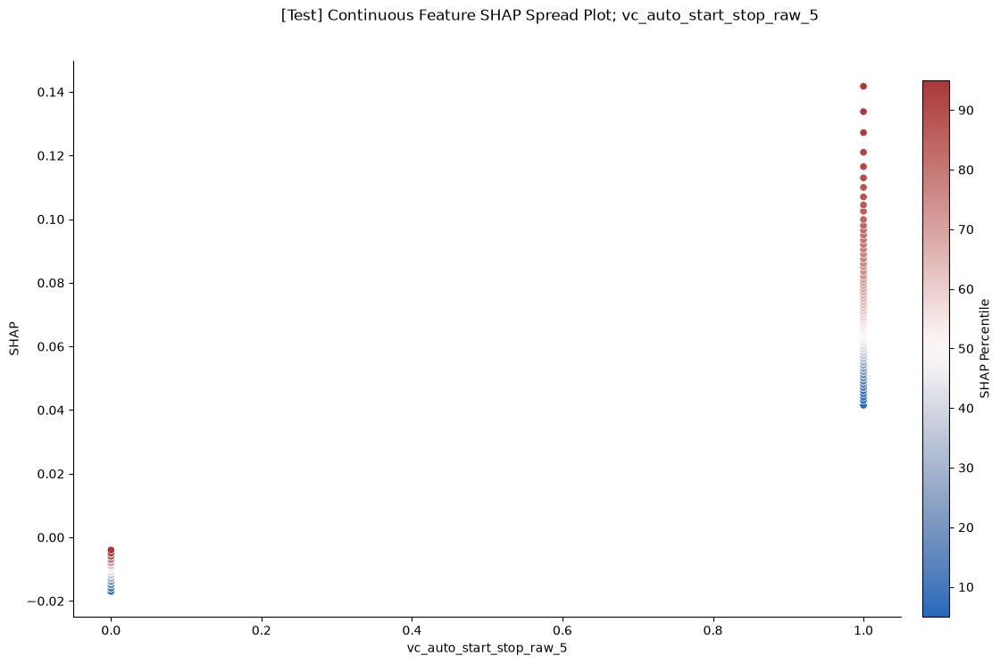


FEATURE: vc_drive_type_fwd_ind


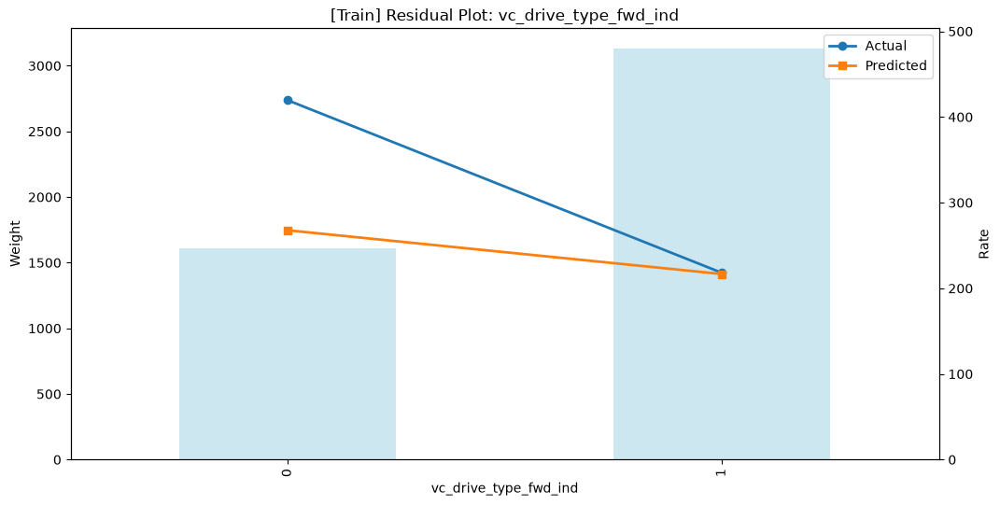

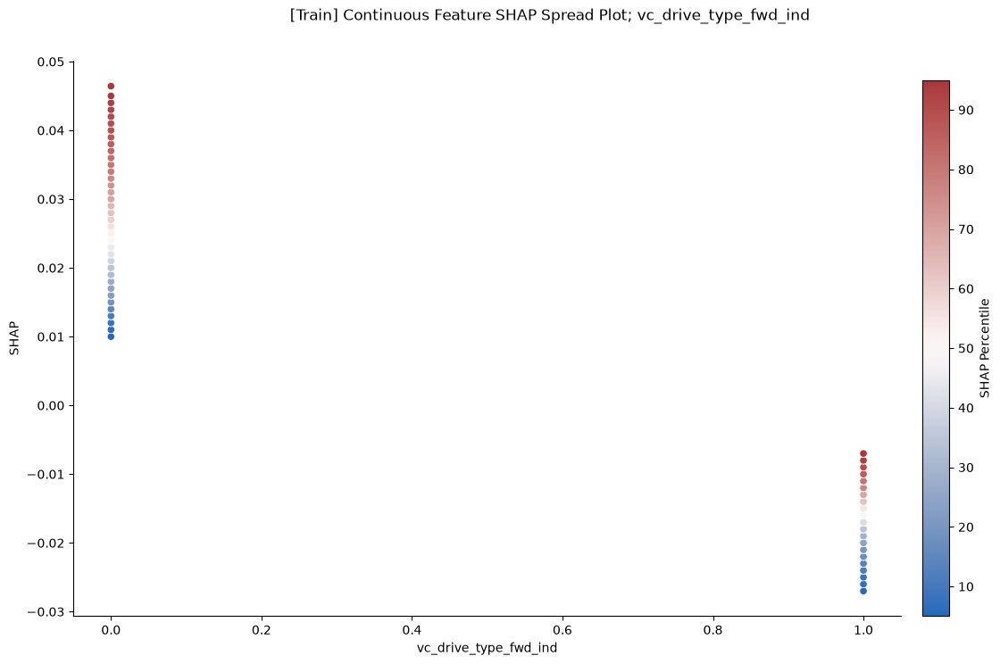

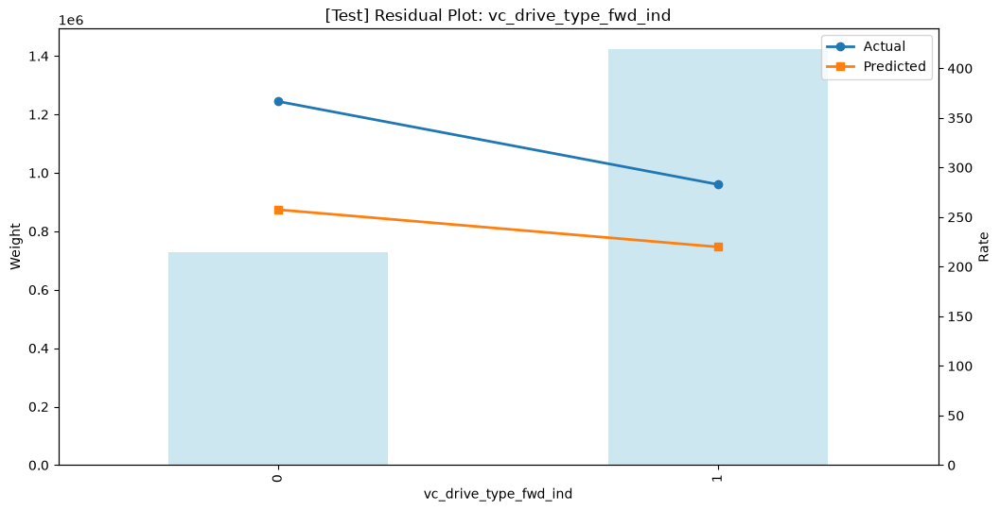

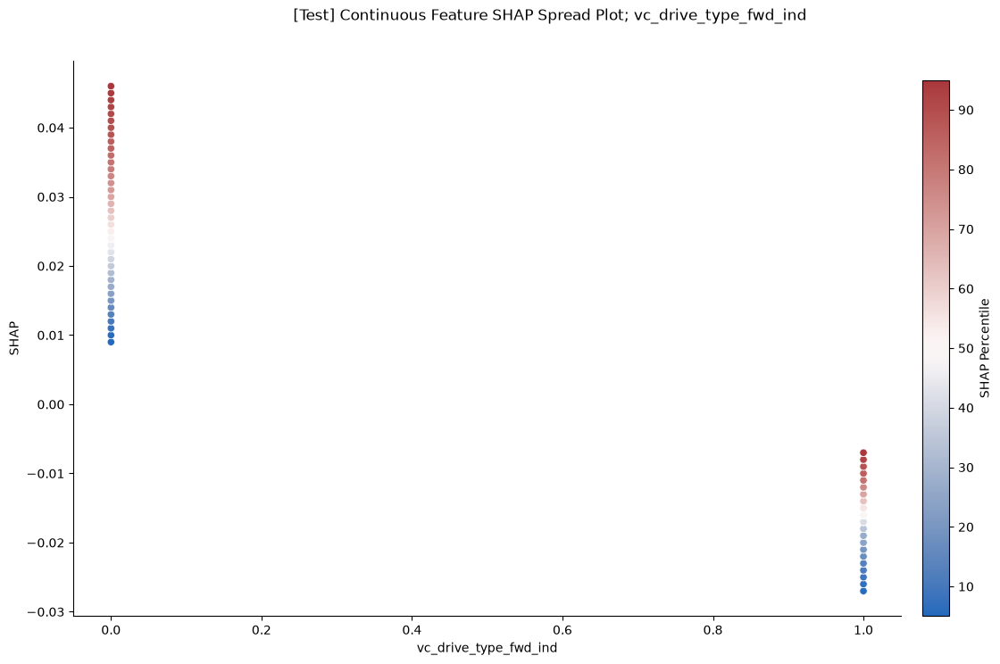


FEATURE: vc_drive_type_rwd_ind


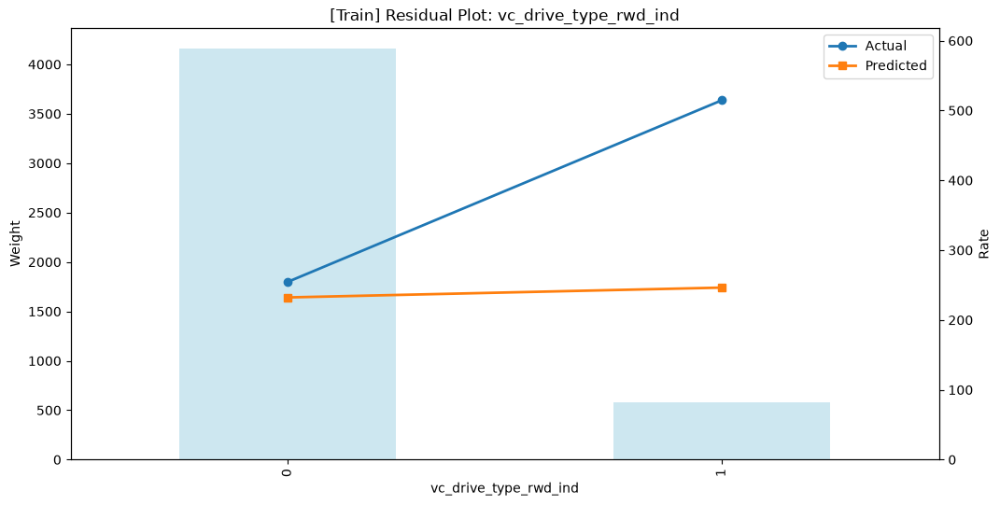

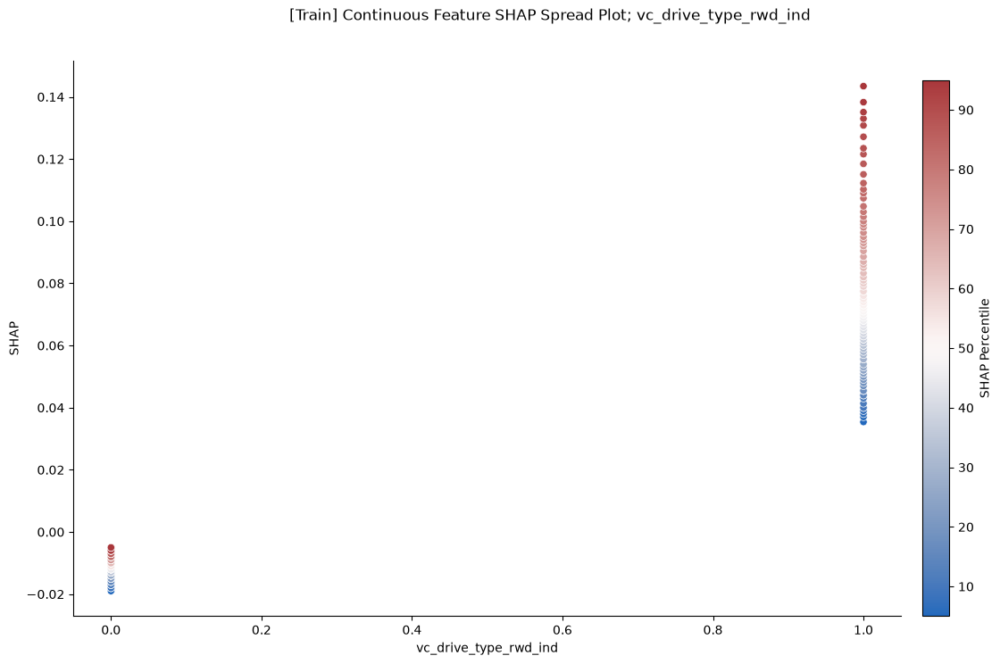

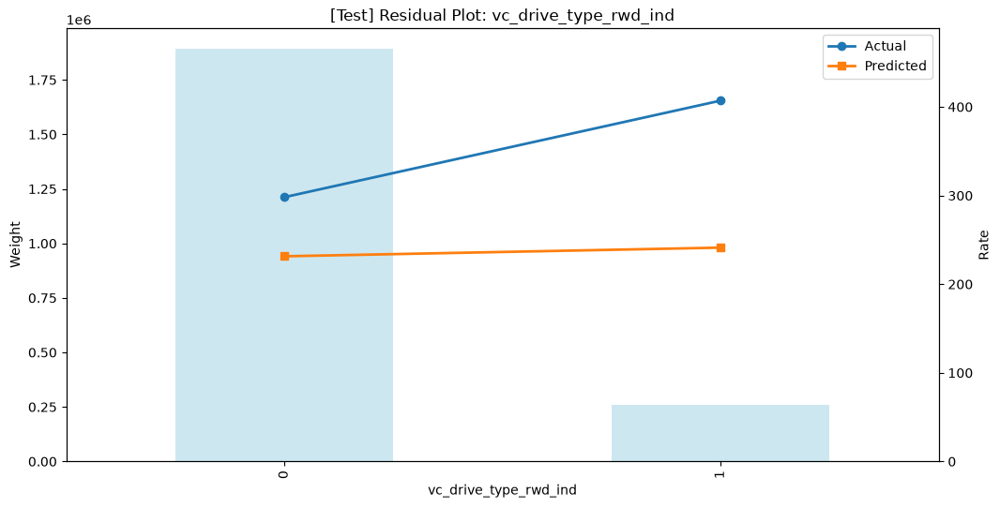

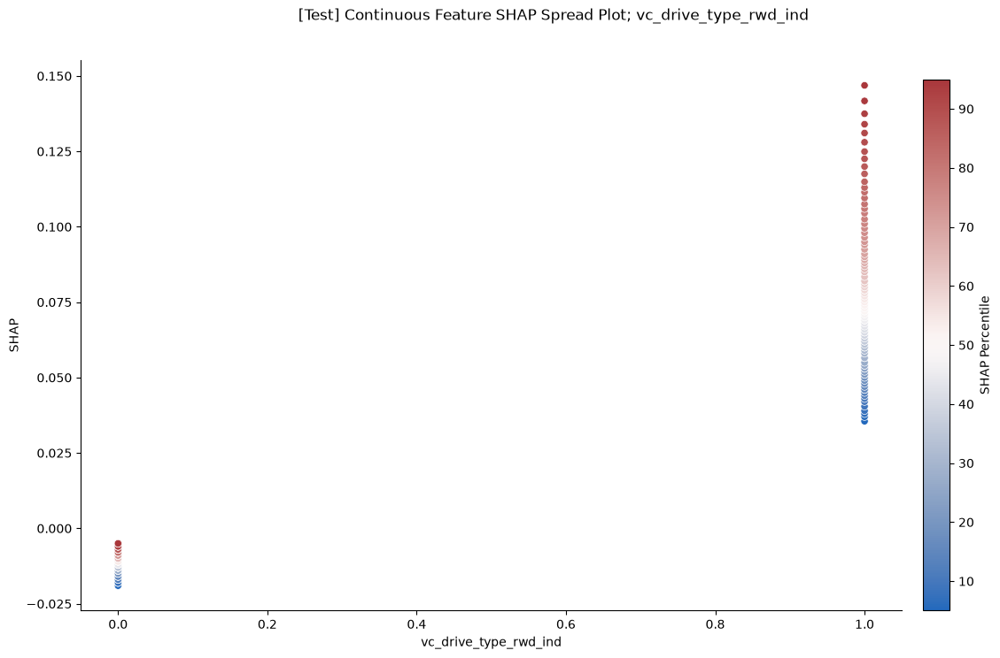


FEATURE: cef_first_sev_prob_ind


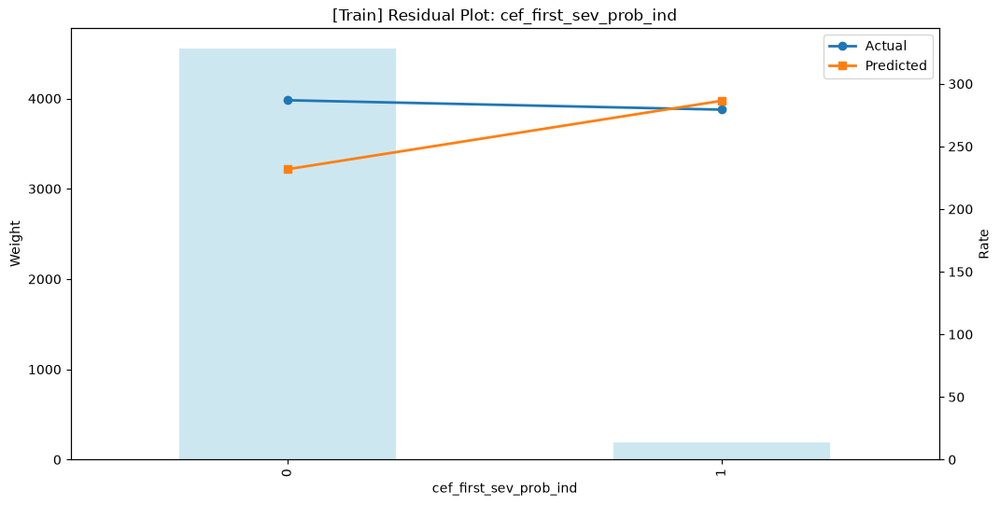

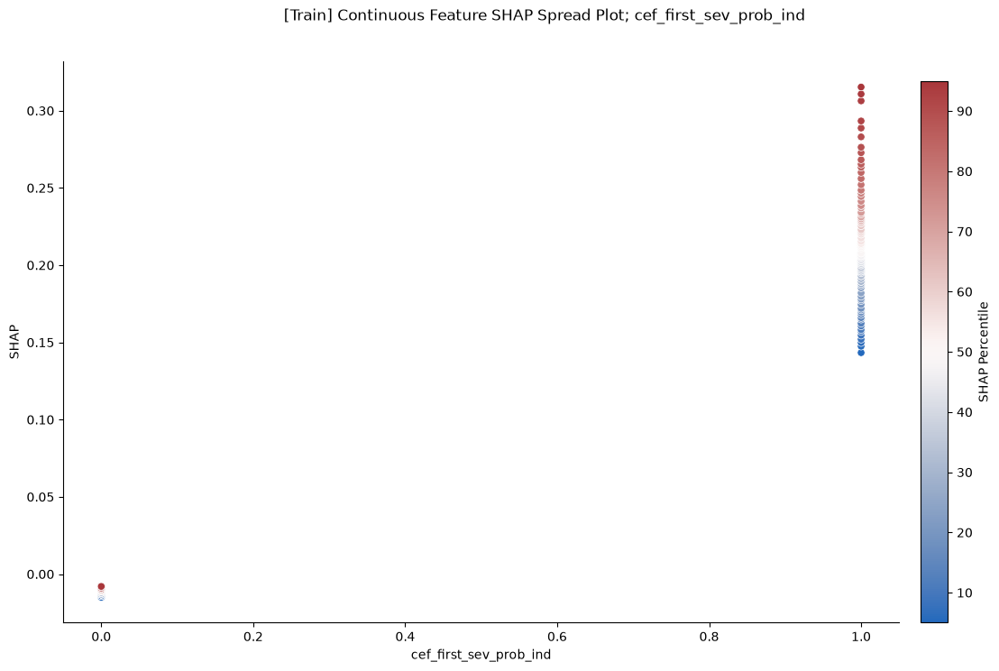

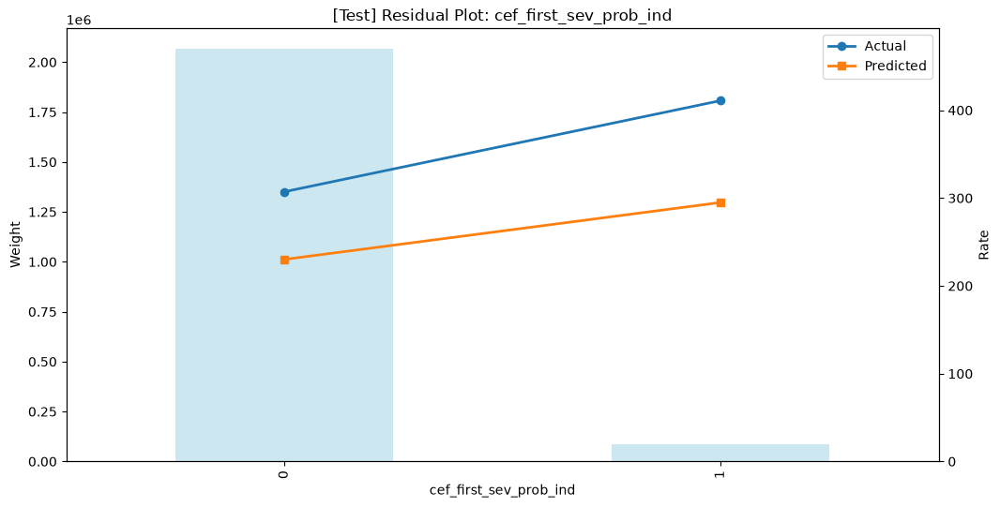

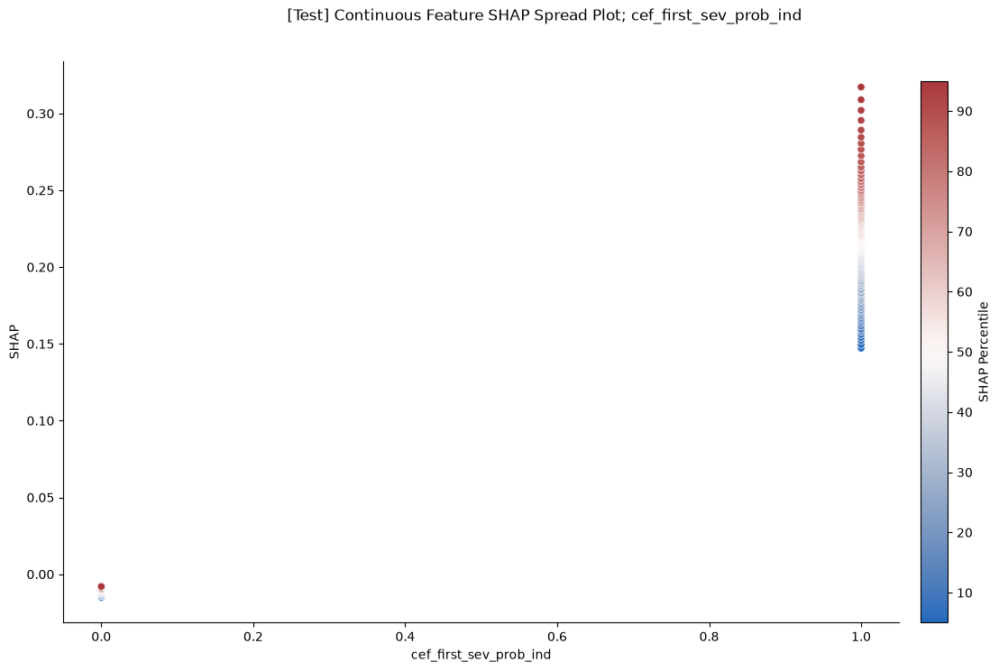


FEATURE: vc_power_sunroof_raw_3


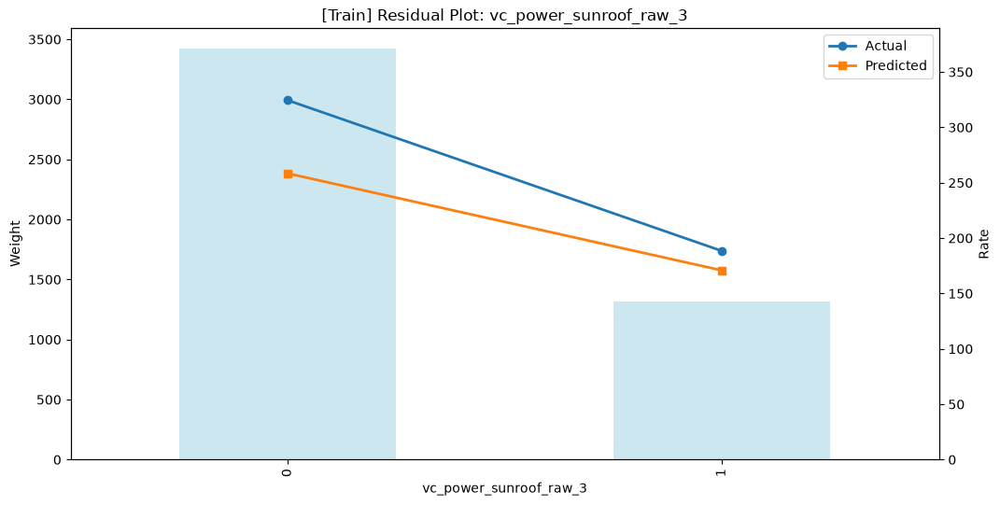

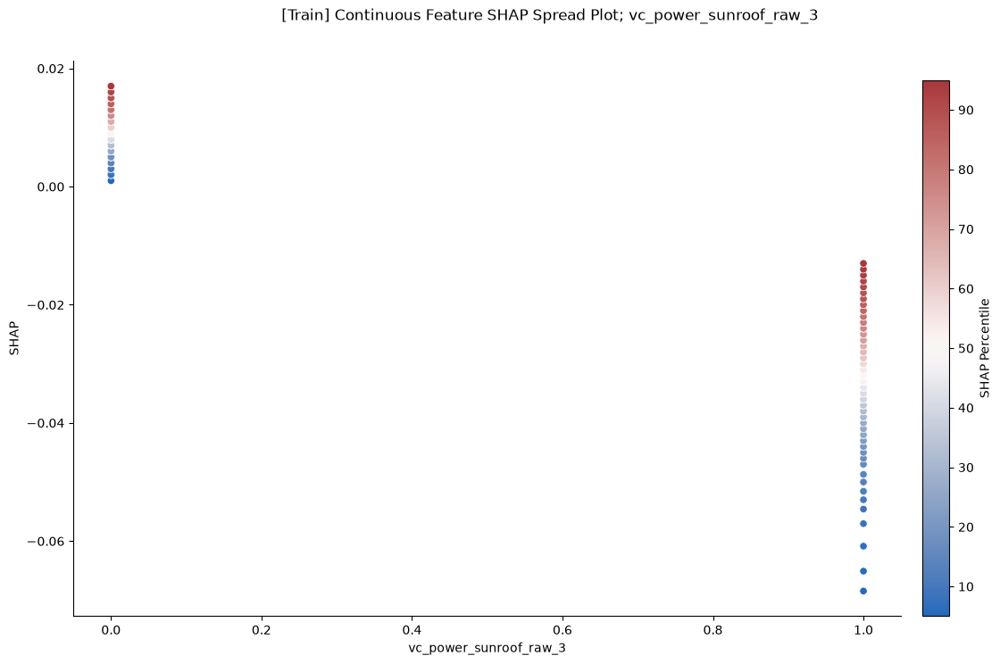

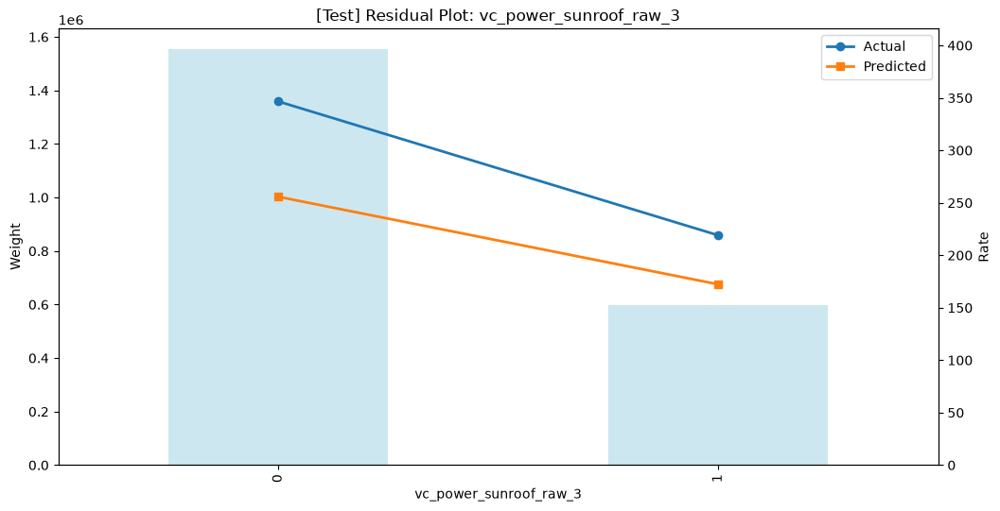

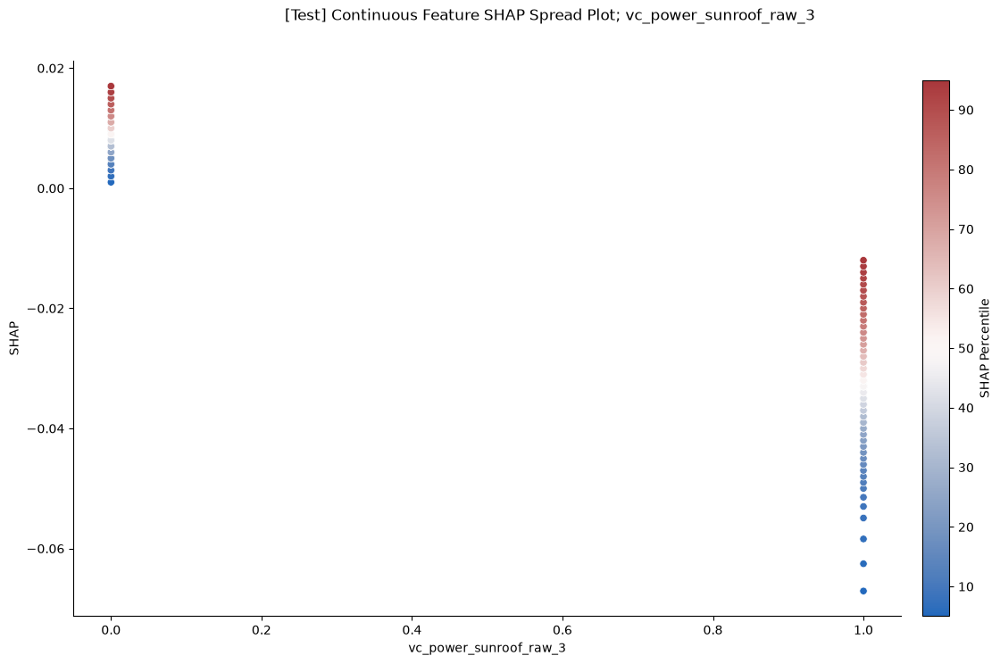


FEATURE: vc_seating_rows_raw


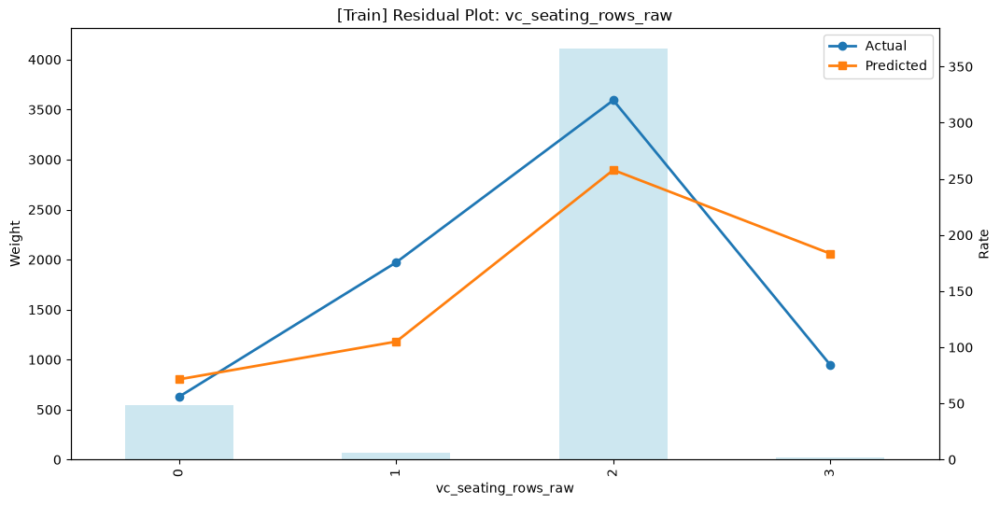

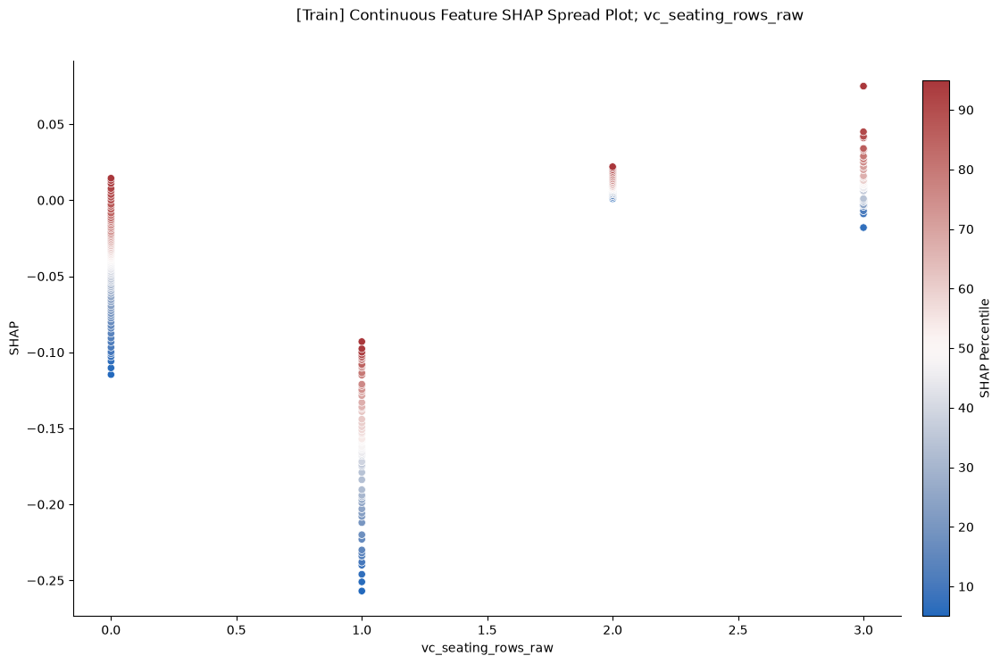

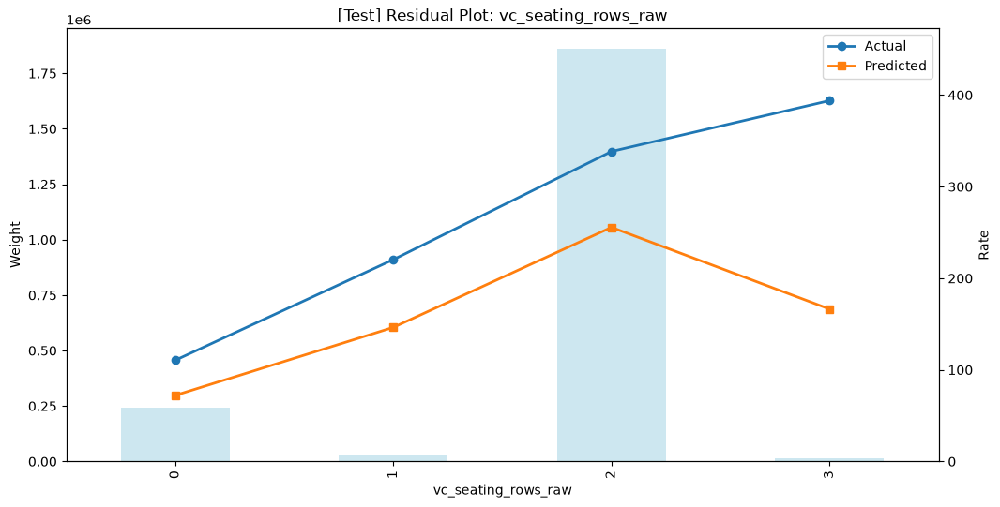

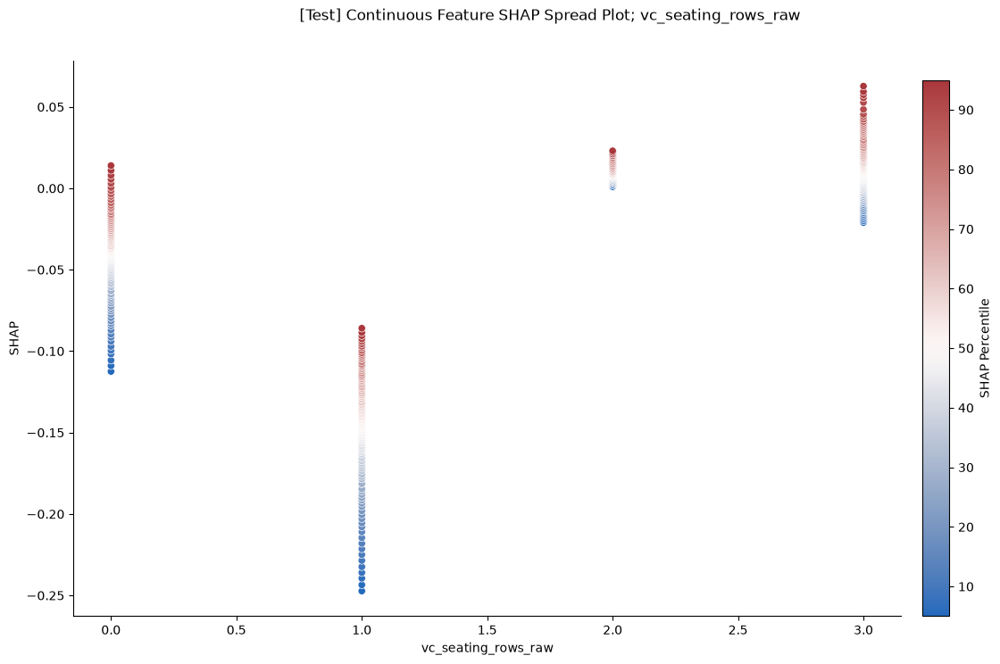


FEATURE: vc_touch_screen_raw_0


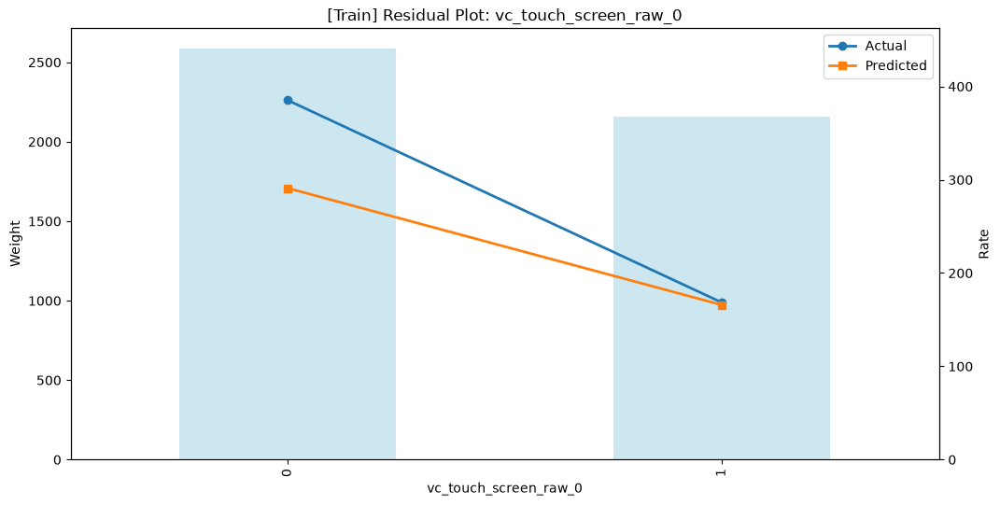

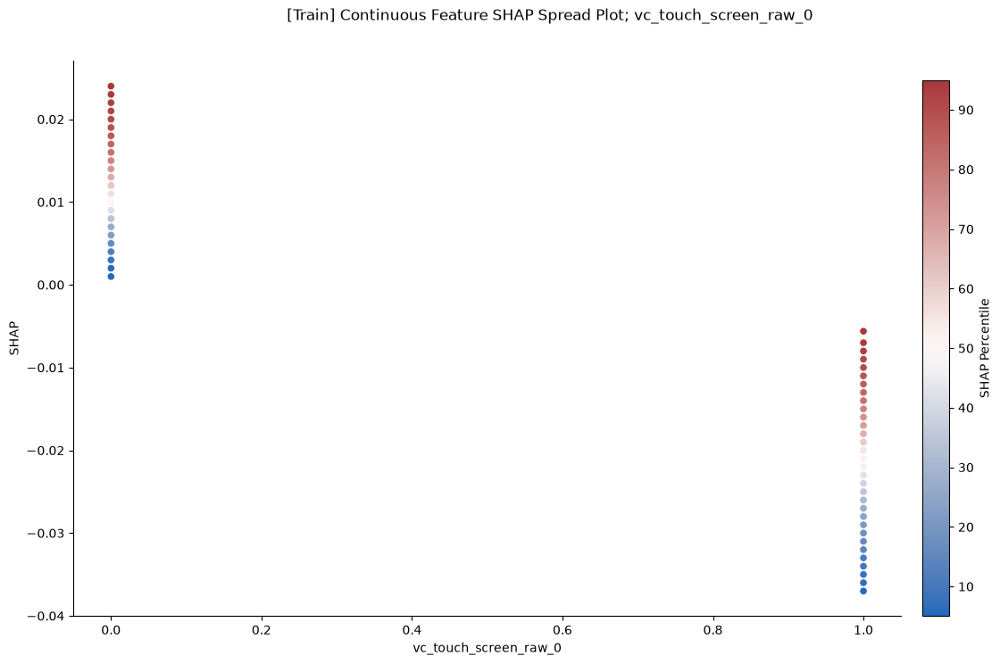

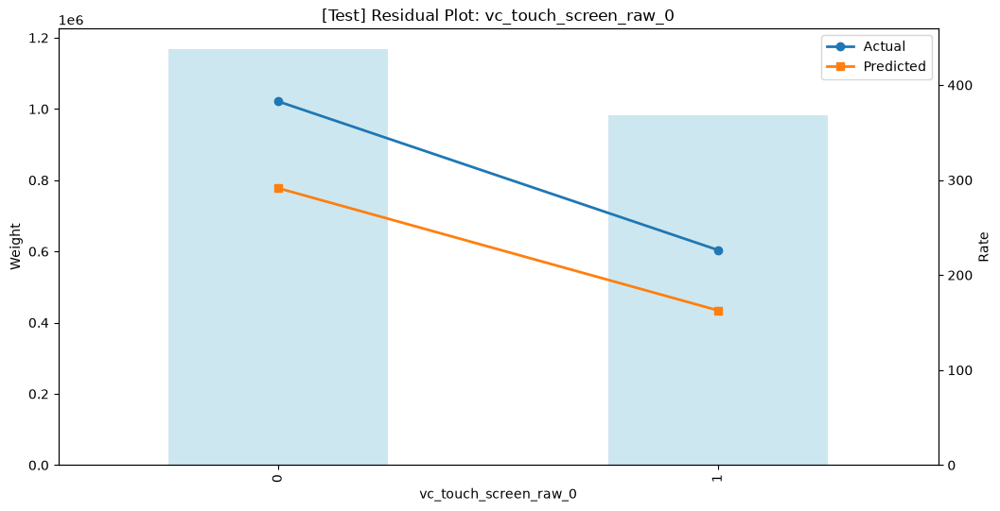

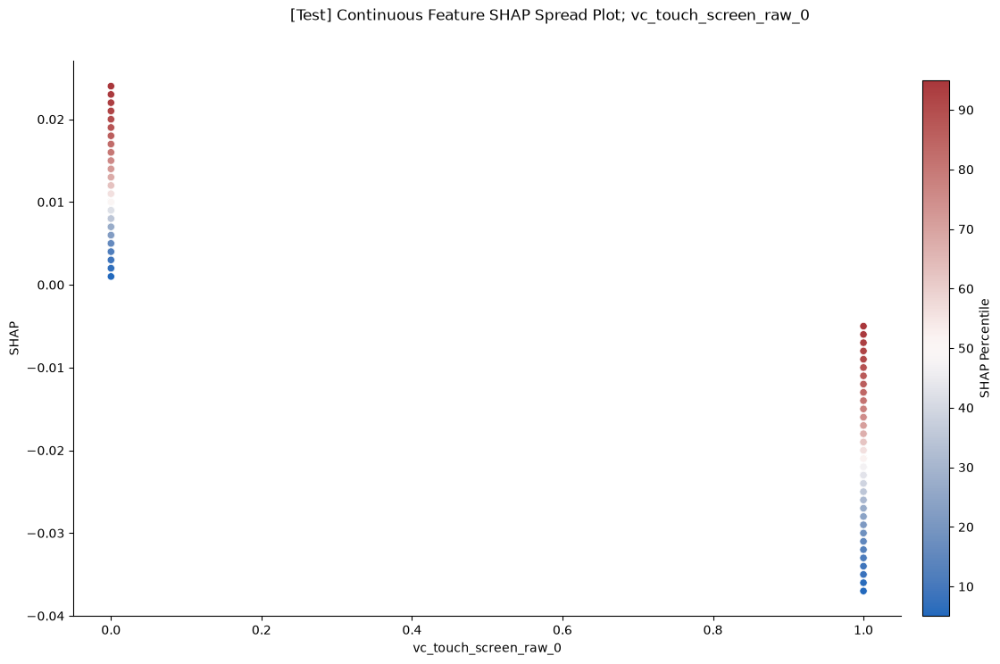


FEATURE: vc_transmission_type_automatic_ind


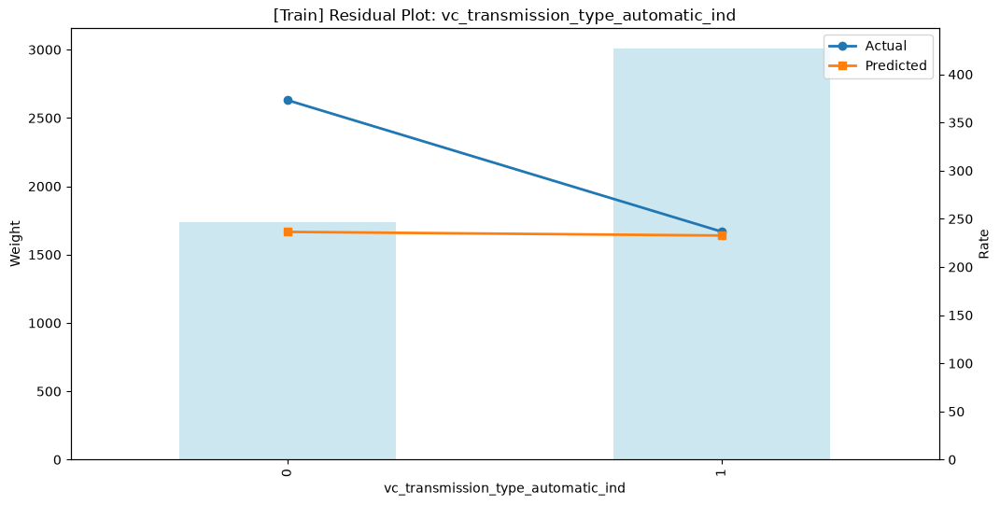

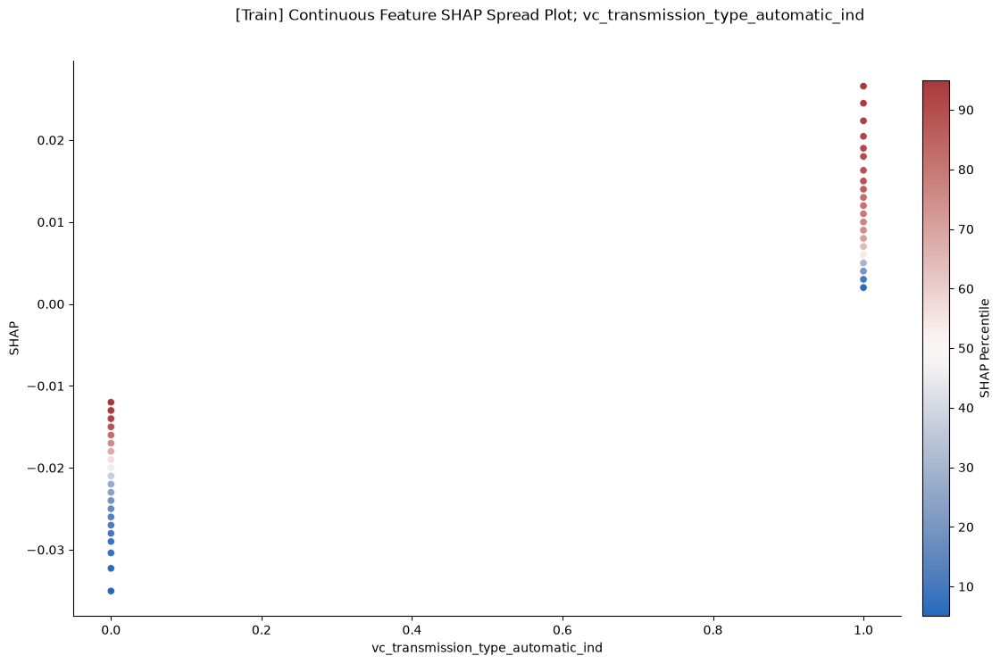

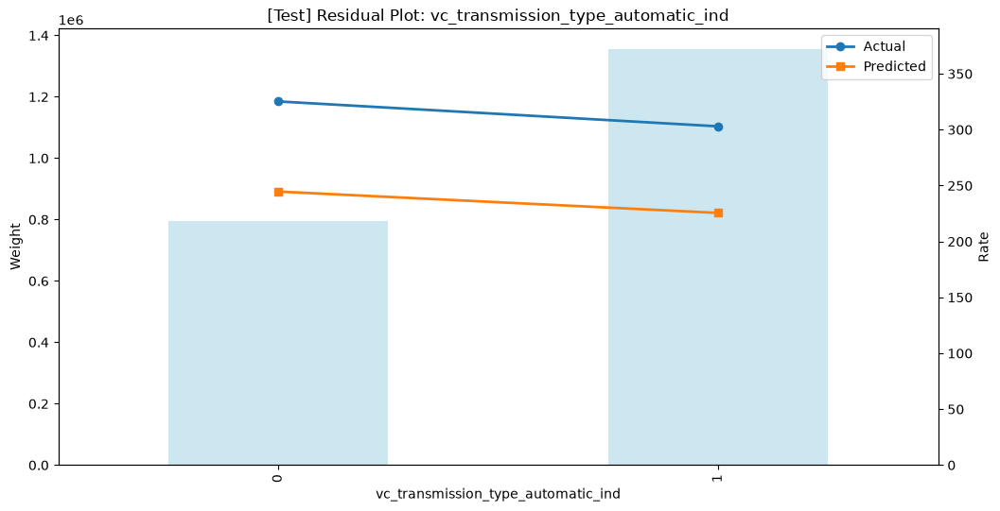

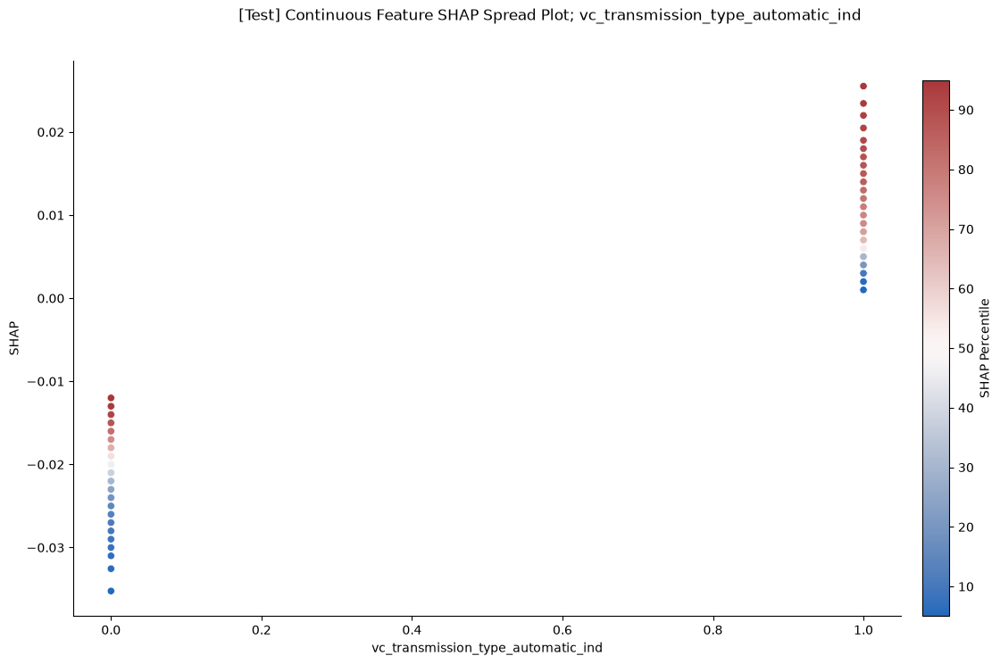


FEATURE: vc_heated_side_mirrors_raw


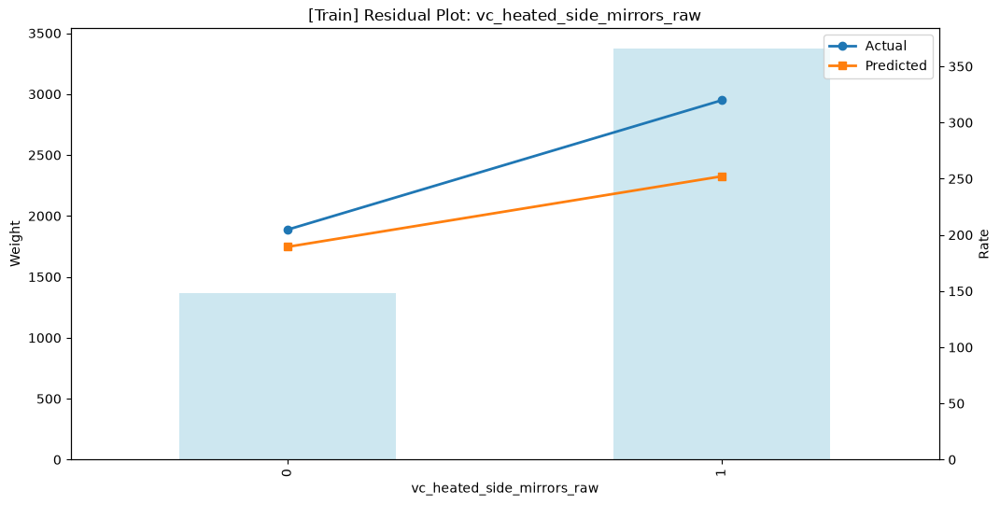

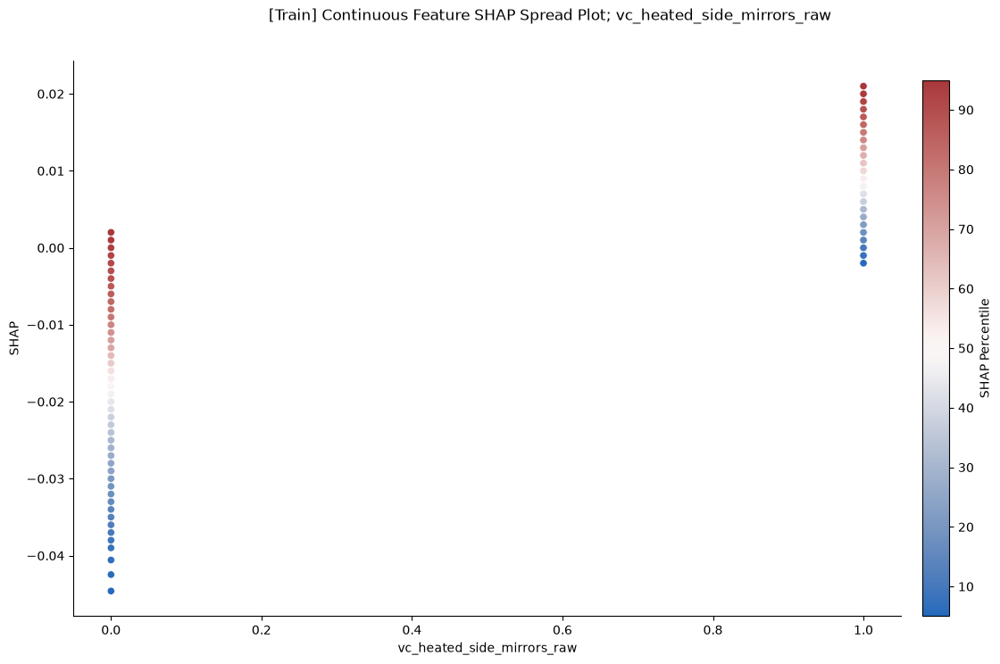

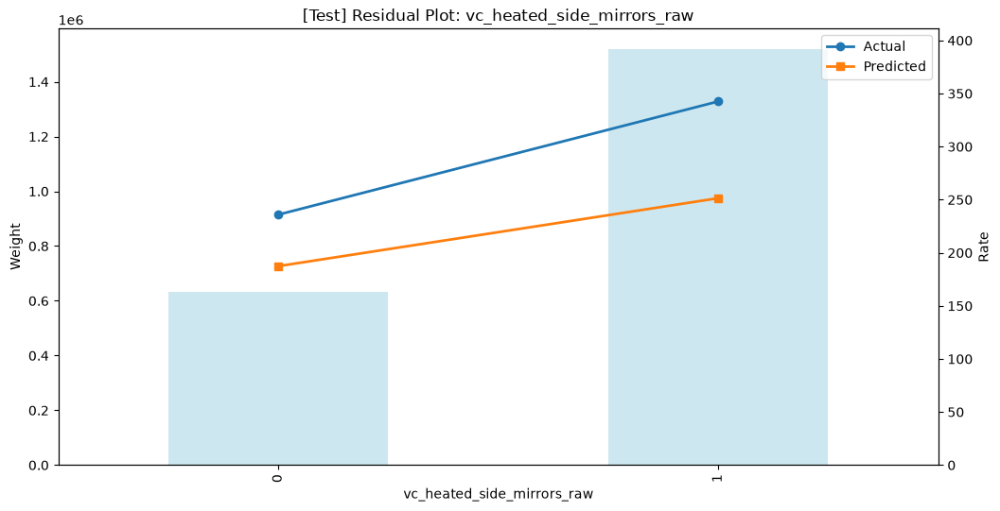

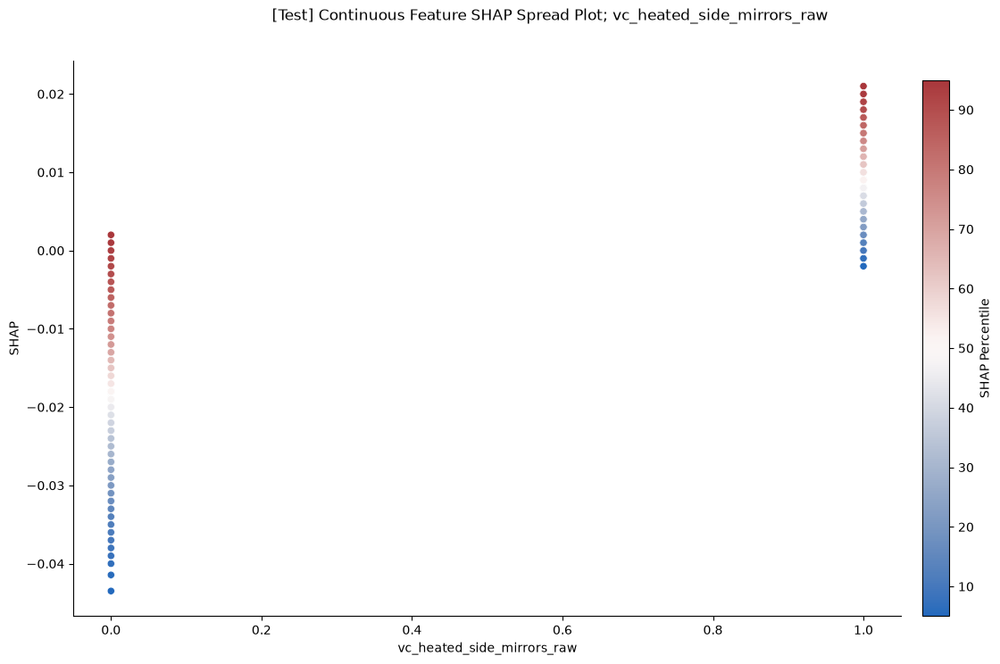


FEATURE: vc_auto_start_stop_raw_0


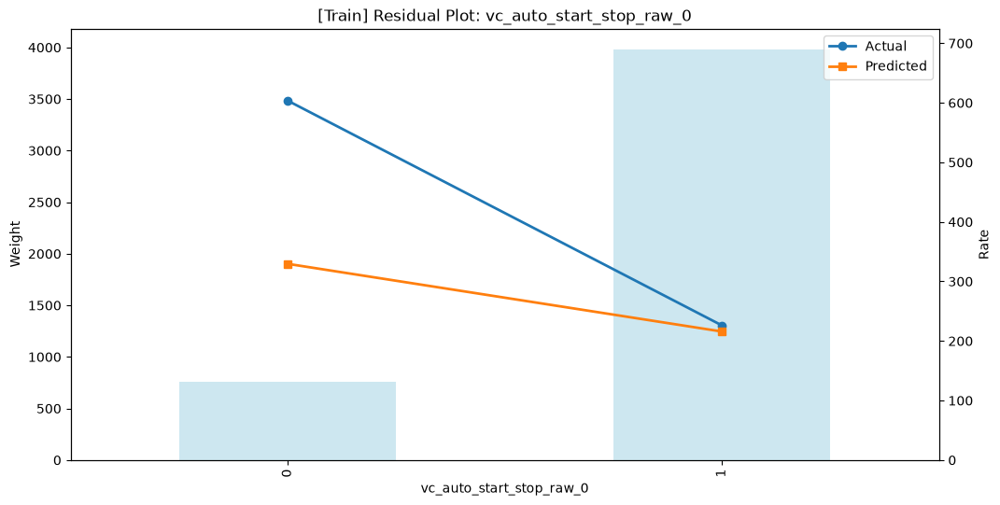

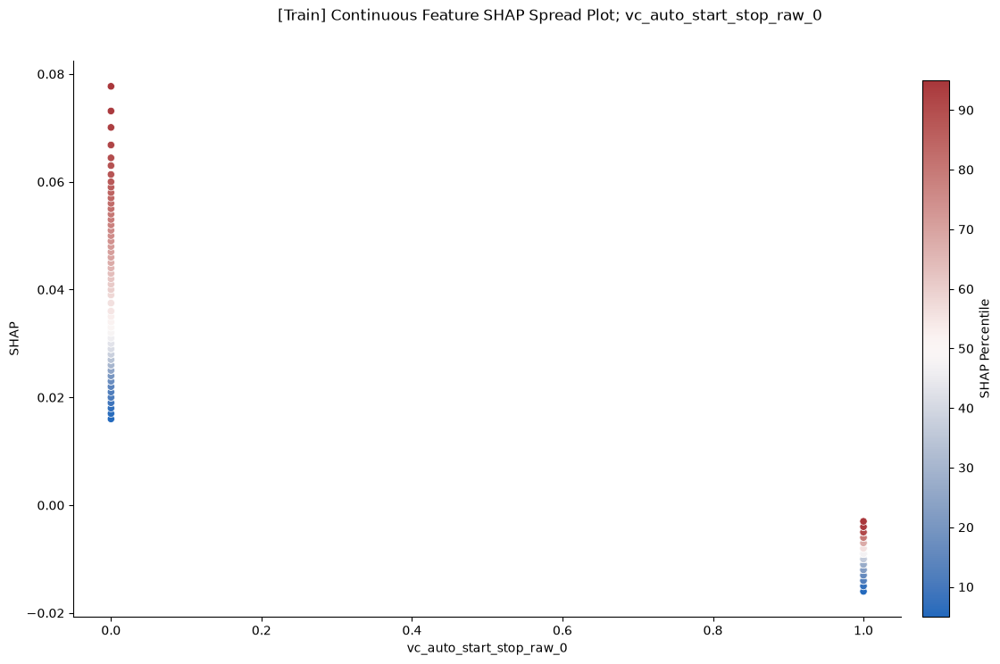

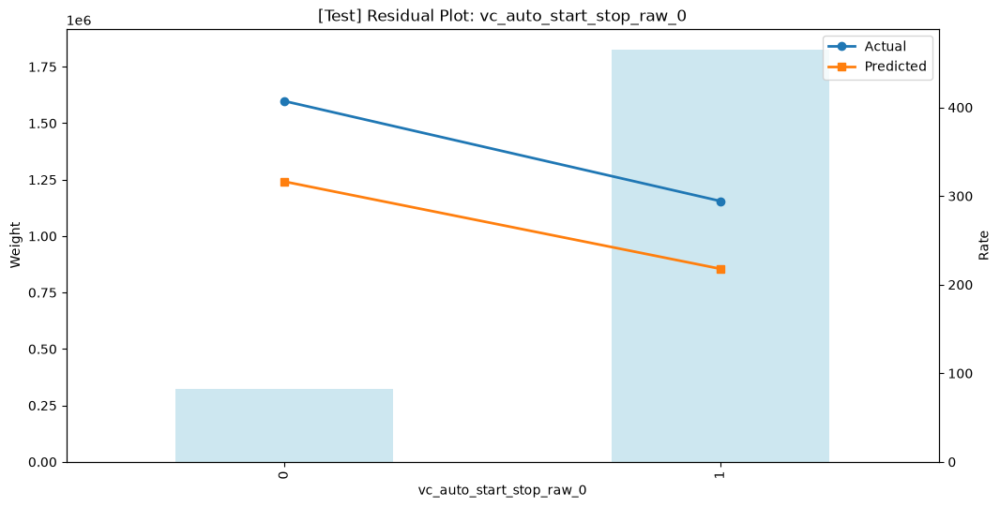

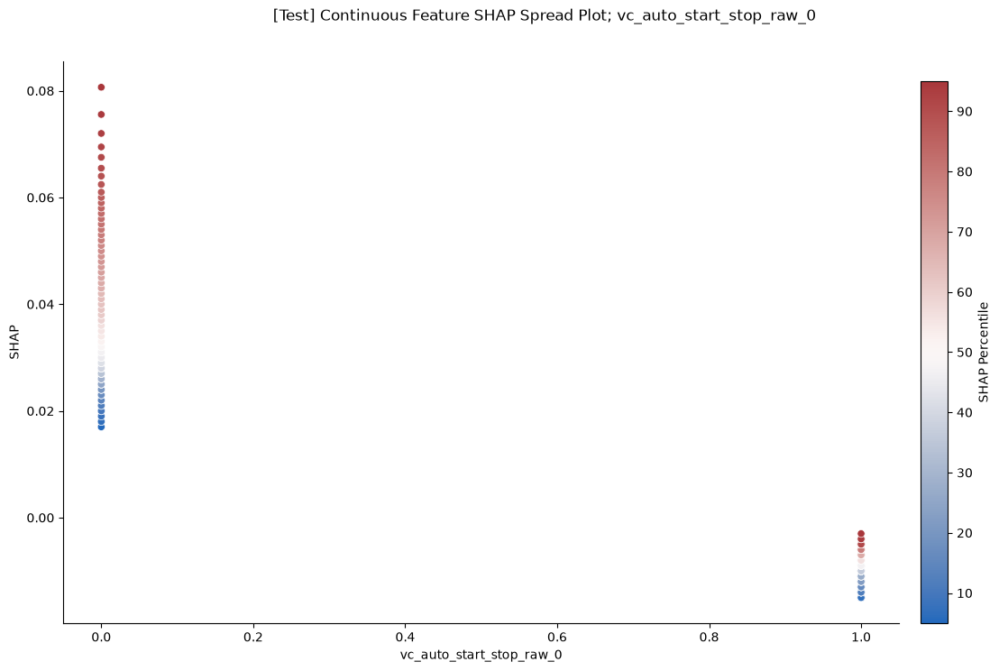


FEATURE: vc_passive_collision_avoidance_system_raw_0


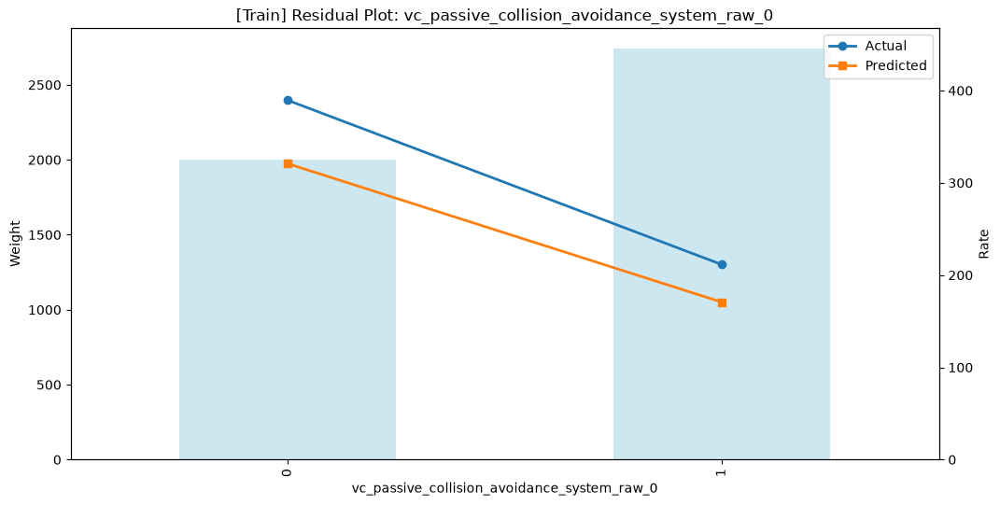

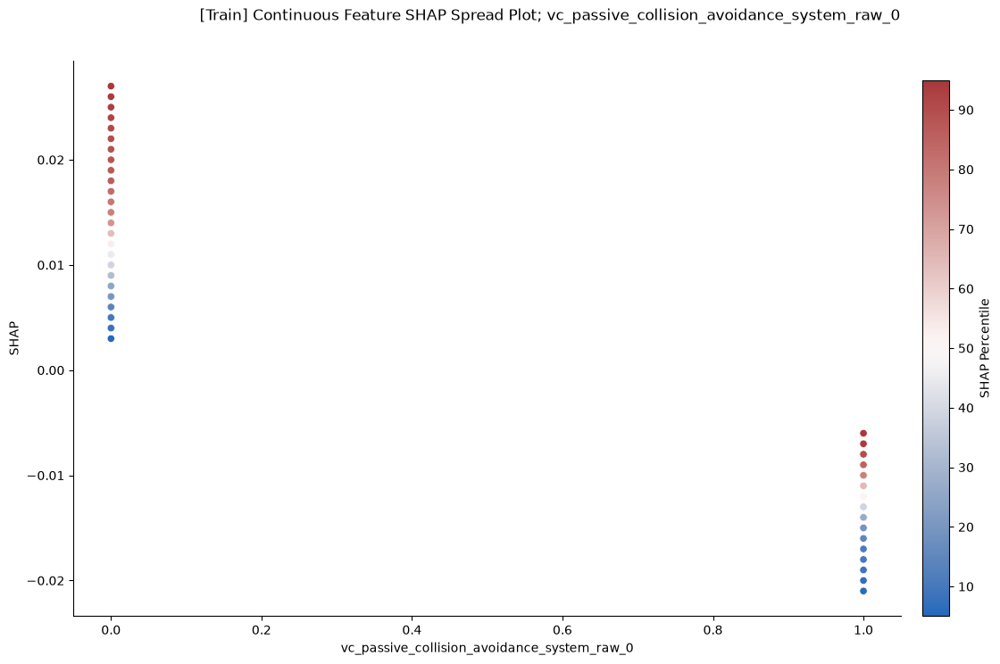

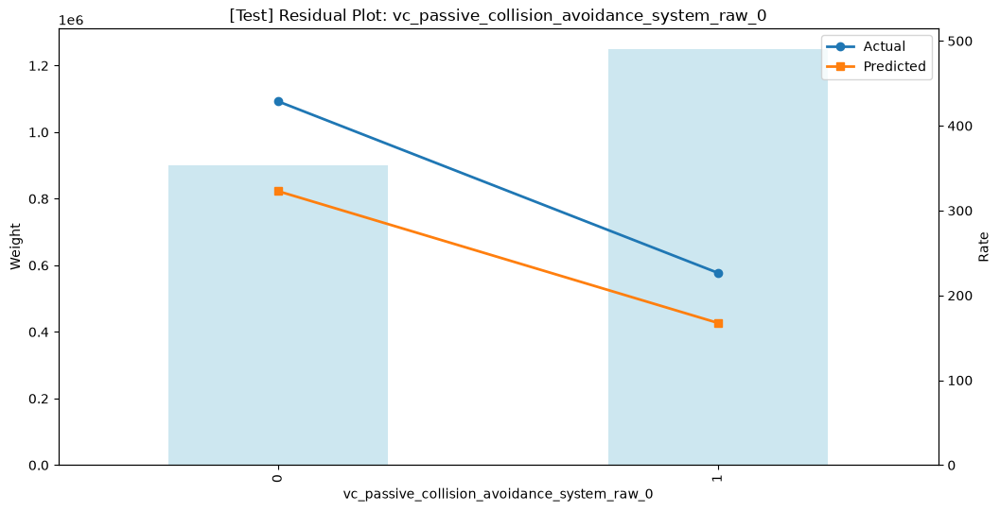

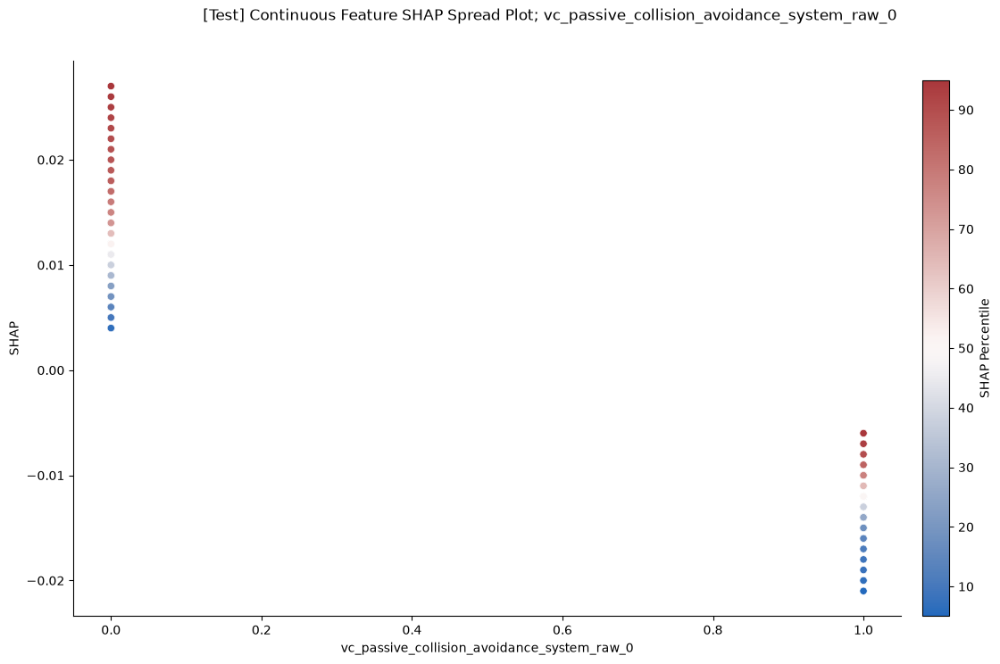


FEATURE: vc_auto_dimming_rearview_mirror_raw_3


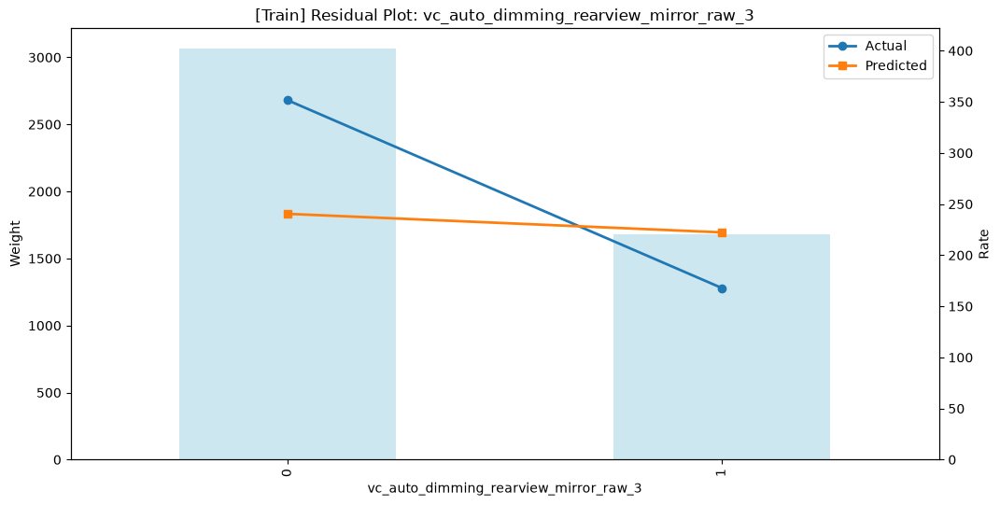

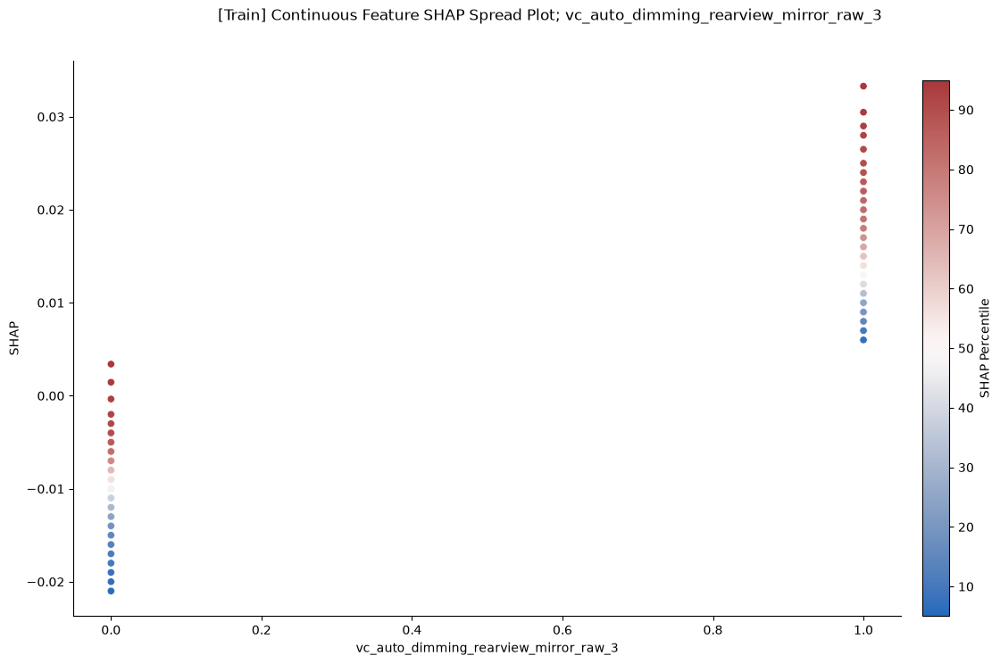

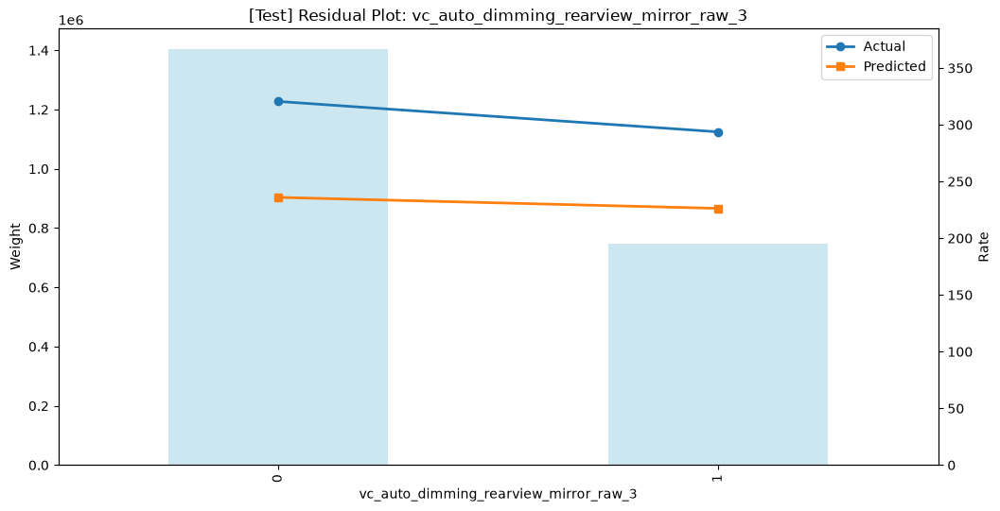

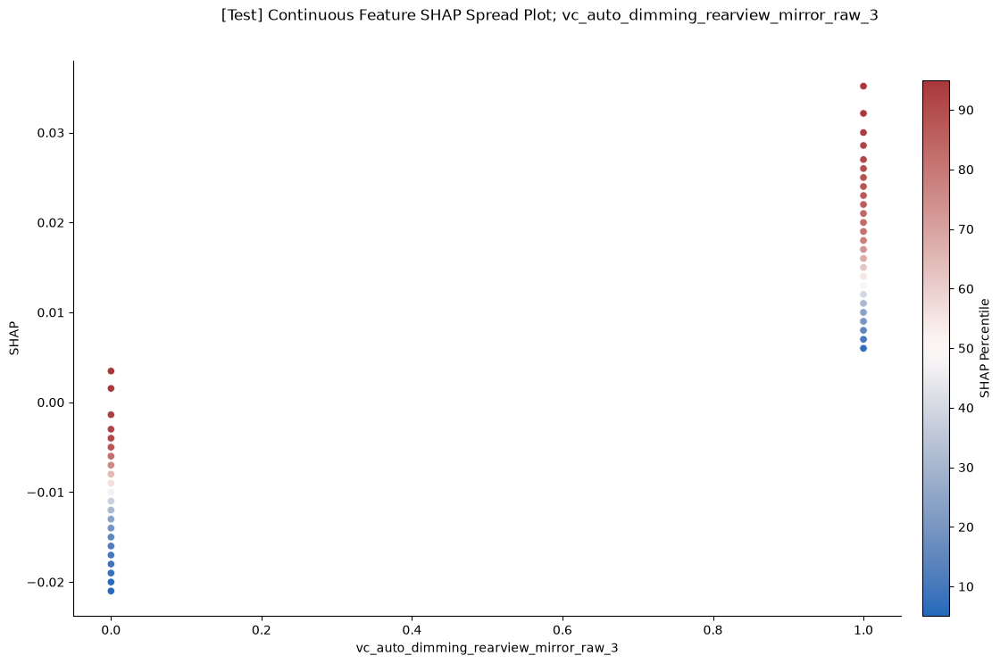


FEATURE: vc_driver_attention_system_raw_5


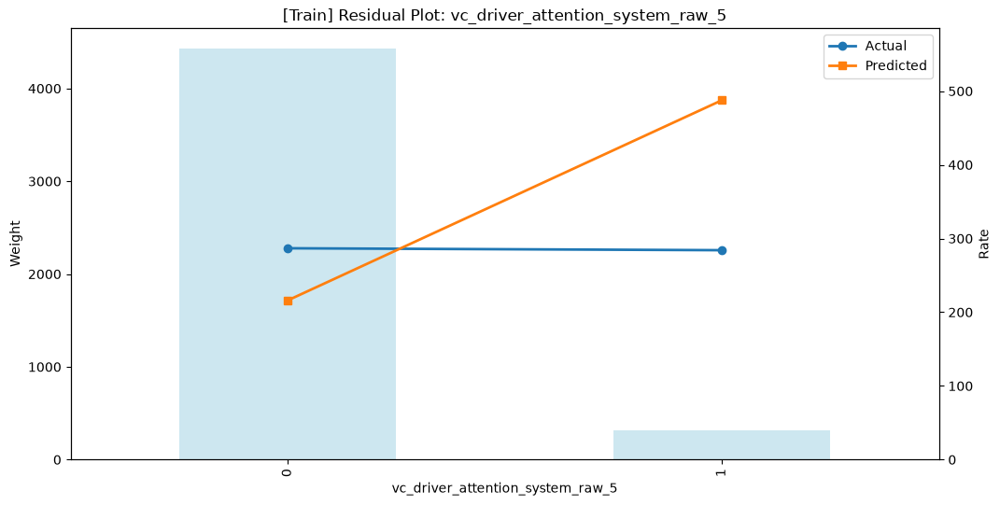

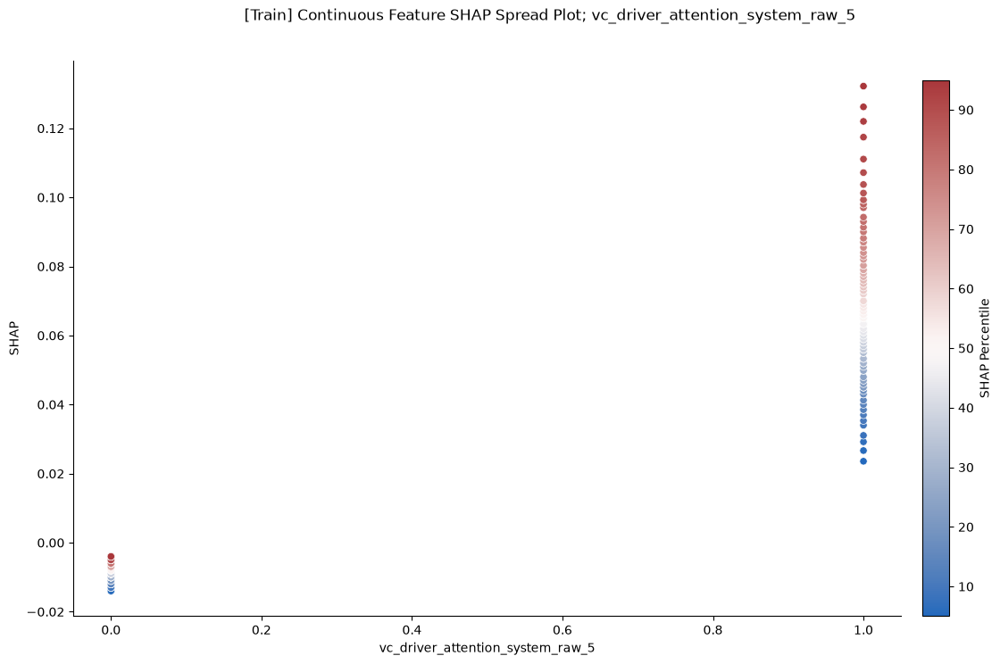

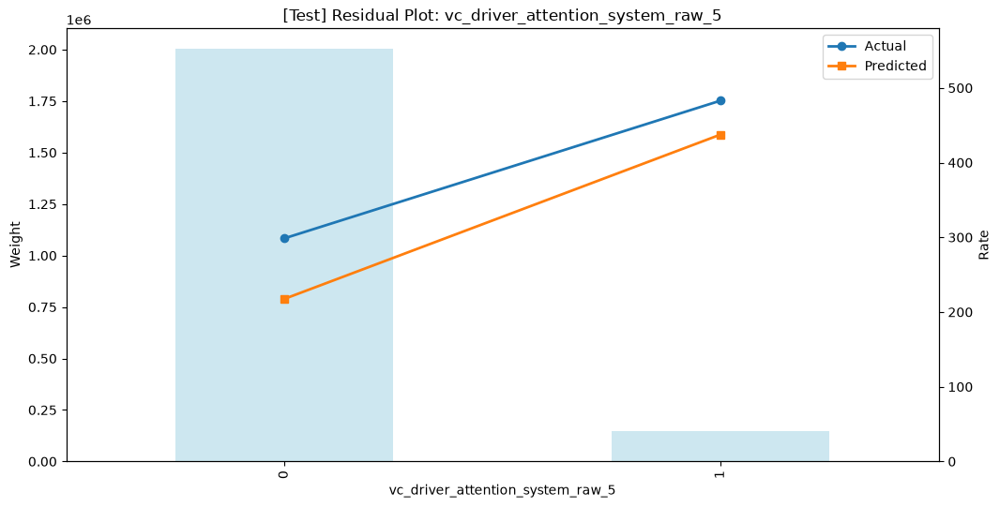

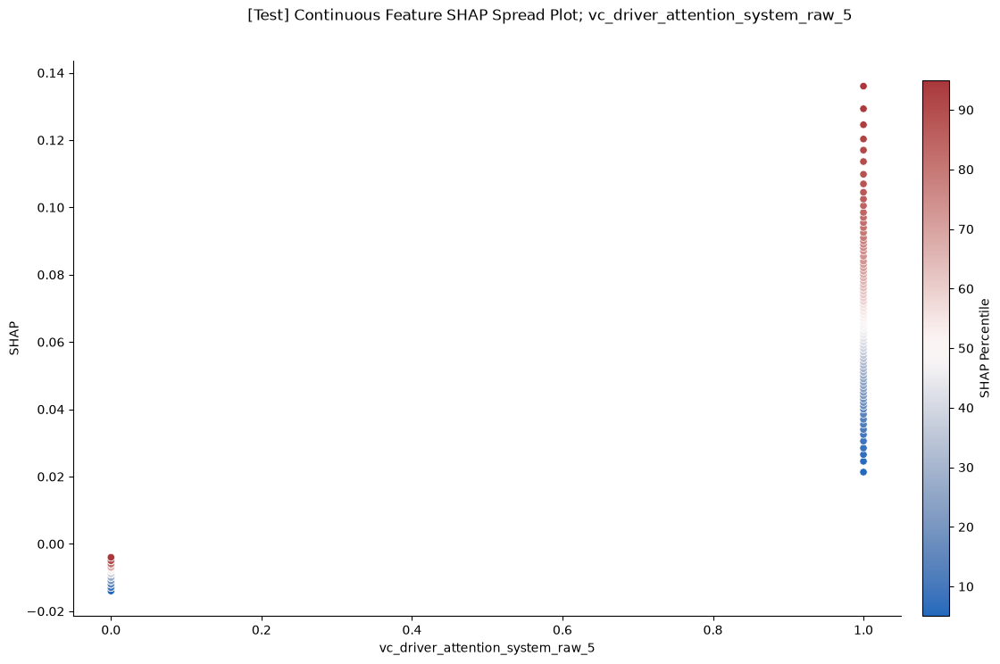


FEATURE: gender_male_ind


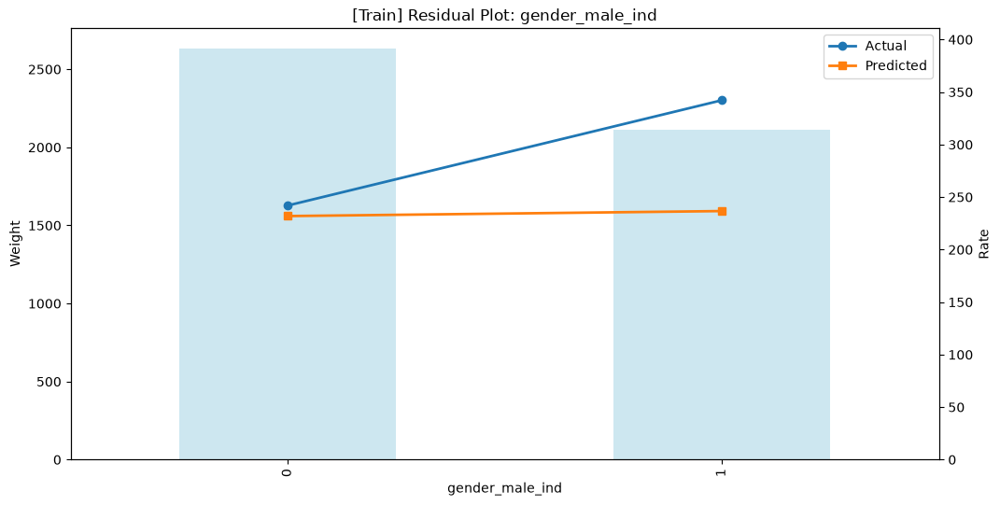

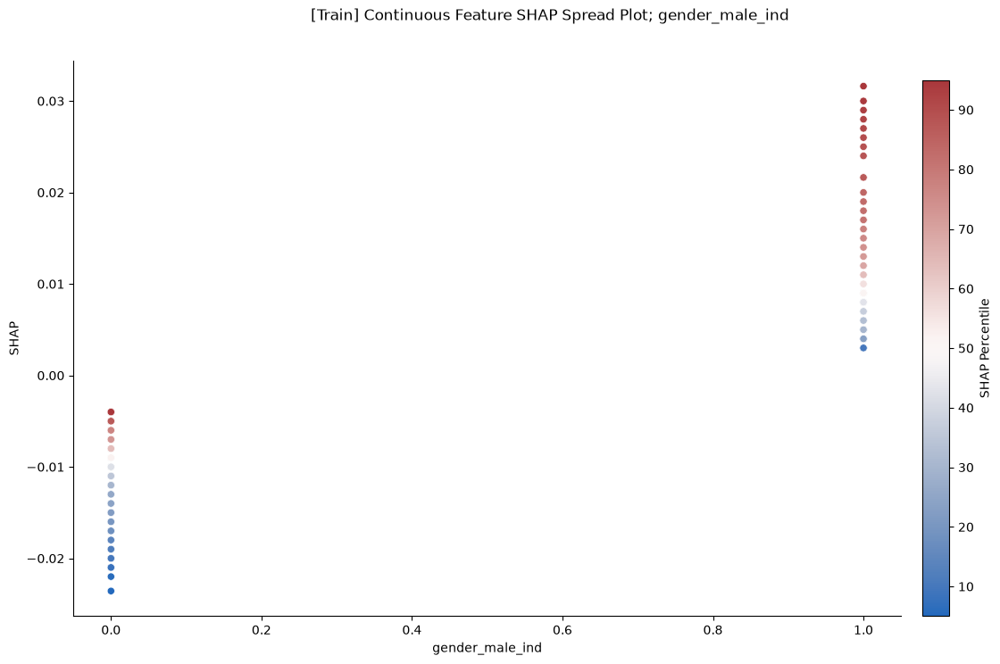

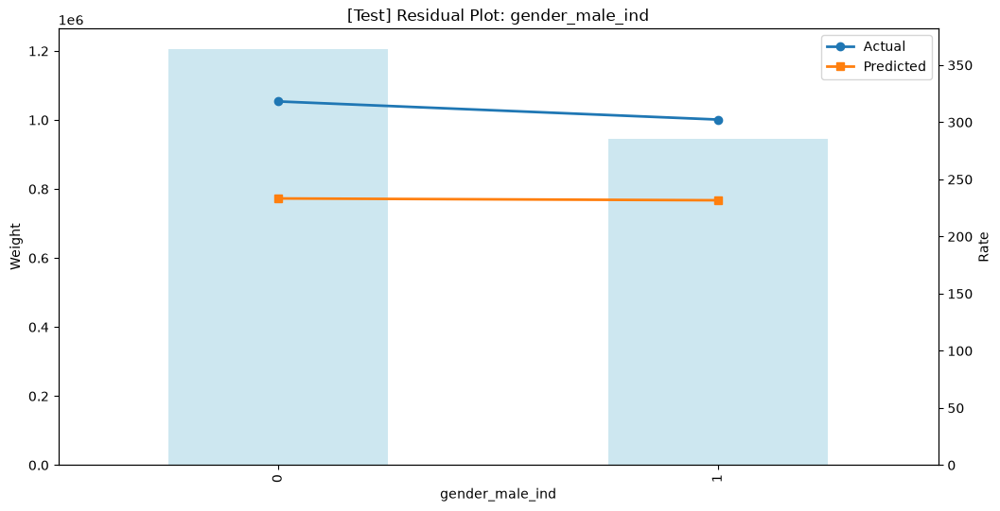

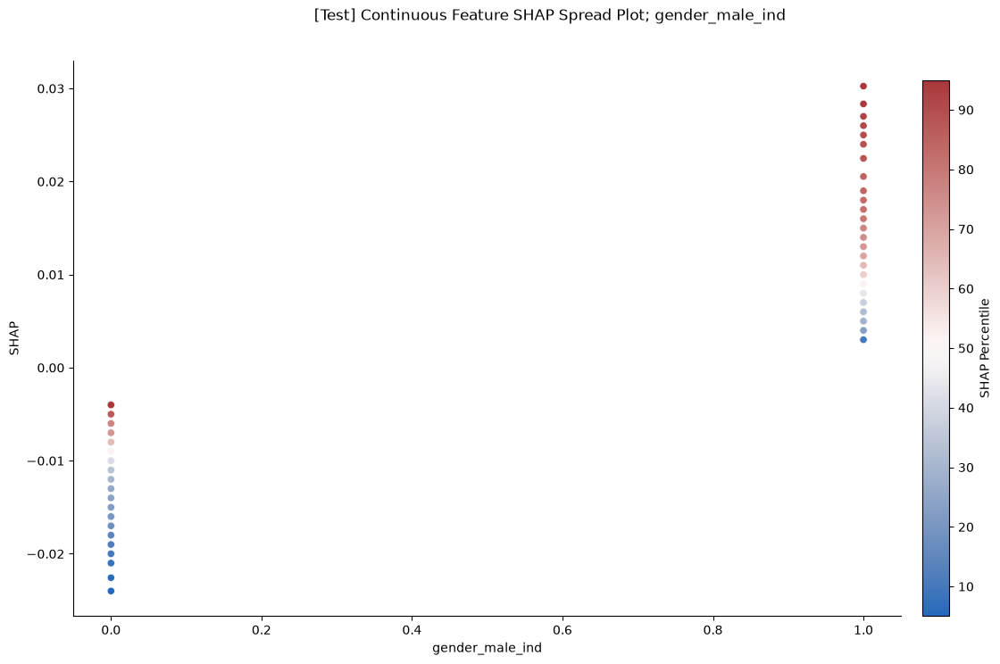


FEATURE: vc_camera_raw_5


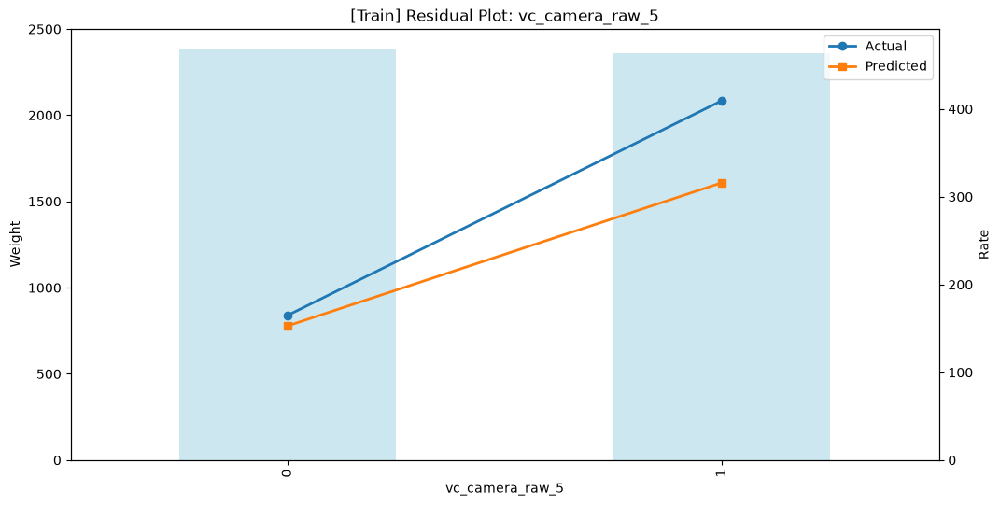

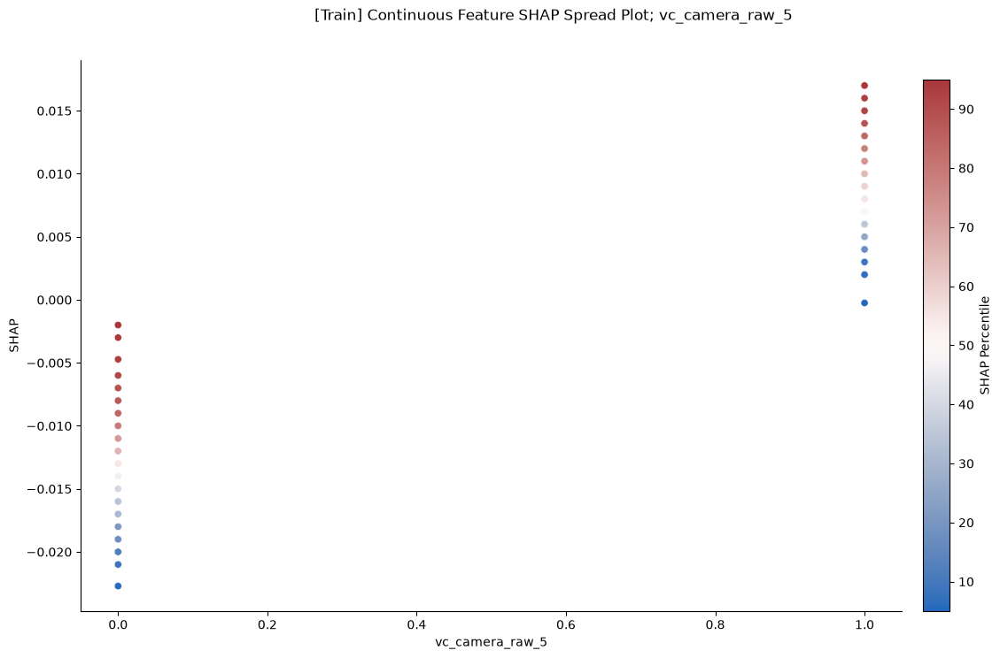

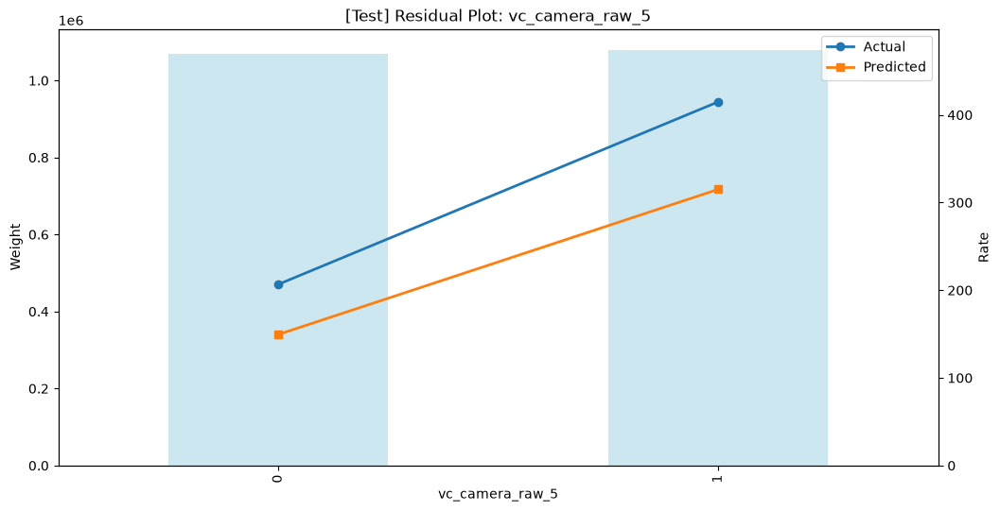

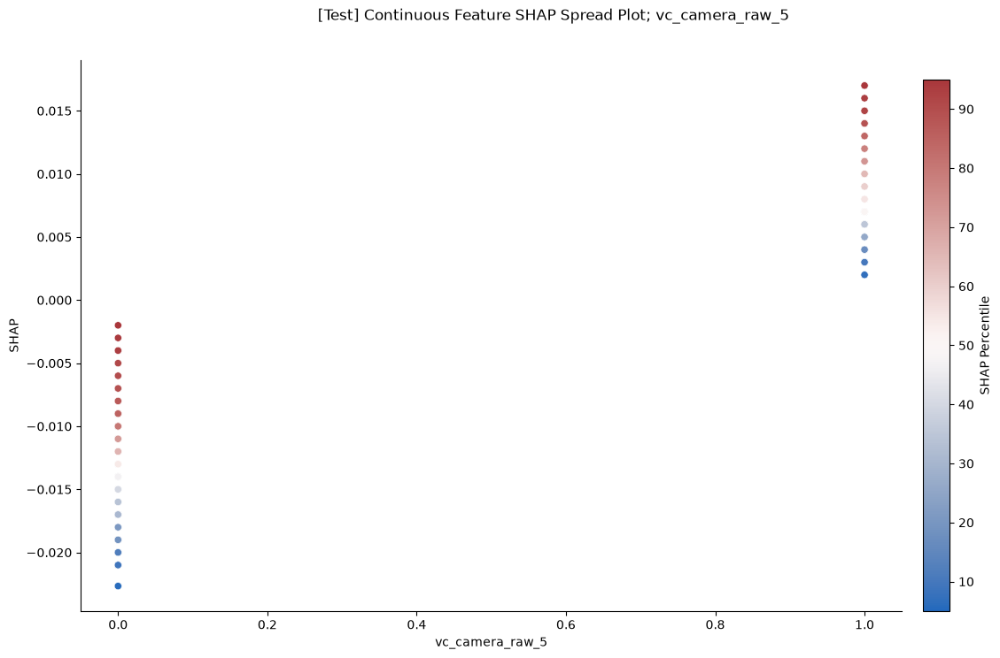


FEATURE: vc_electronic_braking_system_raw_5


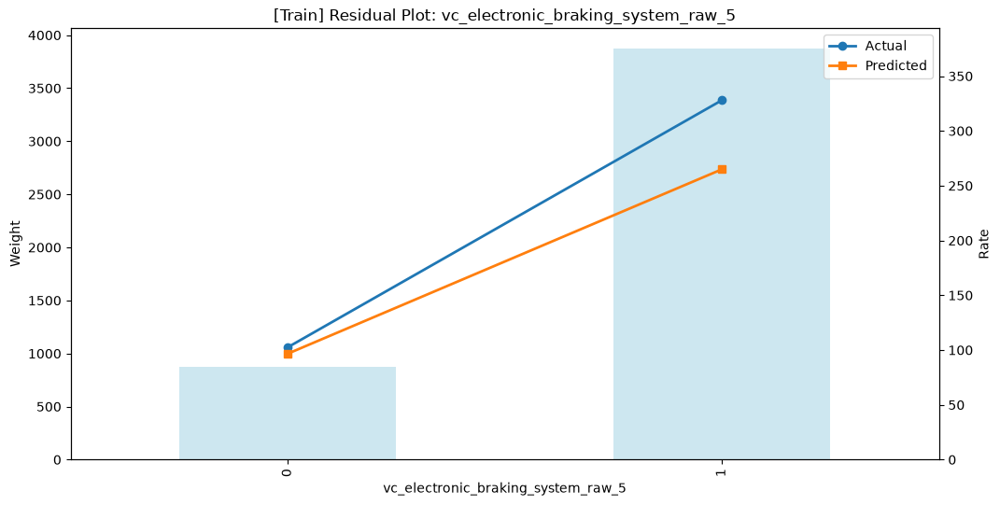

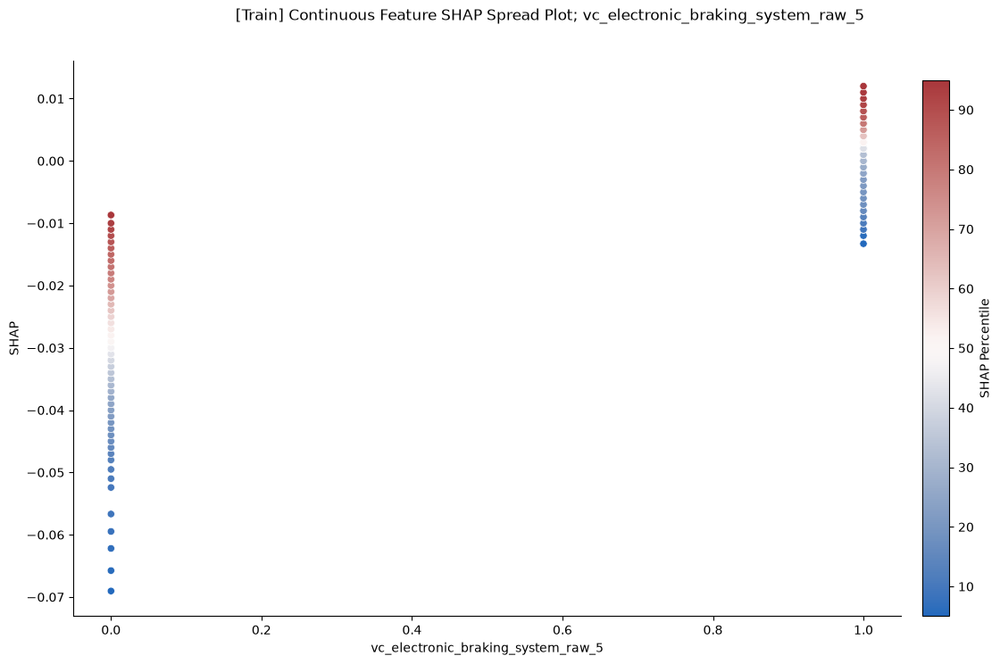

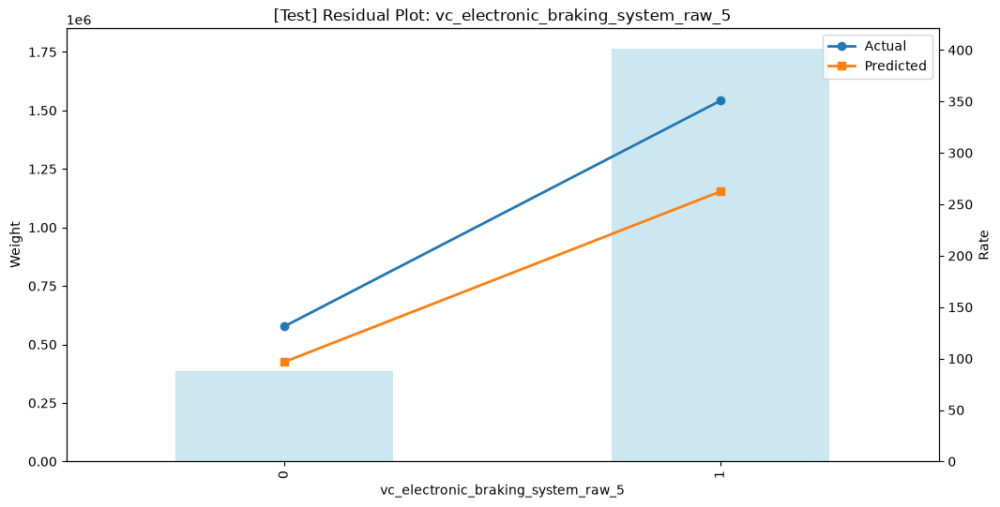

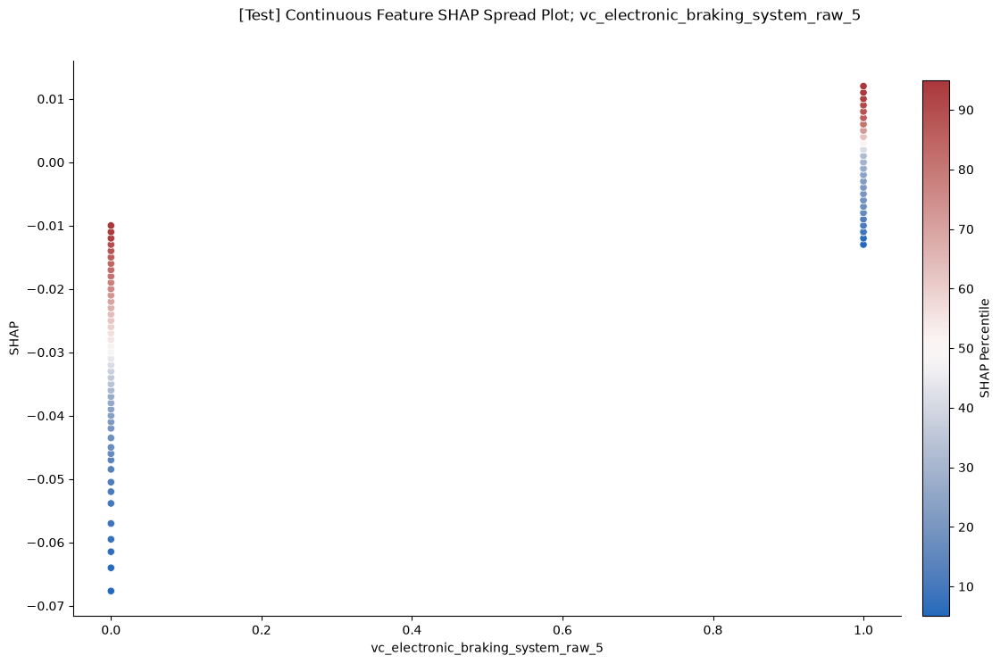


FEATURE: vc_tinted_windows_raw_5


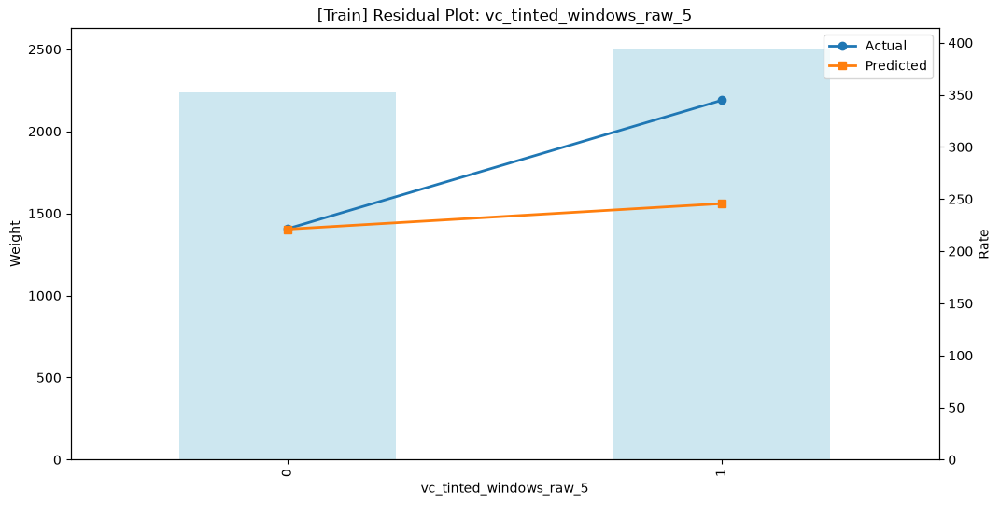

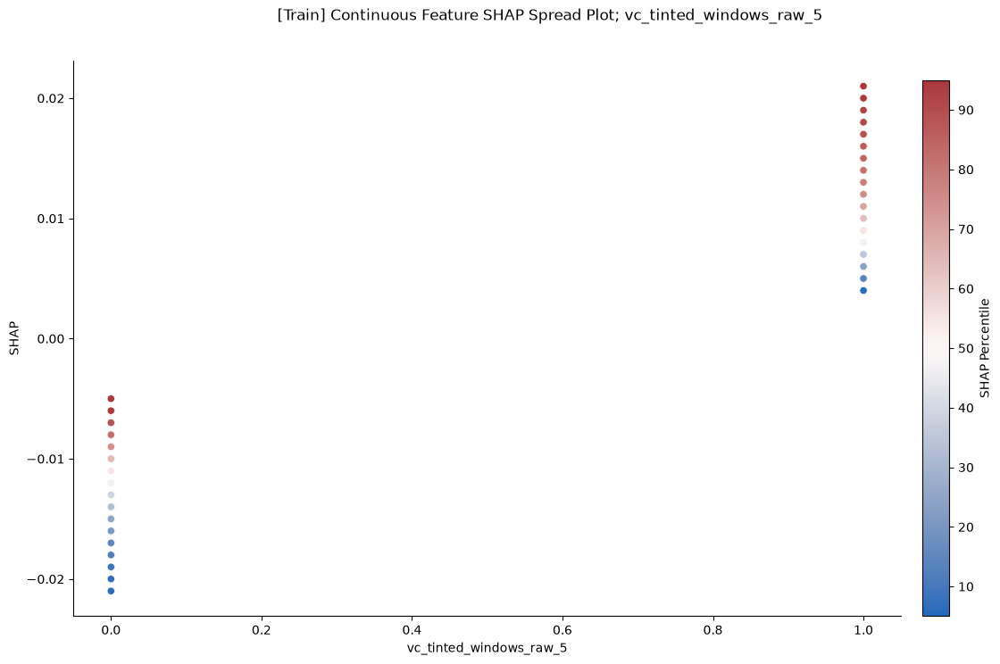

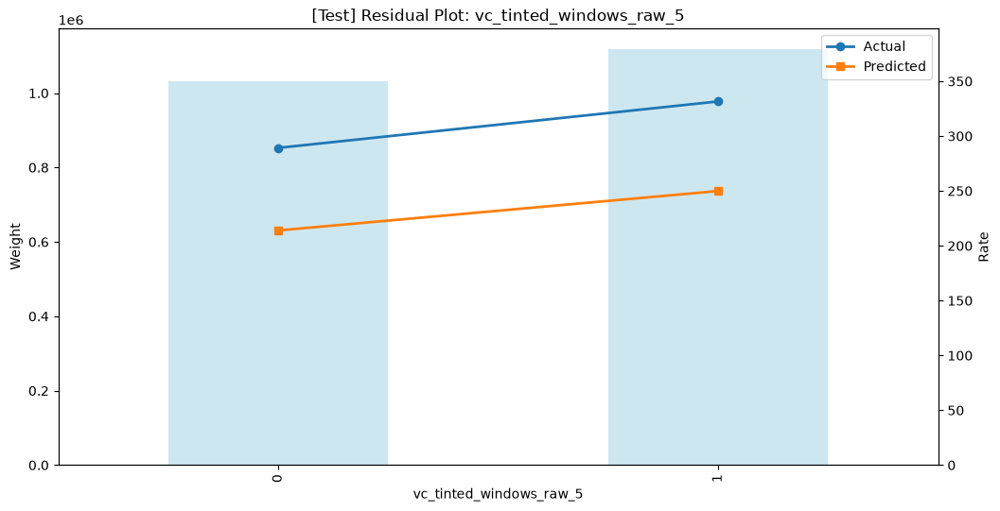

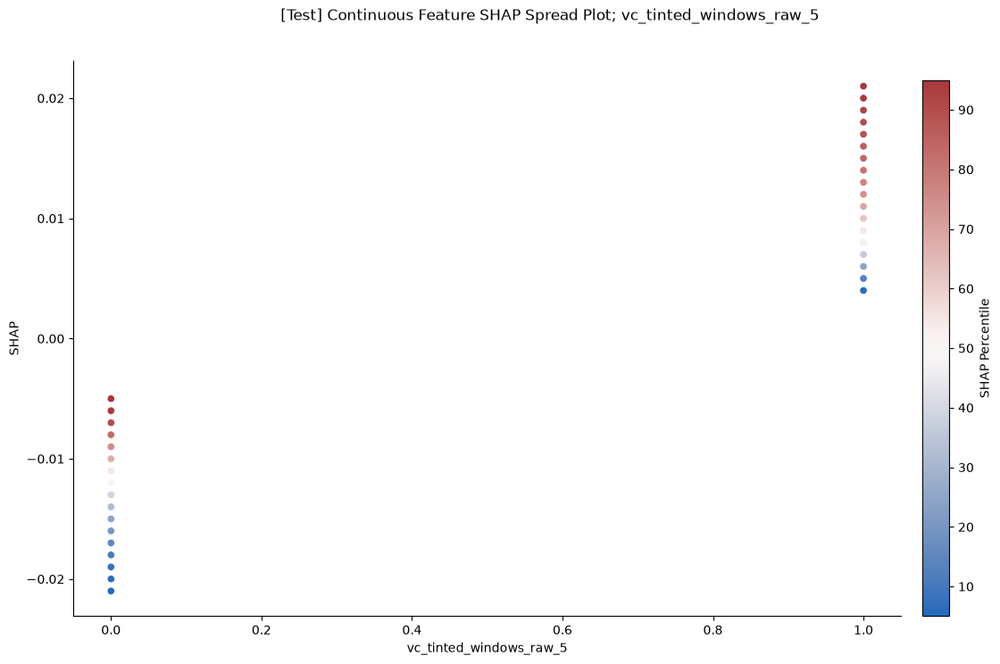


FEATURE: vc_taillights_led_raw


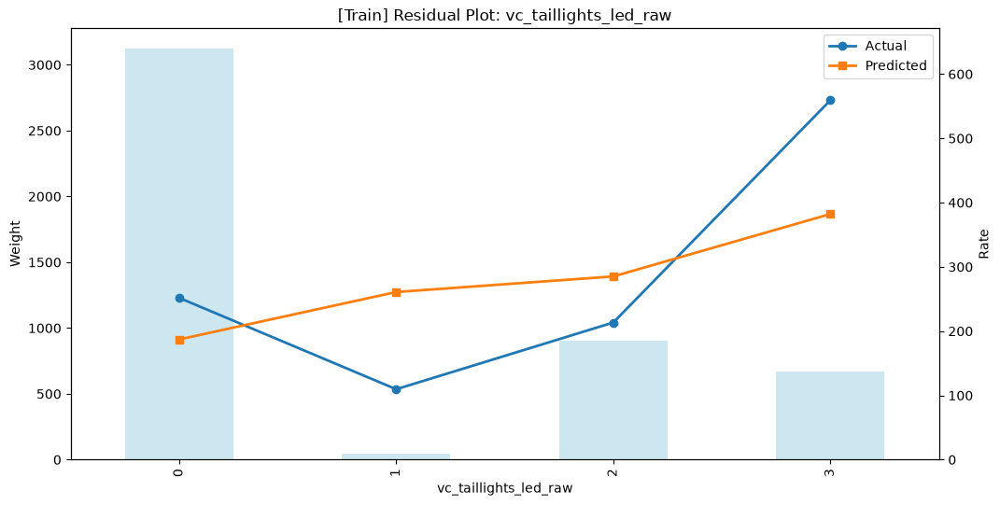

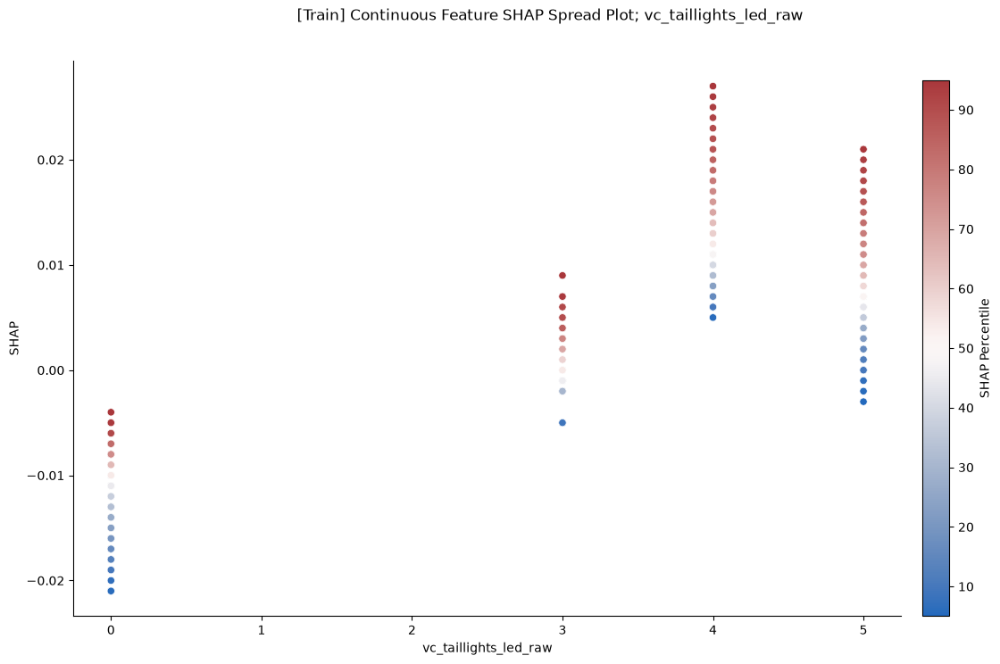

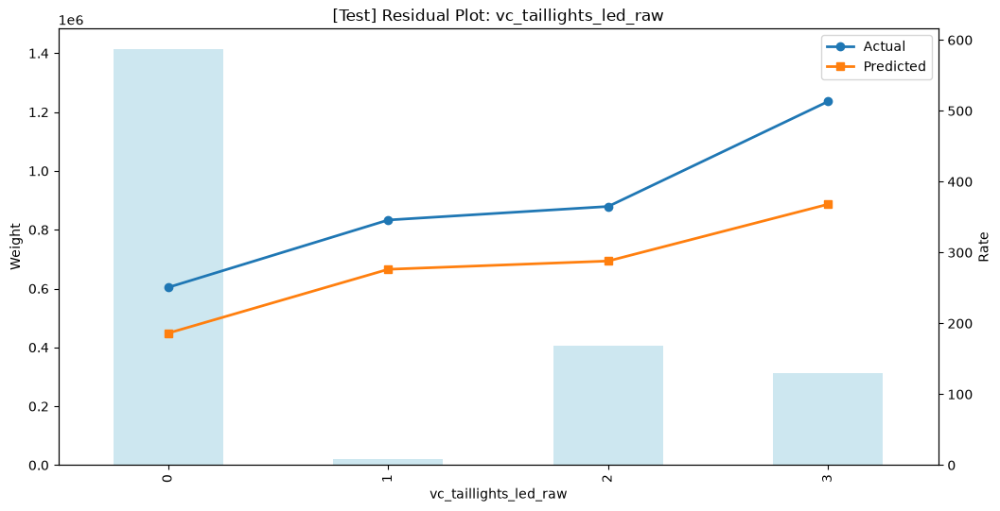

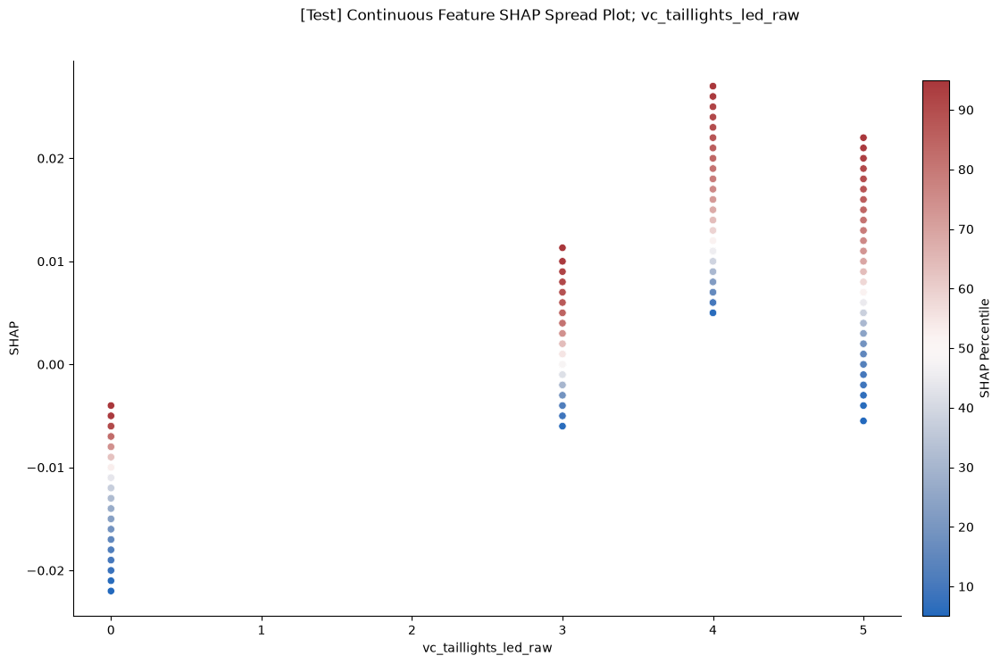


FEATURE: vc_passive_collision_avoidance_system_raw_5


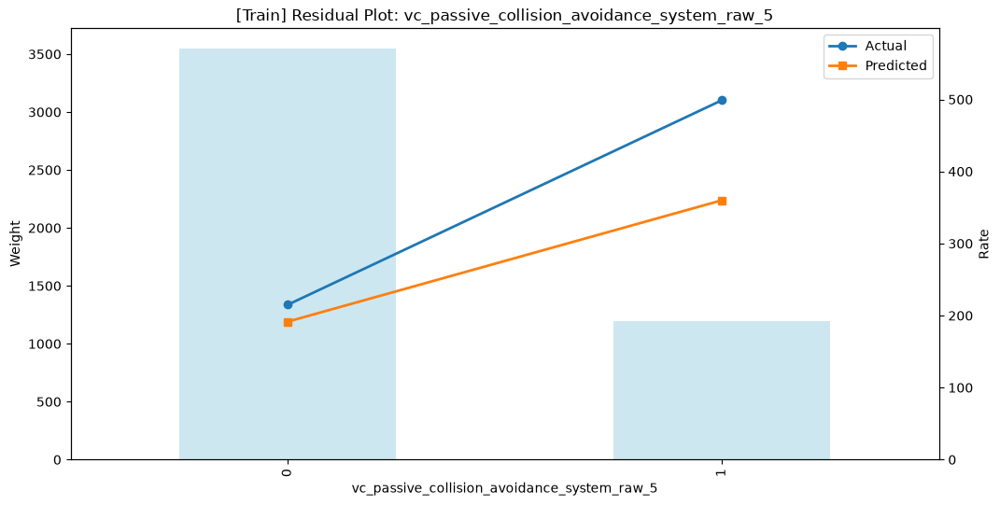

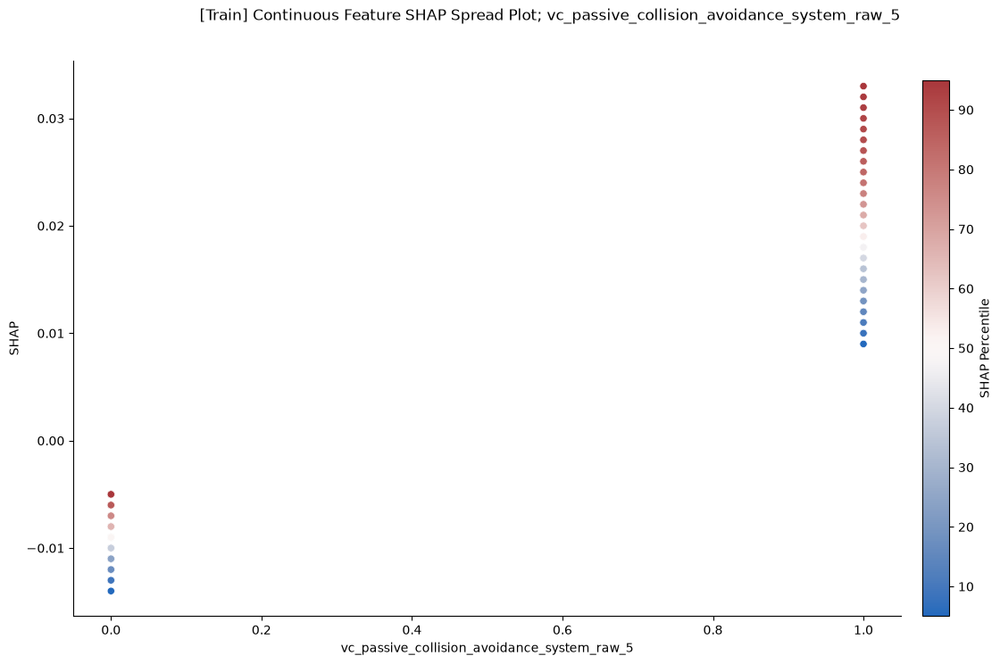

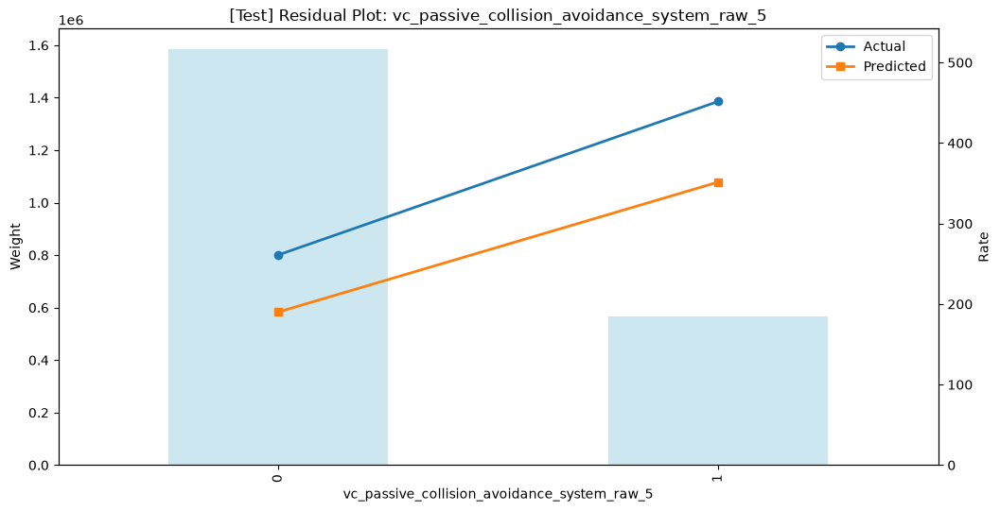

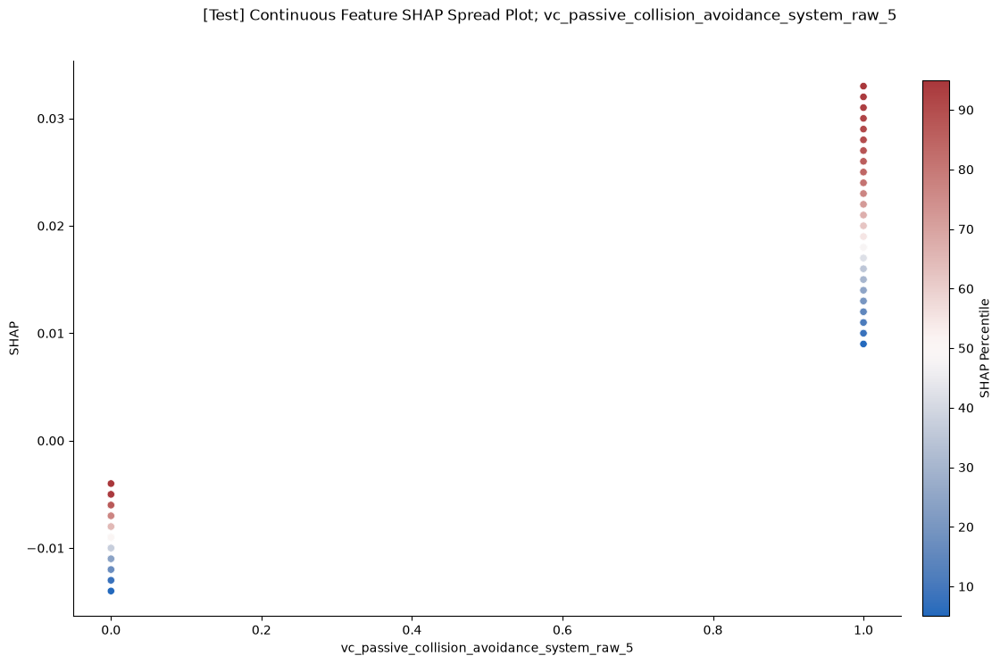


FEATURE: vc_premium_audio_raw


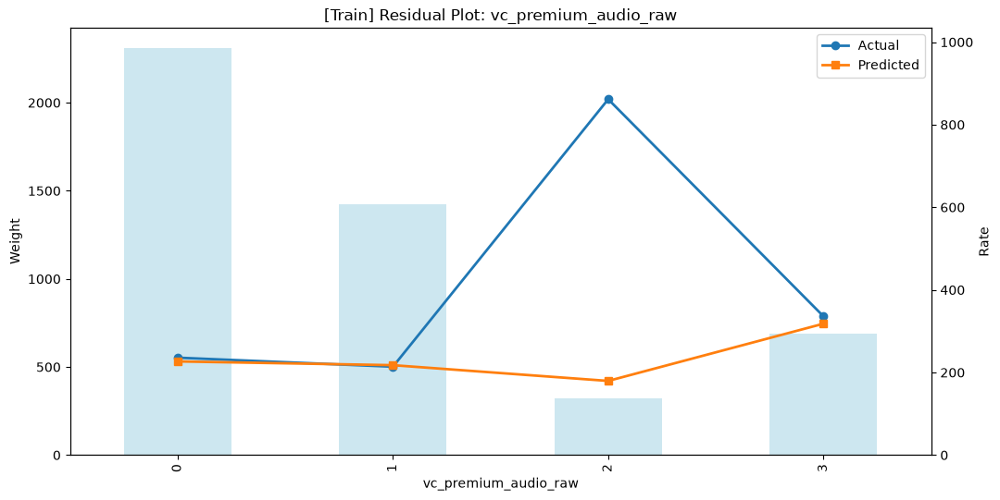

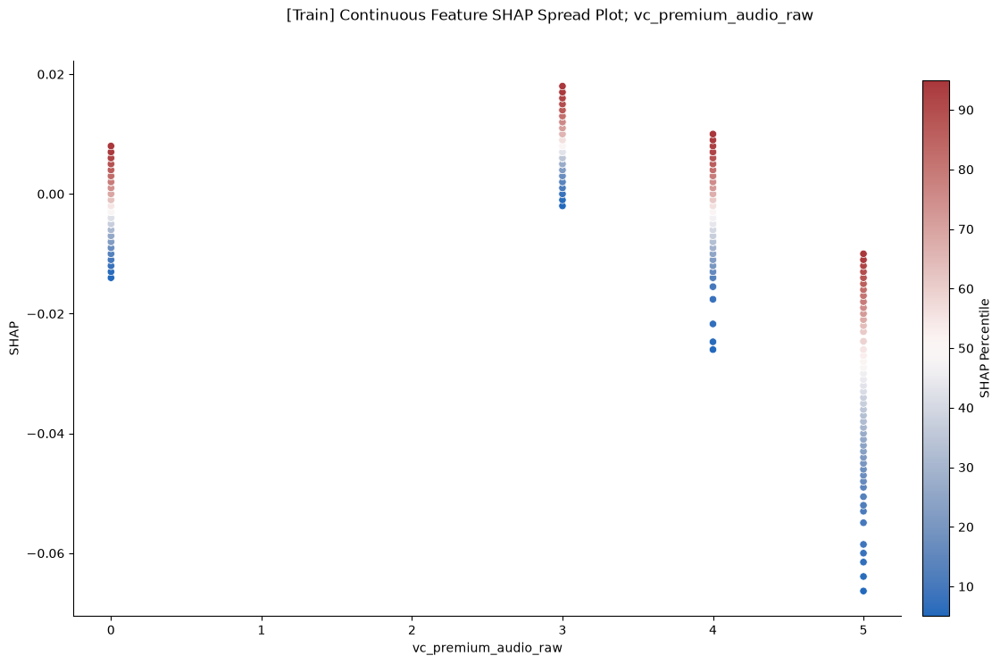

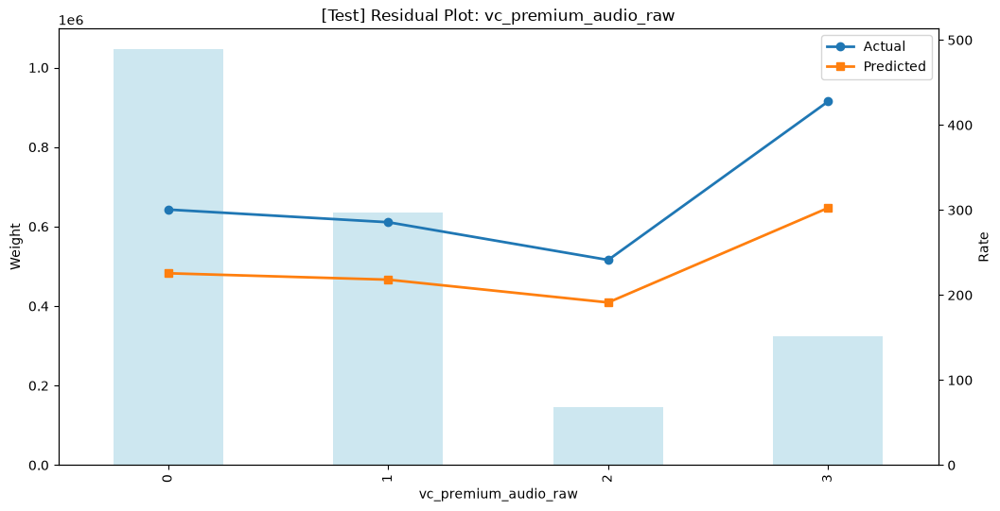

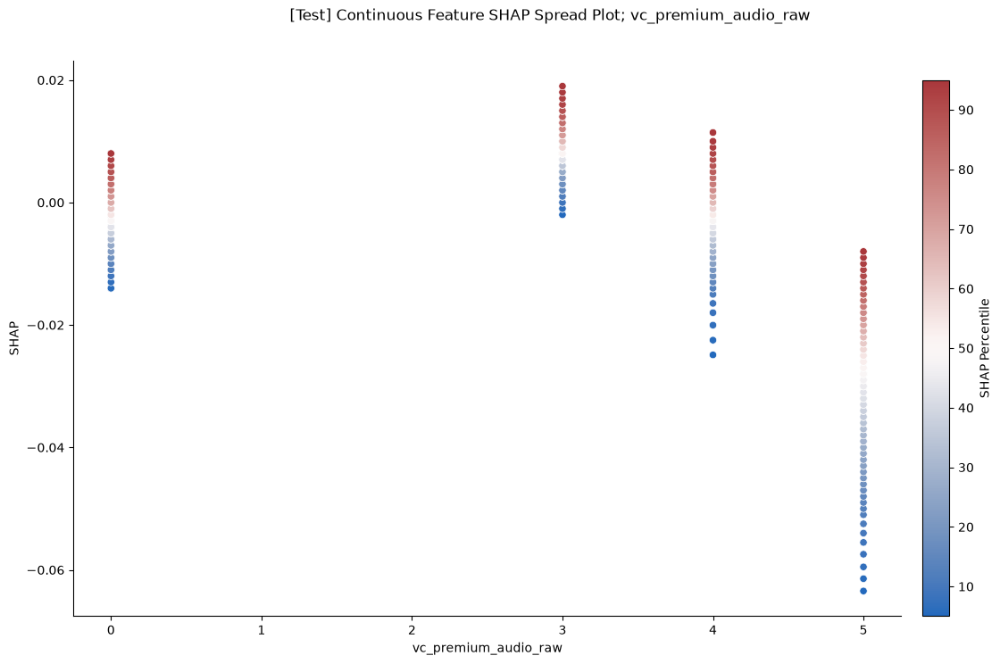


FEATURE: vc_auto_dimming_side_mirrors_raw


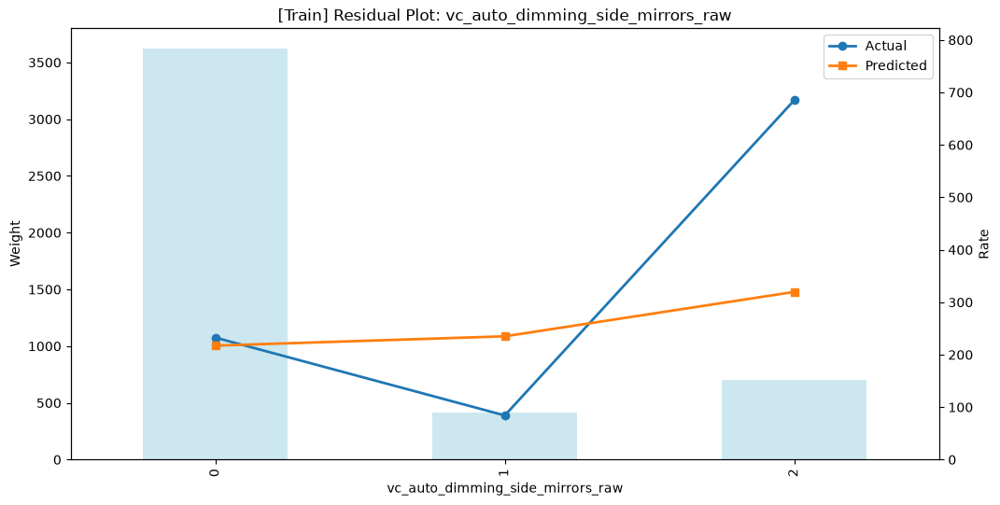

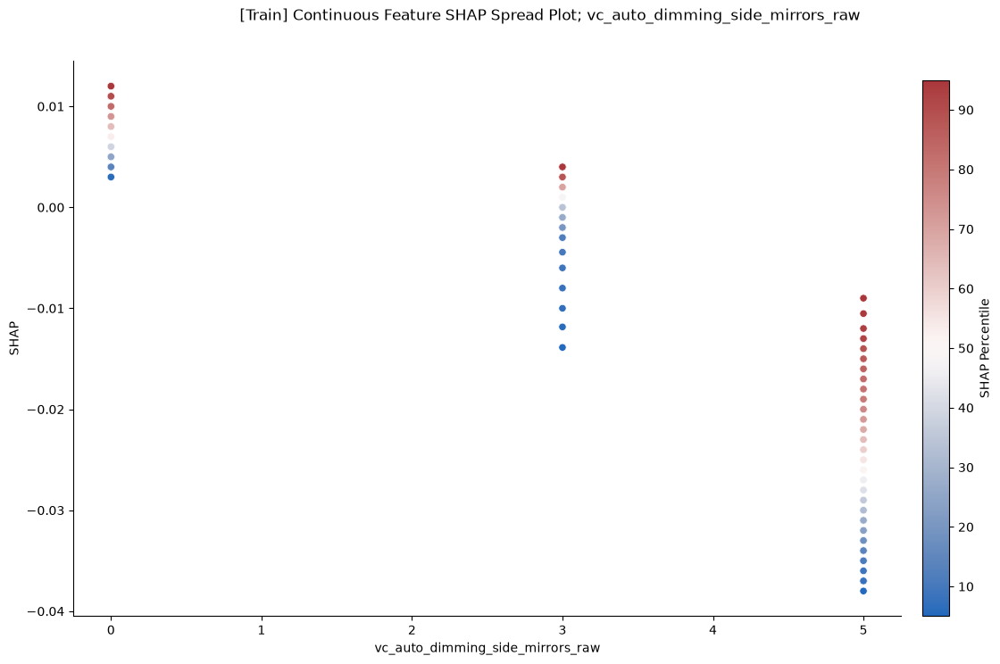

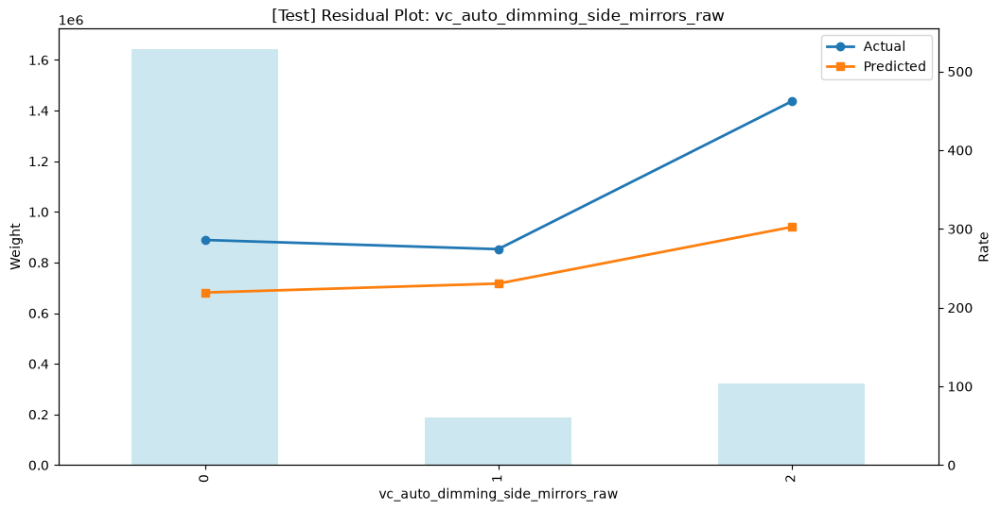

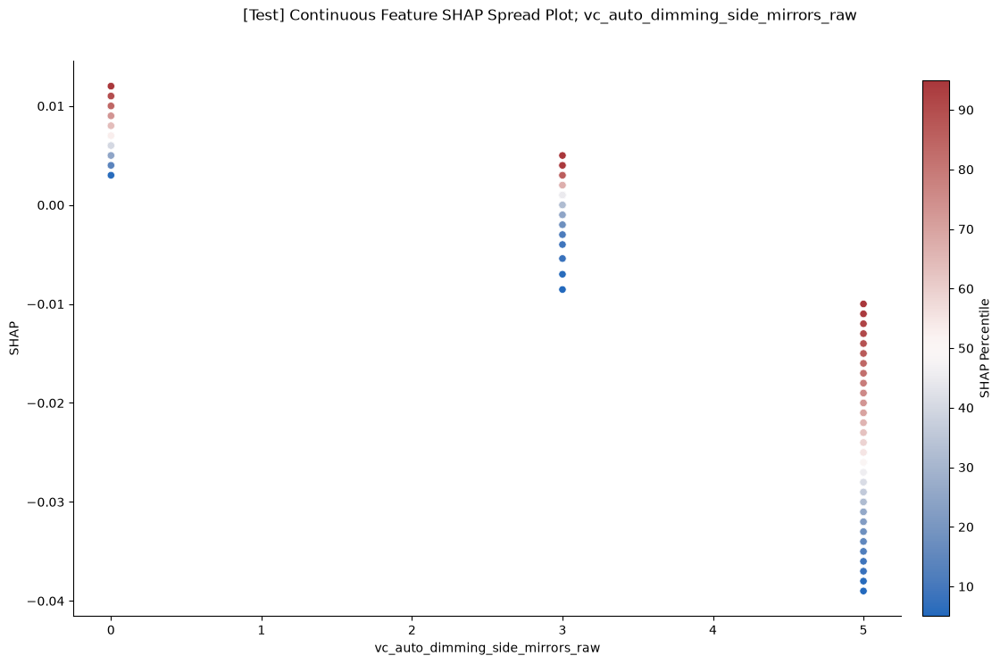


FEATURE: vc_touch_screen_raw_5


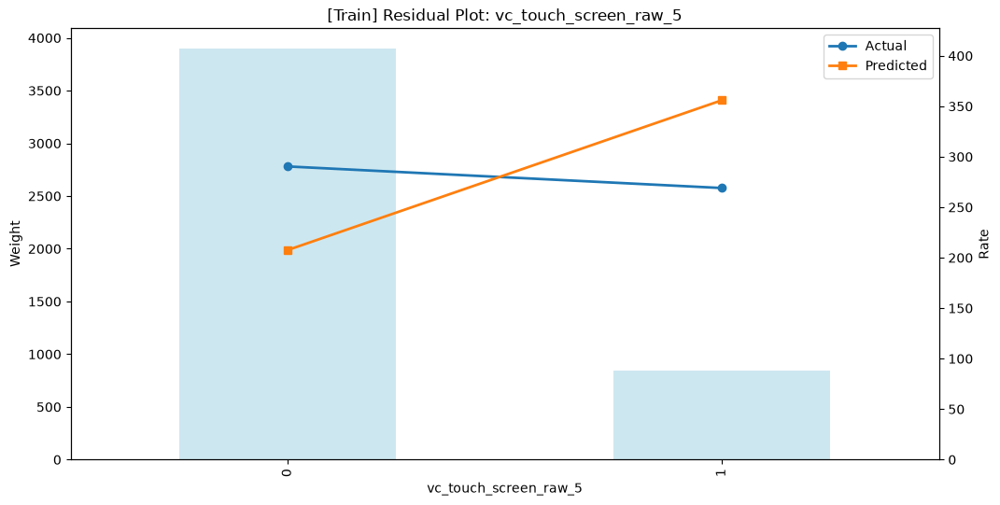

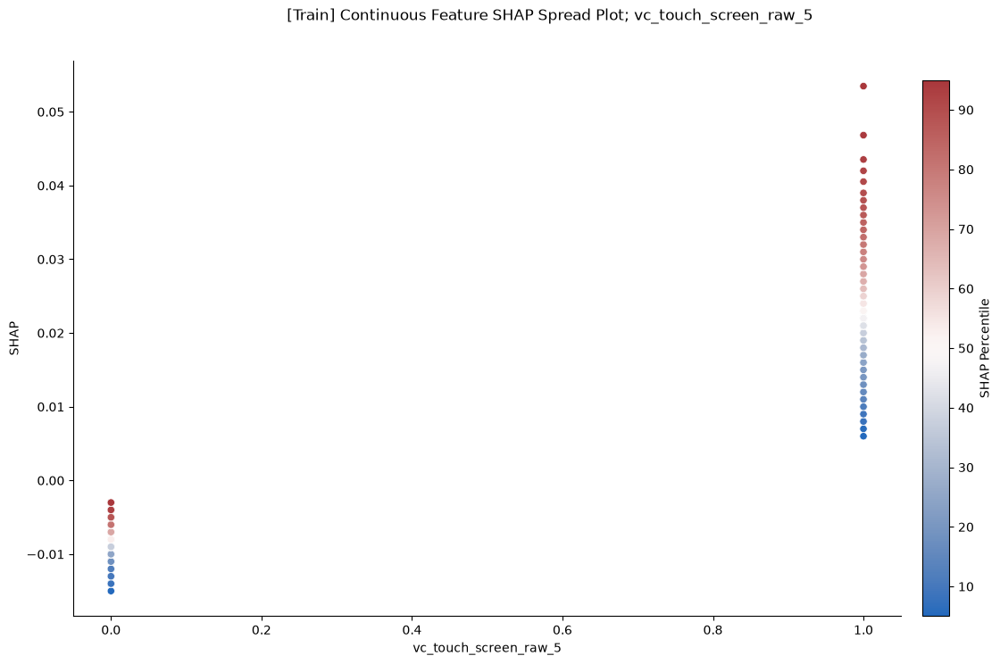

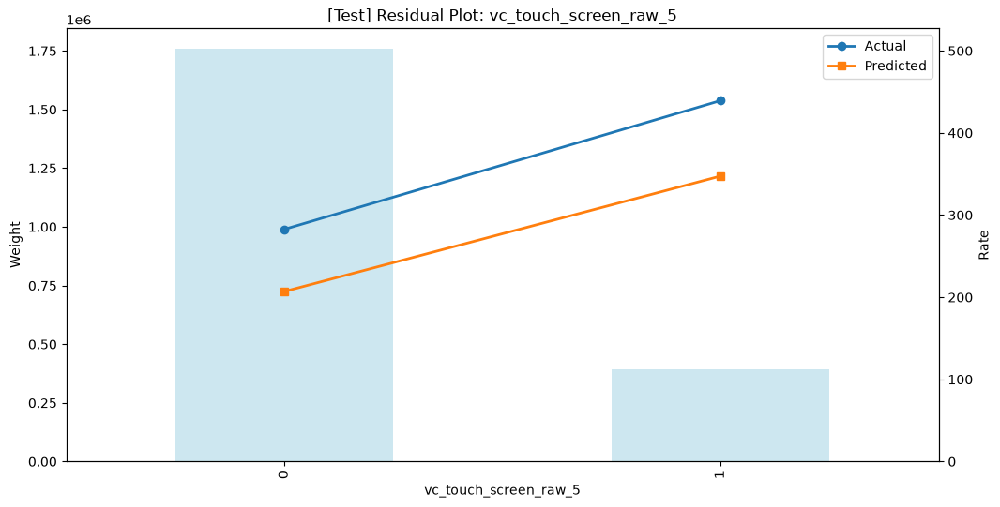

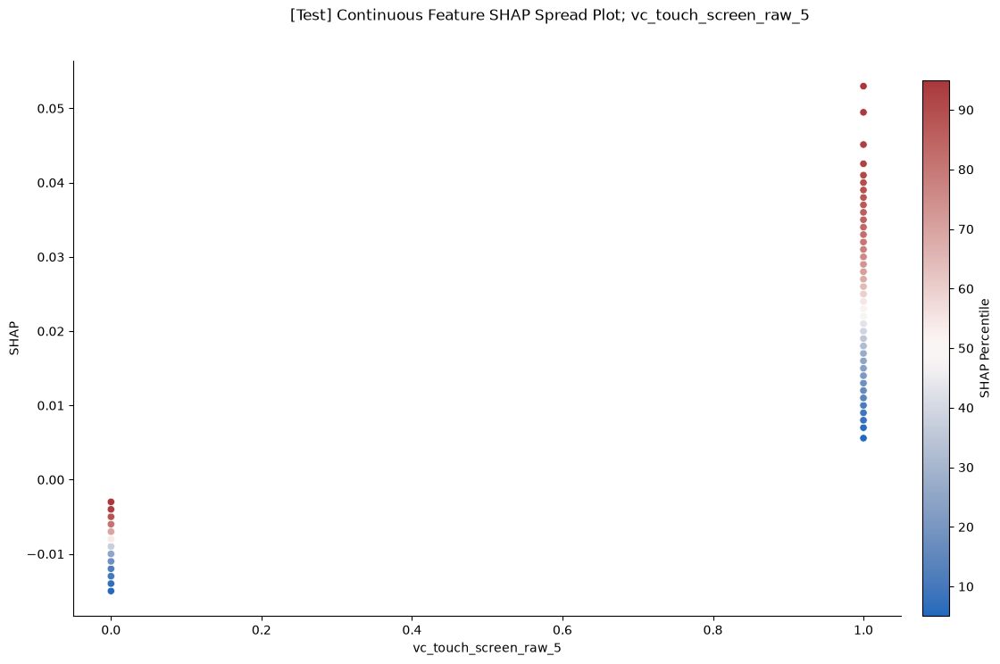


FEATURE: vc_backup_camera_raw_5


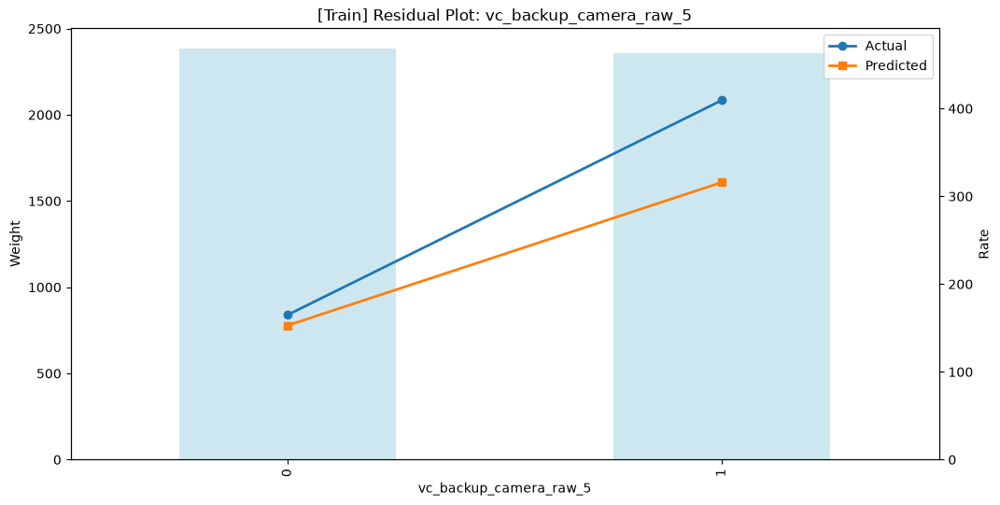

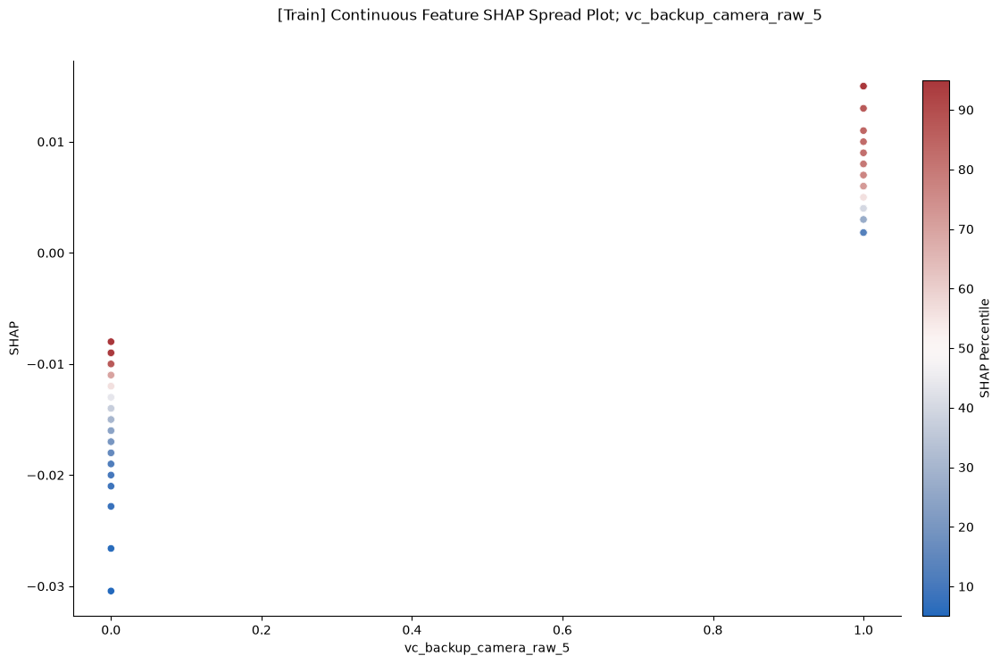

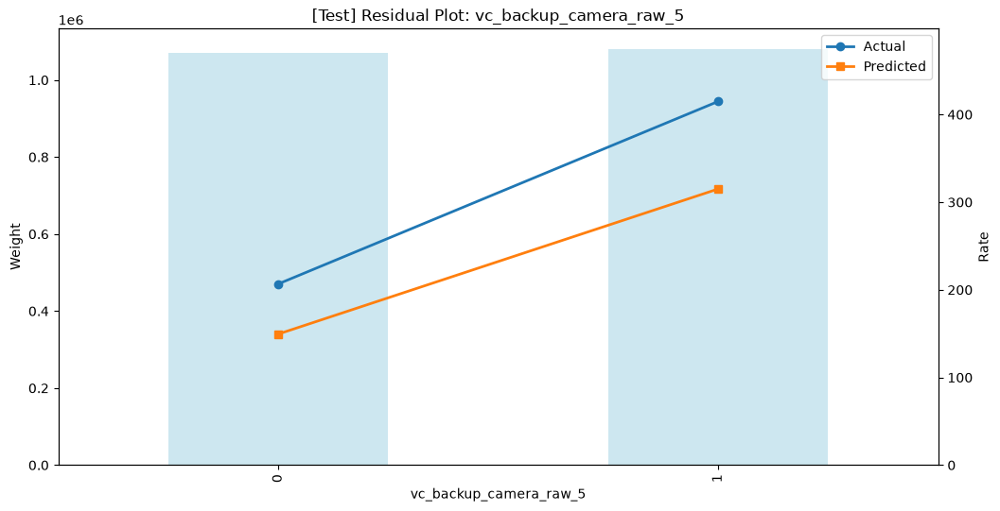

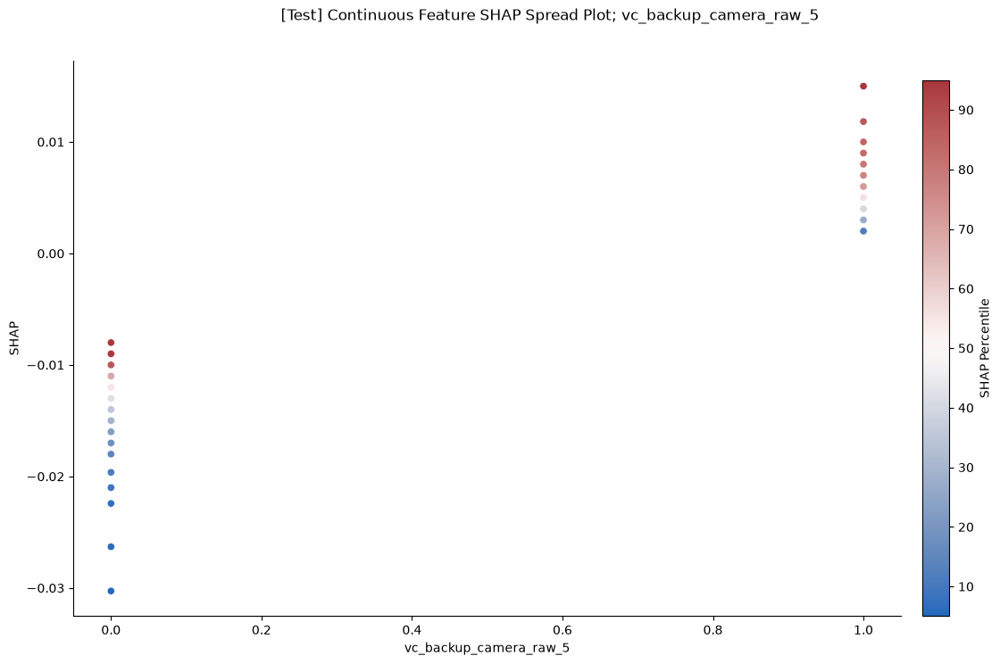


FEATURE: vc_hill_ascent_assist_raw_0


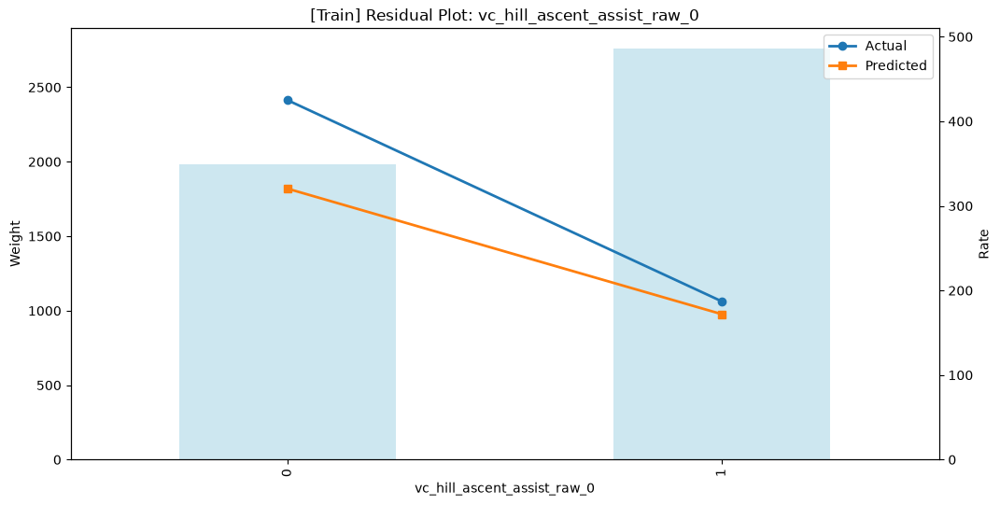

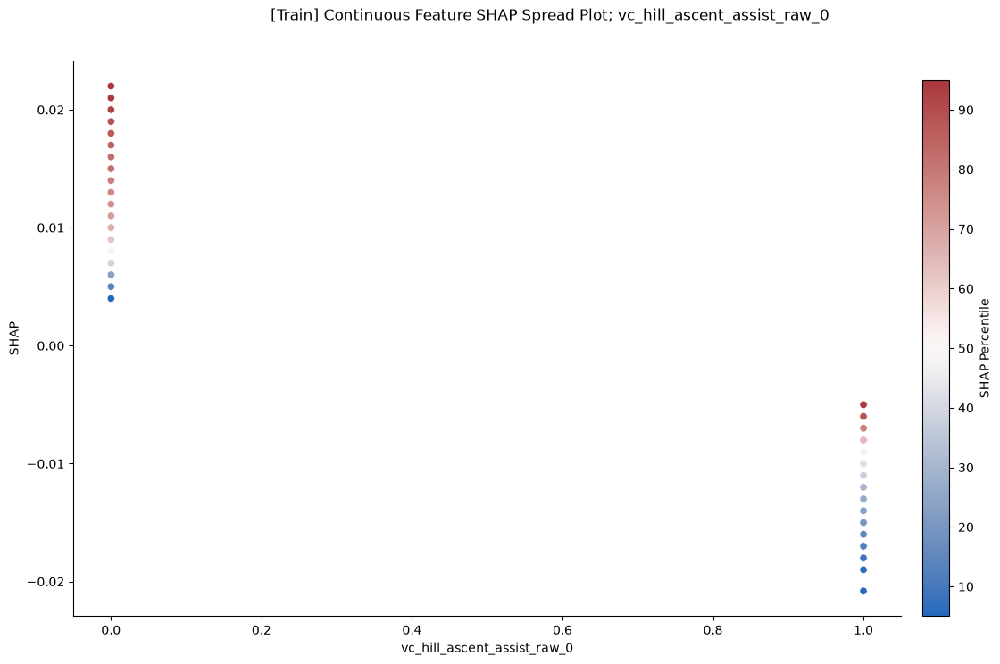

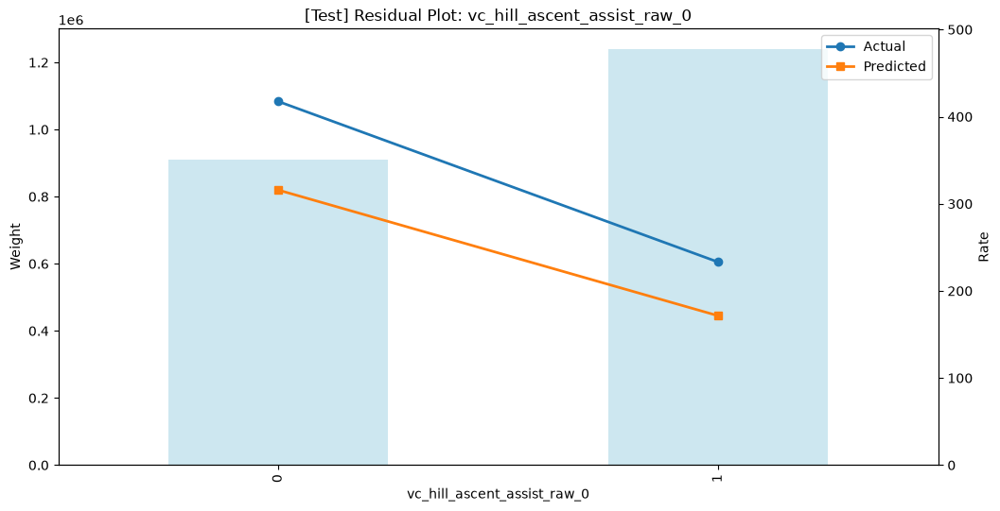

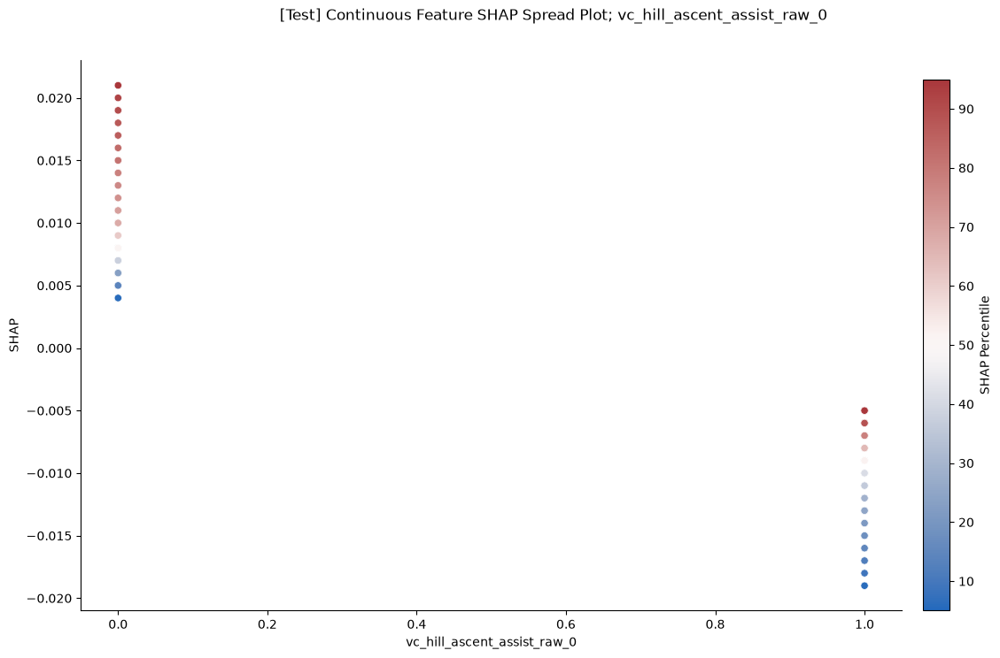


FEATURE: vc_aspiration_forced_induction_ind


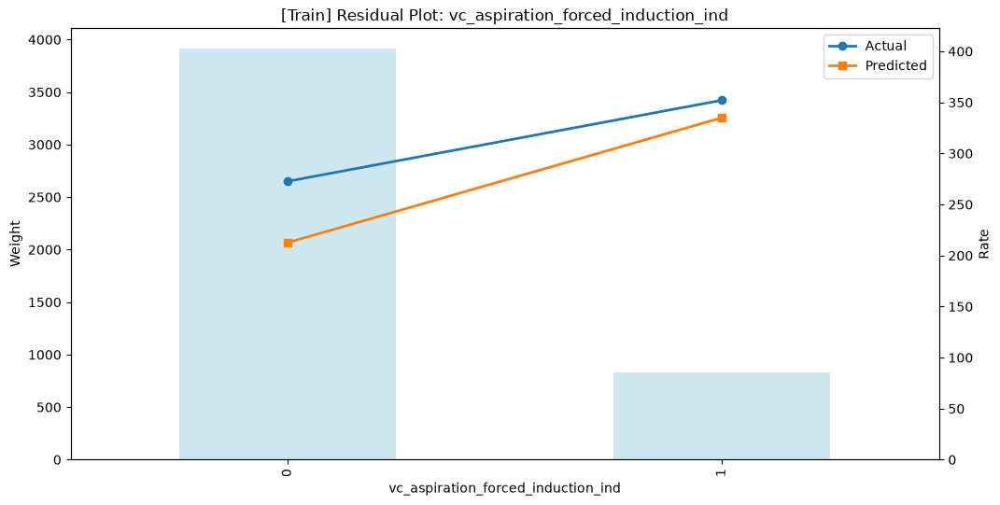

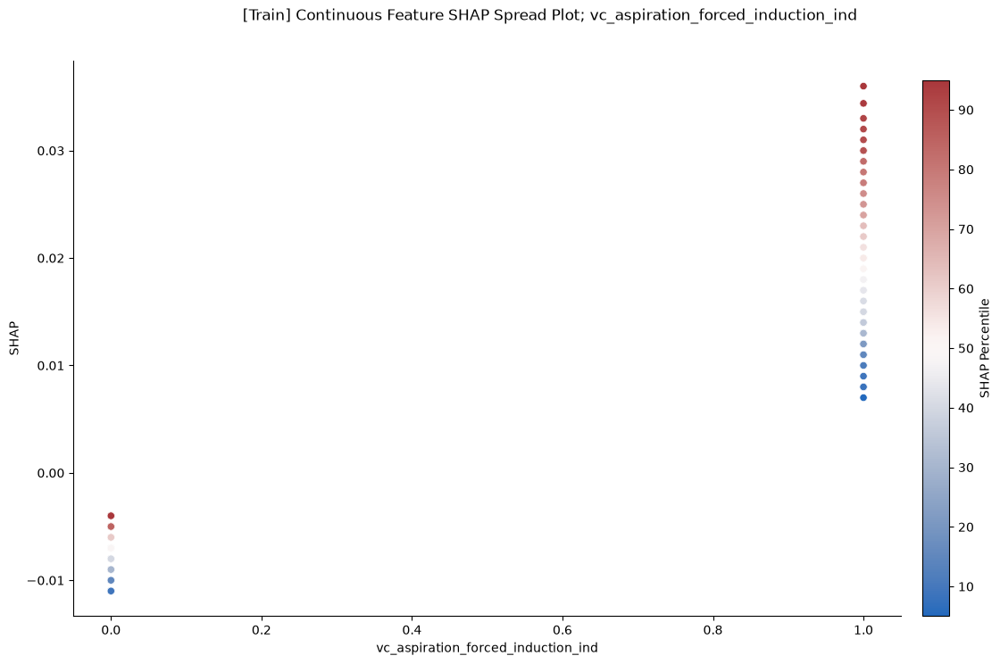

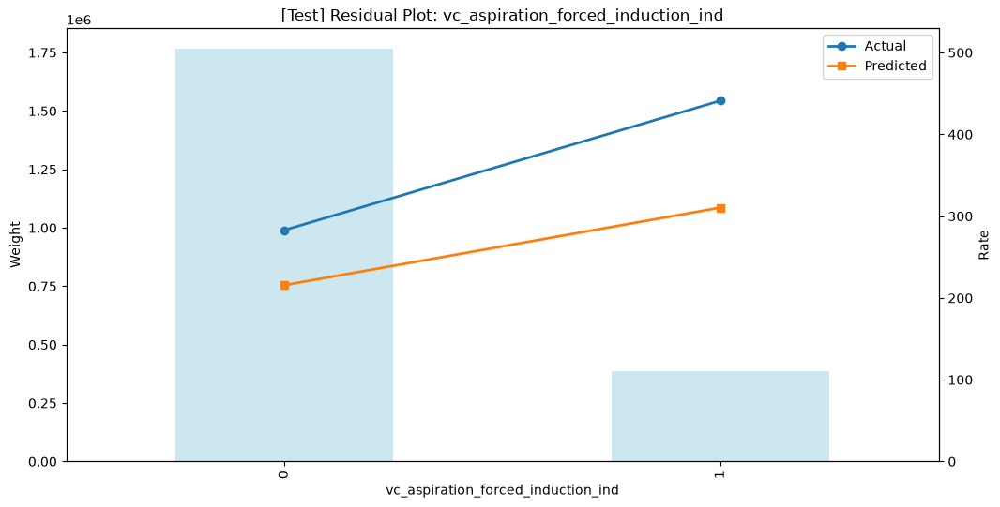

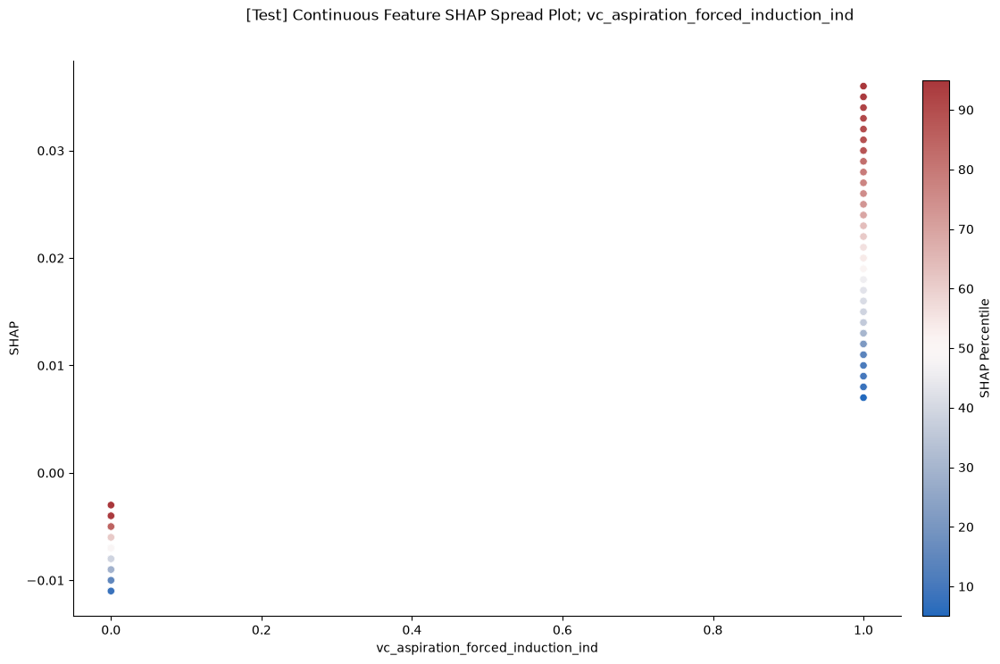


FEATURE: vc_remote_engine_start_raw_3


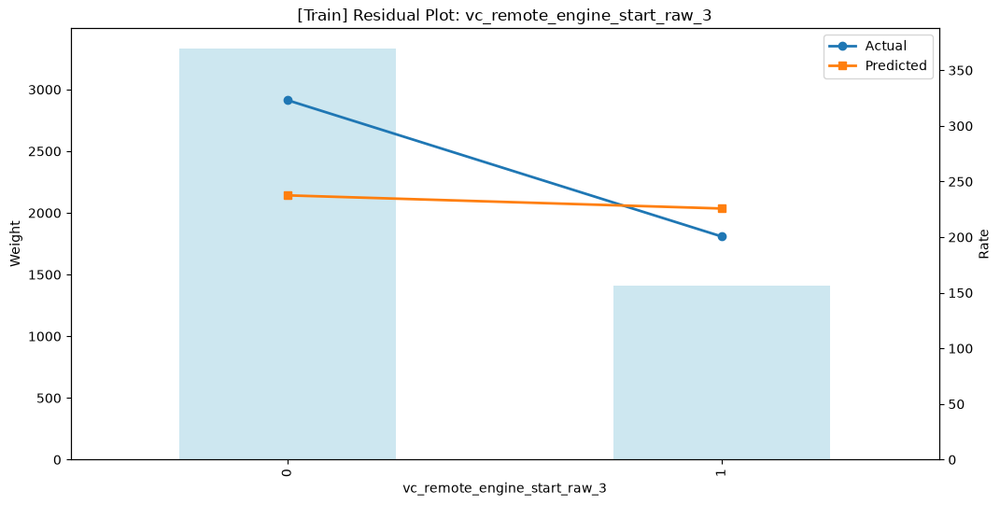

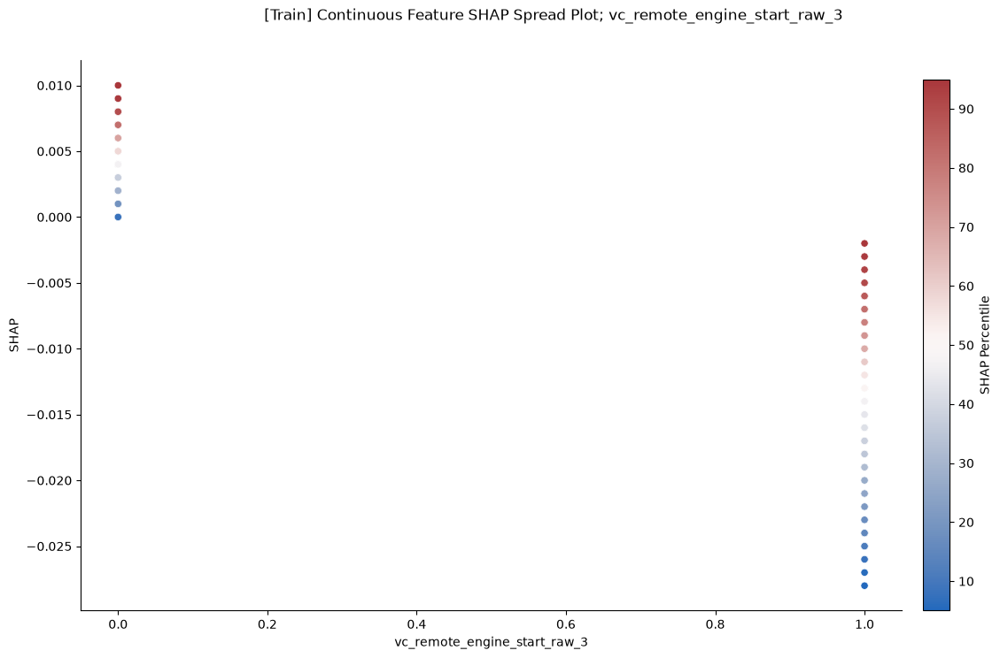

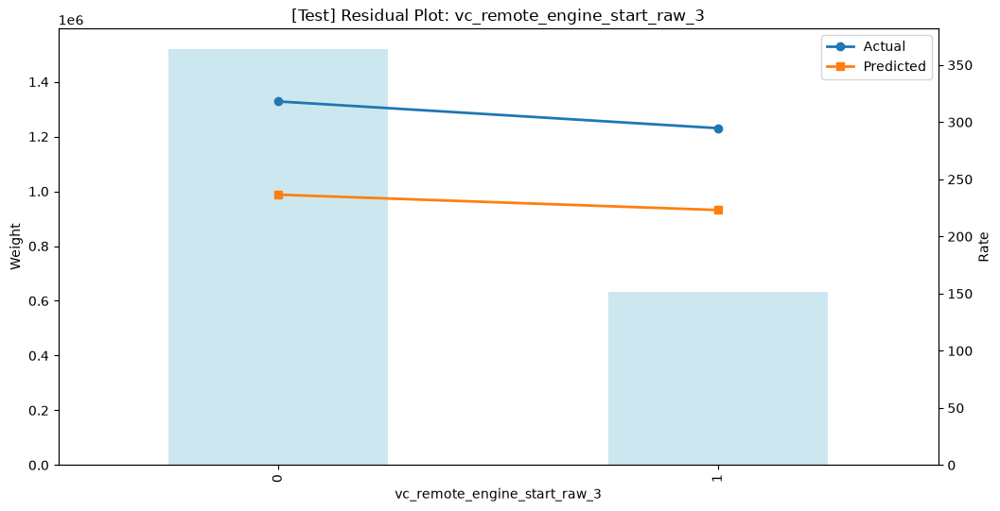

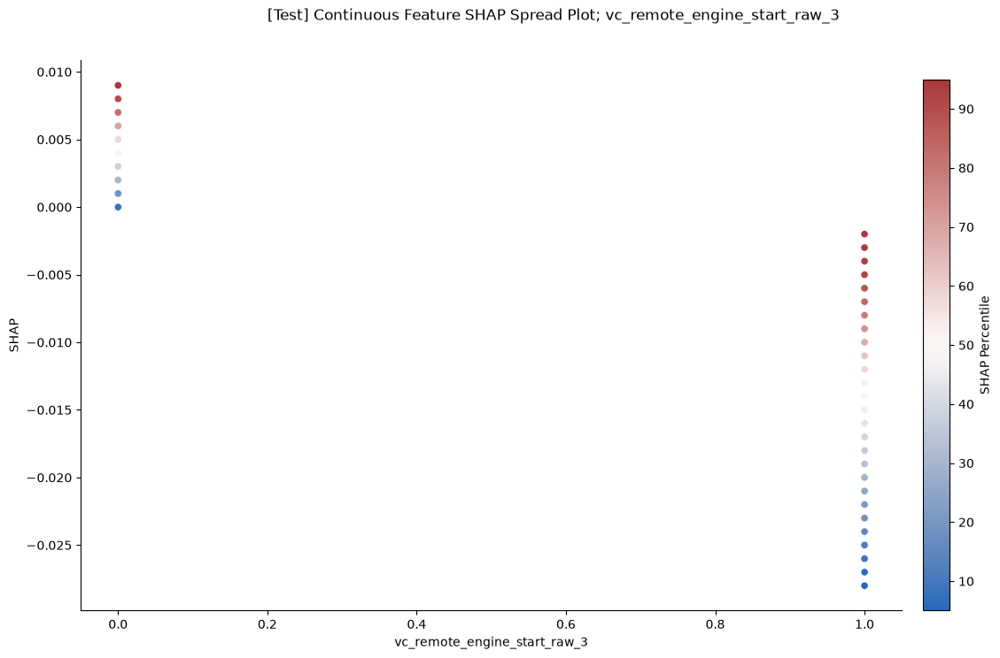


FEATURE: vc_sunroof_raw_0


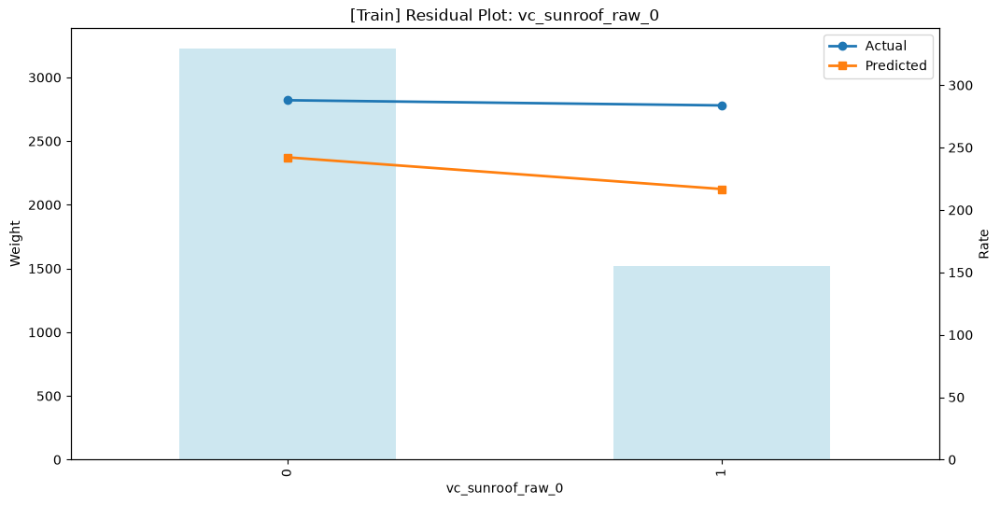

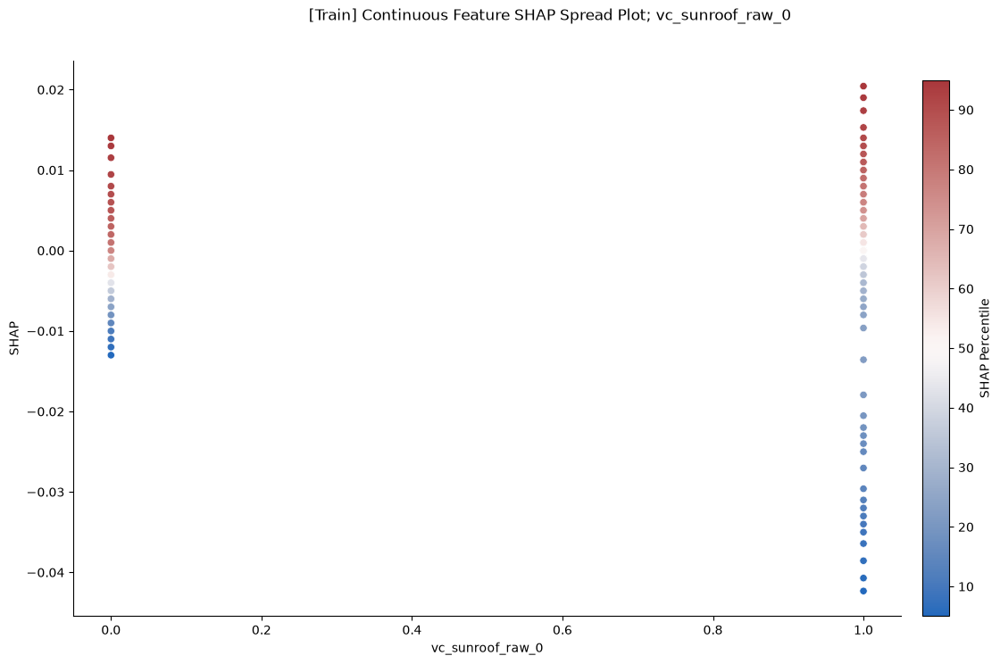

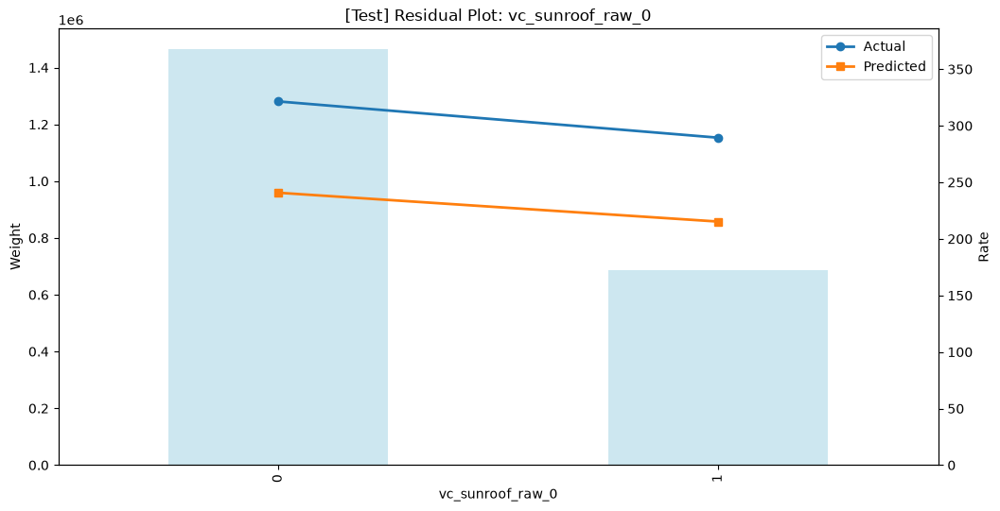

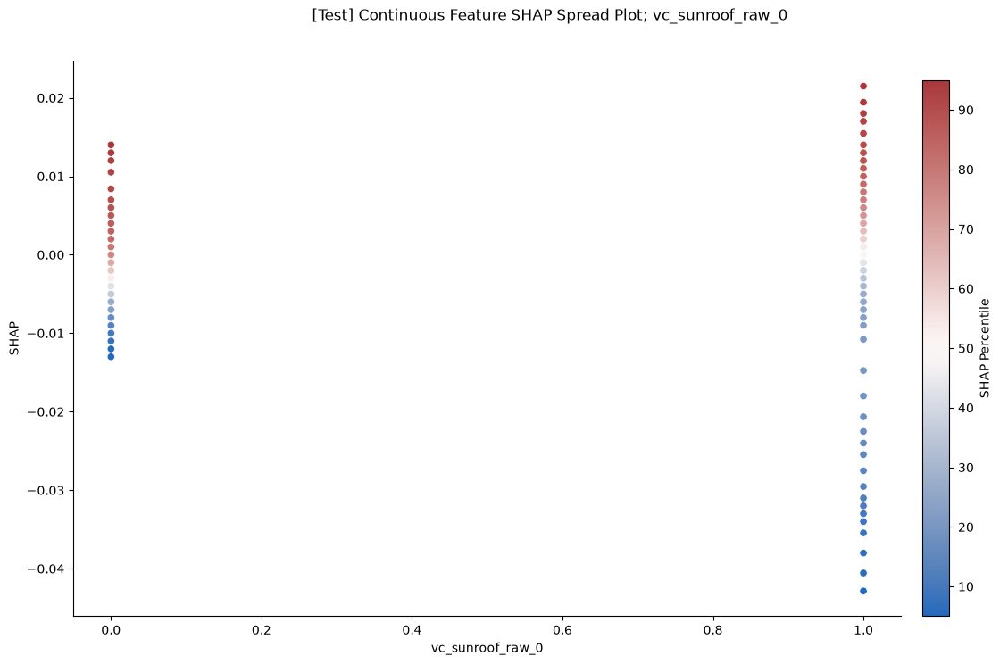


[OK] Displayed 156 plots


In [16]:
from IPython.display import Image, display
print("\n" + "="*60)
print("DISPLAYING ALL PLOTS")
print("="*60)
for f in features:
    if f not in plots_by_feature or not plots_by_feature[f]:
        continue
    print("\n" + "="*60)
    print(f"FEATURE: {f}")
    print("="*60)
    for plot_path in plots_by_feature[f]:
        if Path(plot_path).exists():
            display(Image(filename=plot_path))
        else:
            print(f"WARNING: {plot_path} not found")
print(f"\n[OK] Displayed {sum(len(v) for v in plots_by_feature.values())} plots")

In [17]:
summary["features"] = features
summary["top_n"] = top_n
summary_file = f"{output_base}/results/07_analysis_summary.yaml"
with open(summary_file, "w") as f:
    yaml.dump(summary, f)
print(f"\nSummary: {summary_file}")


Summary: output/car_comp/v1/results/07_analysis_summary.yaml


In [18]:
print("\n" + "#"*40)
print("# STAGE 07: COMPLETE")
print("#"*40)
print(f"Plots: {summary['plots']}")


########################################
# STAGE 07: COMPLETE
########################################
Plots: 156
